## Import Libraries and Data

In [1]:
import pandas as pd
import numpy as np
import os

PLOTS_DIR = 'presentation_plots'
os.makedirs(PLOTS_DIR, exist_ok=True)
print(f'Plots will be saved to: {PLOTS_DIR}/')


Plots will be saved to: presentation_plots/


In [2]:
# This code was given by Simon Clarke!!
# sep=',|\t' is another way to split the clusted data that were not splited by ',' as they should be (csv = comma-seperated values)
# on_bad_lines='warn' is just to signal a warning that there are bad lines in the data (it will just 'warn' us, not 'skip' like what we did)

raw_df = pd.read_csv('Data/Melbourne01.csv',names=["Year", "Month", "Day", "Hour", "Minute",
                                          "Air Temp (degrees C)",
                                          "Apparent Temp (degrees C)", "Dew Pt Temp (degrees C)", "Humidity (%)",
                                          "Wind Direction", "Wind Speed (km/h)", "Wind Gust  (km/h)",
                                          "MSLP (hPa)",
                                          "Rainfall since 9 am (mm)", "Dummy1", "Dummy2"],
                sep=',|\t', on_bad_lines='warn')

C:\Users\Zenbook\AppData\Local\Temp\ipykernel_22836\1274739746.py:5: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  raw_df = pd.read_csv('Data/Melbourne01.csv',names=["Year", "Month", "Day", "Hour", "Minute",


In [3]:
raw_df

# Just to get an idea what the raw data looks like

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Dummy1,Dummy2
0,2011.0,1,1,0,4,24.8,0.0,14.0,51.0,SE,11,13.0,1007.4,0.0,NaN,NaN
1,2011.0,1,1,0,4,24.8,0.0,14.0,51.0,SE,11,13.0,1007.4,0.0,NaN,NaN
2,2011.0,1,1,0,14,24.8,0.0,13.3,48.0,SE,11,11.0,1007.5,0.0,NaN,NaN
3,2011.0,1,1,0,14,24.8,0.0,13.3,48.0,SE,11,11.0,1007.5,0.0,NaN,NaN
4,2011.0,1,1,0,24,24.9,0.0,13.3,48.0,SE,11,13.0,1007.5,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1113280,2025.0,3,12,15,30,33.4,32.5,14.9,32.0,NW,20.0,35.0,1014.6,0.0,NaN,NaN
1113281,2025.0,3,12,15,34,33.5,32.9,14.5,31.0,NNW,26.0,41.0,1014.6,0.0,NaN,NaN
1113282,2025.0,3,12,16,0,34.4,34.2,14.8,30.0,WNW,26.0,41.0,1014.4,0.0,NaN,NaN
1113283,2025.0,3,12,16,30,33.6,32.4,14.1,30.0,WNW,26.0,41.0,1014.1,0.0,NaN,NaN


In [4]:
print(raw_df.isna().sum())

# 133 rows of missing value in 'Year' column is due to the shfted thing...
# For Dummy1, Dummy2 we have no idea what they are....

Year                             133
Month                              0
Day                                0
Hour                               0
Minute                             0
Air Temp (degrees C)               0
Apparent Temp (degrees C)          0
Dew Pt Temp (degrees C)            0
Humidity (%)                       0
Wind Direction                     0
Wind Speed (km/h)                  0
Wind Gust  (km/h)                  0
MSLP (hPa)                         0
Rainfall since 9 am (mm)           0
Dummy1                       1113152
Dummy2                       1113152
dtype: int64


## Data Formating

In [5]:
df = raw_df.drop_duplicates()    # drop duplicated rows
df = df.reset_index(drop=True)   # resetting the index after dropping some rows
df.tail()

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Dummy1,Dummy2
576083,2025.0,3,12,15,30,33.4,32.5,14.9,32.0,NW,20.0,35.0,1014.6,0.0,NaN,NaN
576084,2025.0,3,12,15,34,33.5,32.9,14.5,31.0,NNW,26.0,41.0,1014.6,0.0,NaN,NaN
576085,2025.0,3,12,16,0,34.4,34.2,14.8,30.0,WNW,26.0,41.0,1014.4,0.0,NaN,NaN
576086,2025.0,3,12,16,30,33.6,32.4,14.1,30.0,WNW,26.0,41.0,1014.1,0.0,NaN,NaN
576087,2025.0,3,12,16,30,33.6,32.4,14.1,30.0,NW,28.0,35.0,1014.1,0.0,NaN,NaN


In [6]:
shifted_rows_index = df.index[df['Year'].isna()].tolist()  # list out all the shifted rows (missing value in 'Year' column)
df.loc[shifted_rows_index]

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Dummy1,Dummy2
121011,NaN,2013,9,6,17,0.0,14.9,11.4,5.6,53,N,20.0,22.0,1024.3,0.0,53.0
121012,NaN,2013,9,6,17,30.0,14.7,11.8,6.4,57,N,13.0,17.0,1024.2,0.0,57.0
121013,NaN,2013,9,6,18,0.0,14.4,11.6,7.0,61,N,13.0,17.0,1024.3,0.0,61.0
121014,NaN,2013,9,6,18,30.0,14.1,11.1,7.6,65,N,17.0,20.0,1024.1,0.0,65.0
121015,NaN,2013,9,6,19,0.0,14.1,10.6,7.1,62,N,15.0,19.0,1024.5,0.0,62.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121139,NaN,2013,9,9,9,0.0,16.3,6.5,2.0,38,N,56.0,70.0,1012,0.2,38.0
121140,NaN,2013,9,9,9,30.0,17.1,6.2,1.3,34,N,56.0,72.0,1011.4,0.0,34.0
121141,NaN,2013,9,9,10,0.0,18.0,7.6,-0.2,29,N,56.0,74.0,1010.8,0.0,29.0
121142,NaN,2013,9,9,10,30.0,18.6,7.7,-1.0,26,N,54.0,69.0,1010.2,0.0,26.0


From the table above, we can see that ther are no values in the Year column because all the data are shifted one column to the right.

### Dealing with shifted rows

In [7]:
df_fixing = df.loc[shifted_rows_index]  # Create another df for those shifted rows
df_fixing

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Dummy1,Dummy2
121011,NaN,2013,9,6,17,0.0,14.9,11.4,5.6,53,N,20.0,22.0,1024.3,0.0,53.0
121012,NaN,2013,9,6,17,30.0,14.7,11.8,6.4,57,N,13.0,17.0,1024.2,0.0,57.0
121013,NaN,2013,9,6,18,0.0,14.4,11.6,7.0,61,N,13.0,17.0,1024.3,0.0,61.0
121014,NaN,2013,9,6,18,30.0,14.1,11.1,7.6,65,N,17.0,20.0,1024.1,0.0,65.0
121015,NaN,2013,9,6,19,0.0,14.1,10.6,7.1,62,N,15.0,19.0,1024.5,0.0,62.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121139,NaN,2013,9,9,9,0.0,16.3,6.5,2.0,38,N,56.0,70.0,1012,0.2,38.0
121140,NaN,2013,9,9,9,30.0,17.1,6.2,1.3,34,N,56.0,72.0,1011.4,0.0,34.0
121141,NaN,2013,9,9,10,0.0,18.0,7.6,-0.2,29,N,56.0,74.0,1010.8,0.0,29.0
121142,NaN,2013,9,9,10,30.0,18.6,7.7,-1.0,26,N,54.0,69.0,1010.2,0.0,26.0


In [8]:
df_fixing.drop(columns=['Year'], inplace=True)  # Droping Year column since it has no data in it

In [9]:
col_names=['Year', "Month", "Day", "Hour", "Minute", "Air Temp (degrees C)", "Apparent Temp (degrees C)", 
           "Dew Pt Temp (degrees C)", "Humidity (%)", "Wind Direction", "Wind Speed (km/h)", "Wind Gust  (km/h)",
            "MSLP (hPa)", "Rainfall since 9 am (mm)", "Dummy1"]

df_fixing.columns = col_names # Rename all the column names after dropping Year column
df_fixing

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Dummy1
121011,2013,9,6,17,0.0,14.9,11.4,5.6,53,N,20.0,22.0,1024.3,0.0,53.0
121012,2013,9,6,17,30.0,14.7,11.8,6.4,57,N,13.0,17.0,1024.2,0.0,57.0
121013,2013,9,6,18,0.0,14.4,11.6,7.0,61,N,13.0,17.0,1024.3,0.0,61.0
121014,2013,9,6,18,30.0,14.1,11.1,7.6,65,N,17.0,20.0,1024.1,0.0,65.0
121015,2013,9,6,19,0.0,14.1,10.6,7.1,62,N,15.0,19.0,1024.5,0.0,62.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121139,2013,9,9,9,0.0,16.3,6.5,2.0,38,N,56.0,70.0,1012,0.2,38.0
121140,2013,9,9,9,30.0,17.1,6.2,1.3,34,N,56.0,72.0,1011.4,0.0,34.0
121141,2013,9,9,10,0.0,18.0,7.6,-0.2,29,N,56.0,74.0,1010.8,0.0,29.0
121142,2013,9,9,10,30.0,18.6,7.7,-1.0,26,N,54.0,69.0,1010.2,0.0,26.0


We can see that all the data are shifted back and have correct column names. But you can see that 'Dummy2' column is gone. But we don't really care (right?) because we don't know what it is for.

### Merge them back together

In [10]:
df.drop(df.index[shifted_rows_index], inplace=True) # Drop all the shifted rows from 'df' to get only non-shifted rows
df

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Dummy1,Dummy2
0,2011.0,1,1,0,4,24.8,0.0,14.0,51.0,SE,11,13.0,1007.4,0.0,NaN,NaN
1,2011.0,1,1,0,14,24.8,0.0,13.3,48.0,SE,11,11.0,1007.5,0.0,NaN,NaN
2,2011.0,1,1,0,24,24.9,0.0,13.3,48.0,SE,11,13.0,1007.5,0.0,NaN,NaN
3,2011.0,1,1,0,34,24.7,0.0,13.4,49.0,SE,11,11.0,1007.4,0.0,NaN,NaN
4,2011.0,1,1,0,44,24.1,0.0,13.3,51.0,ESE,9,9.0,1007.3,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
576083,2025.0,3,12,15,30,33.4,32.5,14.9,32.0,NW,20.0,35.0,1014.6,0.0,NaN,NaN
576084,2025.0,3,12,15,34,33.5,32.9,14.5,31.0,NNW,26.0,41.0,1014.6,0.0,NaN,NaN
576085,2025.0,3,12,16,0,34.4,34.2,14.8,30.0,WNW,26.0,41.0,1014.4,0.0,NaN,NaN
576086,2025.0,3,12,16,30,33.6,32.4,14.1,30.0,WNW,26.0,41.0,1014.1,0.0,NaN,NaN


In [11]:
all_df = pd.concat([df, df_fixing])  # Combining the non-shifted df with the shifted df (which has already been fixed)
all_df = all_df.sort_index()         # Sort all those rows back into place
all_df

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Dummy1,Dummy2
0,2011.0,1,1,0,4.0,24.8,0.0,14.0,51.0,SE,11,13.0,1007.4,0.0,NaN,NaN
1,2011.0,1,1,0,14.0,24.8,0.0,13.3,48.0,SE,11,11.0,1007.5,0.0,NaN,NaN
2,2011.0,1,1,0,24.0,24.9,0.0,13.3,48.0,SE,11,13.0,1007.5,0.0,NaN,NaN
3,2011.0,1,1,0,34.0,24.7,0.0,13.4,49.0,SE,11,11.0,1007.4,0.0,NaN,NaN
4,2011.0,1,1,0,44.0,24.1,0.0,13.3,51.0,ESE,9,9.0,1007.3,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
576083,2025.0,3,12,15,30.0,33.4,32.5,14.9,32.0,NW,20.0,35.0,1014.6,0.0,NaN,NaN
576084,2025.0,3,12,15,34.0,33.5,32.9,14.5,31.0,NNW,26.0,41.0,1014.6,0.0,NaN,NaN
576085,2025.0,3,12,16,0.0,34.4,34.2,14.8,30.0,WNW,26.0,41.0,1014.4,0.0,NaN,NaN
576086,2025.0,3,12,16,30.0,33.6,32.4,14.1,30.0,WNW,26.0,41.0,1014.1,0.0,NaN,NaN


So, we now have a dataframe with all the data in the same format.

## Data Cleaning

In [12]:
# Dropping all the non-necessary columns
all_df.drop(columns=['Dummy1', 'Dummy2', 'Apparent Temp (degrees C)','Wind Gust  (km/h)'], inplace=True)
all_df

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm)
0,2011.0,1,1,0,4.0,24.8,14.0,51.0,SE,11,1007.4,0.0
1,2011.0,1,1,0,14.0,24.8,13.3,48.0,SE,11,1007.5,0.0
2,2011.0,1,1,0,24.0,24.9,13.3,48.0,SE,11,1007.5,0.0
3,2011.0,1,1,0,34.0,24.7,13.4,49.0,SE,11,1007.4,0.0
4,2011.0,1,1,0,44.0,24.1,13.3,51.0,ESE,9,1007.3,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
576083,2025.0,3,12,15,30.0,33.4,14.9,32.0,NW,20.0,1014.6,0.0
576084,2025.0,3,12,15,34.0,33.5,14.5,31.0,NNW,26.0,1014.6,0.0
576085,2025.0,3,12,16,0.0,34.4,14.8,30.0,WNW,26.0,1014.4,0.0
576086,2025.0,3,12,16,30.0,33.6,14.1,30.0,WNW,26.0,1014.1,0.0


In [13]:
all_df.isna().sum() # Check for missing values

Year                        0
Month                       0
Day                         0
Hour                        0
Minute                      0
Air Temp (degrees C)        0
Dew Pt Temp (degrees C)     0
Humidity (%)                0
Wind Direction              0
Wind Speed (km/h)           0
MSLP (hPa)                  0
Rainfall since 9 am (mm)    0
dtype: int64

Since all the Year, Month, Day, Hour, Minute columns have no missing values, that means we can now create timestamp out of those columns.

### Timestamp

In [14]:
# Convert it into Timestamp format
all_df['Timestamp'] = pd.to_datetime(all_df[['Year','Month','Day','Hour','Minute']])
all_df.head()

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm),Timestamp
0,2011.0,1,1,0,4.0,24.8,14.0,51.0,SE,11,1007.4,0.0,2011-01-01 00:04:00
1,2011.0,1,1,0,14.0,24.8,13.3,48.0,SE,11,1007.5,0.0,2011-01-01 00:14:00
2,2011.0,1,1,0,24.0,24.9,13.3,48.0,SE,11,1007.5,0.0,2011-01-01 00:24:00
3,2011.0,1,1,0,34.0,24.7,13.4,49.0,SE,11,1007.4,0.0,2011-01-01 00:34:00
4,2011.0,1,1,0,44.0,24.1,13.3,51.0,ESE,9,1007.3,0.0,2011-01-01 00:44:00


In [15]:
all_df.index = all_df['Timestamp']
all_df.head()

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm),Timestamp
Timestamp,,,,,,,,,,,,,
2011-01-01 00:04:00,2011.0,1,1,0,4.0,24.8,14.0,51.0,SE,11,1007.4,0.0,2011-01-01 00:04:00
2011-01-01 00:14:00,2011.0,1,1,0,14.0,24.8,13.3,48.0,SE,11,1007.5,0.0,2011-01-01 00:14:00
2011-01-01 00:24:00,2011.0,1,1,0,24.0,24.9,13.3,48.0,SE,11,1007.5,0.0,2011-01-01 00:24:00
2011-01-01 00:34:00,2011.0,1,1,0,34.0,24.7,13.4,49.0,SE,11,1007.4,0.0,2011-01-01 00:34:00
2011-01-01 00:44:00,2011.0,1,1,0,44.0,24.1,13.3,51.0,ESE,9,1007.3,0.0,2011-01-01 00:44:00


In [16]:
all_df.drop(columns=['Year','Month','Day','Hour','Minute','Timestamp'], inplace=True)
all_df = all_df.drop_duplicates()   # Just repeating this so we are sure that there are no duplicates
all_df.head()

,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm)
Timestamp,,,,,,,
2011-01-01 00:04:00,24.8,14.0,51.0,SE,11,1007.4,0.0
2011-01-01 00:14:00,24.8,13.3,48.0,SE,11,1007.5,0.0
2011-01-01 00:24:00,24.9,13.3,48.0,SE,11,1007.5,0.0
2011-01-01 00:34:00,24.7,13.4,49.0,SE,11,1007.4,0.0
2011-01-01 00:44:00,24.1,13.3,51.0,ESE,9,1007.3,0.0


### Check for Missing Values

In [17]:
# Make sure that all the data are in proper format/class as they should be

all_df['Air Temp (degrees C)'] = pd.to_numeric(all_df['Air Temp (degrees C)'], errors='coerce')
all_df['Dew Pt Temp (degrees C)'] = pd.to_numeric(all_df['Dew Pt Temp (degrees C)'], errors='coerce')
all_df['Humidity (%)'] = pd.to_numeric(all_df['Humidity (%)'], errors='coerce')
all_df['Wind Direction'] = all_df['Wind Direction'].astype(str)
all_df['Wind Direction'] = all_df['Wind Direction'].str.strip()
all_df['Wind Speed (km/h)'] = pd.to_numeric(all_df['Wind Speed (km/h)'], errors='coerce')
all_df['MSLP (hPa)'] = pd.to_numeric(all_df['MSLP (hPa)'], errors='coerce')
all_df['Rainfall since 9 am (mm)'] = pd.to_numeric(all_df['Rainfall since 9 am (mm)'], errors='coerce')
all_df.tail()

C:\Users\Zenbook\AppData\Local\Temp\ipykernel_22836\350734341.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_df['Air Temp (degrees C)'] = pd.to_numeric(all_df['Air Temp (degrees C)'], errors='coerce')
C:\Users\Zenbook\AppData\Local\Temp\ipykernel_22836\350734341.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_df['Dew Pt Temp (degrees C)'] = pd.to_numeric(all_df['Dew Pt Temp (degrees C)'], errors='coerce')
C:\Users\Zenbook\AppData\Local\Temp\ipykernel_22836\350734341.py:5: SettingWithCopyWar

,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm)
Timestamp,,,,,,,
2025-03-12 15:30:00,33.4,14.9,32.0,NW,20.0,1014.6,0.0
2025-03-12 15:34:00,33.5,14.5,31.0,NNW,26.0,1014.6,0.0
2025-03-12 16:00:00,34.4,14.8,30.0,WNW,26.0,1014.4,0.0
2025-03-12 16:30:00,33.6,14.1,30.0,WNW,26.0,1014.1,0.0
2025-03-12 16:30:00,33.6,14.1,30.0,NW,28.0,1014.1,0.0


In [18]:
all_df.isna().sum()

Air Temp (degrees C)          0
Dew Pt Temp (degrees C)       0
Humidity (%)                  0
Wind Direction                0
Wind Speed (km/h)             0
MSLP (hPa)                    0
Rainfall since 9 am (mm)    505
dtype: int64

In [19]:
all_df.describe()

,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm)
count,570653.000000,570653.000000,570653.000000,570653.000000,570653.000000,570148.000000
mean,15.912827,9.096631,66.798829,19.219853,1016.431970,0.792273
std,5.601476,4.063485,17.714121,34.157209,85.961523,2.979064
min,0.500000,-9.600000,0.000000,-9999.000000,-9999.000000,0.000000
25%,11.900000,6.100000,55.000000,11.000000,1012.200000,0.000000
50%,15.200000,8.700000,68.000000,17.000000,1017.300000,0.000000
75%,19.100000,11.800000,80.000000,26.000000,1022.400000,0.200000
max,43.500000,36.900000,100.000000,100.000000,1041.900000,54.600000


We can see that from **all_df.isna().sum()** only show missing values for Rainfall columns (505 missing values). 

But when we check **all_df.describe()**, there exists missing values in Wind Speed and MSLP as well but in the form of -9999.00 instead.

So, now we can try to deal with those missing values.

Since Wind Direction is a catogical data (not numeric), it doesn't show in this describe table. So, we should check for the missing value of Wind Direction seperately. We can do that listing out all the unique values in that Wind Direction column.

In [20]:
all_df['Wind Direction'].unique()

array(['SE', 'ESE', 'NE', 'NNE', 'ENE', 'W', 'N', 'SW', 'SSE', 'S', 'SSW',
       'WSW', 'NW', 'WNW', 'NNW', 'E', 'CALM', '1016.6', '1016.9',
       '1017.0', '1017.4', '1026.0', '1026.1', '1025.3', '1024.2',
       '1029.6', '1003.3', '1008.2', '1019.0', '1015.5', '1014.2',
       '1015.9', '1016.2', '1016.1', '1014.1', '1014.0', '1013.6',
       '1012.7', '1013.1', '1014.4', '1014.6', '1015.6', '1015.8',
       '1016.7', '1017.2', '1016.0', '1017.8', '1019.5', '1019.8',
       '1019.9', '1020.4', '1021.0', '1021.2', '1021.7', '1021.9',
       '1022.3', '1022.7', '1004.5', '1022.0', '1010.3', '1012.0',
       '1010.8', '-'], dtype=object)

And now we found another problem.....

In Wind Direction column, they should be no number!!!

In [21]:
# Go to one of the rows to see what's wrong with the data.
all_df[all_df['Wind Direction'].isin(['1017.0'])]

,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm)
Timestamp,,,,,,,
2012-09-24 14:14:00,13.4,4.2,53.0,1017.0,0.0,0.0,0.0
2012-09-24 14:34:00,14.3,2.3,44.0,1017.0,0.0,0.0,0.0


From that table above we can see that the data for Wind Direction and Wind Speed are missing. The value 1017.0 that are currently in Wind Direction column are supposed to be in MSLP column. That means these data are shifted 2 columns to the left.

.....let's fix this.....(deep breath)....

### Dealing with shifted MSLP data

In [22]:
# Get all those rows that hold numeric data in Wind Direction column

valid_direction = ['N','NNE','NE','ENE','E','ESE','SE','SSE',
                   'S','SSW','SW','WSW','W','WNW','NW','NNW', 'CALM', '-']   # All the valid directions

# Create a df for not-shifted rows (Wind Direction column holds Valid Direction)
MSLP_not_shifted_df = all_df[all_df['Wind Direction'].isin(valid_direction)]

# Create a df for shifted rows (Wind Direction column DOES NOT hold valid direction)
MSLP_shifted_df = all_df[~all_df['Wind Direction'].isin(valid_direction)]

# Check if all the listed rows are actually shifted
MSLP_shifted_df

,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm)
Timestamp,,,,,,,
2012-09-24 13:44:00,14.8,0.5,37.0,1016.6,0.0,0.0,0.0
2012-09-24 13:54:00,13.8,2.1,45.0,1016.9,0.0,0.0,0.0
2012-09-24 14:14:00,13.4,4.2,53.0,1017.0,0.0,0.0,0.0
2012-09-24 14:34:00,14.3,2.3,44.0,1017.0,0.0,0.0,0.0
2012-09-24 15:04:00,13.4,1.2,43.0,1017.4,0.0,0.0,0.0
2013-04-19 11:45:00,16.3,0.1,33.0,1026.0,0.0,0.0,0.0
2013-04-30 10:35:00,15.7,6.9,56.0,1026.1,0.0,0.0,0.0
2013-05-29 11:05:00,15.9,6.2,52.0,1025.3,0.0,0.0,0.0
2013-06-26 10:25:00,9.2,3.9,69.0,1024.2,0.0,0.0,0.0


In [23]:
# check if we had correctly capture NOT shifted rows
# There should be only VALID DIRECTION in Wind Direction column for this NOT shifted df

MSLP_not_shifted_df['Wind Direction'].unique()

array(['SE', 'ESE', 'NE', 'NNE', 'ENE', 'W', 'N', 'SW', 'SSE', 'S', 'SSW',
       'WSW', 'NW', 'WNW', 'NNW', 'E', 'CALM', '-'], dtype=object)

In [24]:
# Check if we had correctly capture the shifted rows
# There should be only numeric values in Wind Direction column for this shifted df

MSLP_shifted_df['Wind Direction'].unique()

array(['1016.6', '1016.9', '1017.0', '1017.4', '1026.0', '1026.1',
       '1025.3', '1024.2', '1029.6', '1003.3', '1008.2', '1019.0',
       '1015.5', '1014.2', '1015.9', '1016.2', '1016.1', '1014.1',
       '1014.0', '1013.6', '1012.7', '1013.1', '1014.4', '1014.6',
       '1015.6', '1015.8', '1016.7', '1017.2', '1016.0', '1017.8',
       '1019.5', '1019.8', '1019.9', '1020.4', '1021.0', '1021.2',
       '1021.7', '1021.9', '1022.3', '1022.7', '1004.5', '1022.0',
       '1010.3', '1012.0', '1010.8'], dtype=object)

In [25]:
# Rename the columns just so they match the actual data in the df
new_col=["Air Temp (degrees C)", "Dew Pt Temp (degrees C)", "Humidity (%)", "MSLP (hPa)", "Rainfall since 9 am (mm)", "Dummy1", "Dummy2"]

MSLP_shifted_df.columns = new_col
MSLP_shifted_df.head()

,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),MSLP (hPa),Rainfall since 9 am (mm),Dummy1,Dummy2
Timestamp,,,,,,,
2012-09-24 13:44:00,14.8,0.5,37.0,1016.6,0.0,0.0,0.0
2012-09-24 13:54:00,13.8,2.1,45.0,1016.9,0.0,0.0,0.0
2012-09-24 14:14:00,13.4,4.2,53.0,1017.0,0.0,0.0,0.0
2012-09-24 14:34:00,14.3,2.3,44.0,1017.0,0.0,0.0,0.0
2012-09-24 15:04:00,13.4,1.2,43.0,1017.4,0.0,0.0,0.0


In [26]:
MSLP_shifted_df.drop(columns=['Dummy1','Dummy2'], inplace=True) # Dropping the 2 dummy columns as we don't need them

C:\Users\Zenbook\AppData\Local\Temp\ipykernel_22836\3692582120.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  MSLP_shifted_df.drop(columns=['Dummy1','Dummy2'], inplace=True) # Dropping the 2 dummy columns as we don't need them


In [27]:
# Create Wind Direction and Wind Speed column with '-' representing missing values
MSLP_shifted_df['Wind Direction'] = '-'
MSLP_shifted_df['Wind Speed (km/h)'] = -9999.00
MSLP_shifted_df.head()

C:\Users\Zenbook\AppData\Local\Temp\ipykernel_22836\1371292172.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  MSLP_shifted_df['Wind Direction'] = '-'
C:\Users\Zenbook\AppData\Local\Temp\ipykernel_22836\1371292172.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  MSLP_shifted_df['Wind Speed (km/h)'] = -9999.00


,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),MSLP (hPa),Rainfall since 9 am (mm),Wind Direction,Wind Speed (km/h)
Timestamp,,,,,,,
2012-09-24 13:44:00,14.8,0.5,37.0,1016.6,0.0,-,-9999.0
2012-09-24 13:54:00,13.8,2.1,45.0,1016.9,0.0,-,-9999.0
2012-09-24 14:14:00,13.4,4.2,53.0,1017.0,0.0,-,-9999.0
2012-09-24 14:34:00,14.3,2.3,44.0,1017.0,0.0,-,-9999.0
2012-09-24 15:04:00,13.4,1.2,43.0,1017.4,0.0,-,-9999.0


In [28]:
all_df = pd.concat([MSLP_not_shifted_df, MSLP_shifted_df])  # Combining the non-shifted df with the shifted df (which has already been fixed)
all_df = all_df.sort_index()         # Sort all those rows back into place
all_df = all_df.drop_duplicates()    # Make sure that there are no duplicates
all_df

,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm)
Timestamp,,,,,,,
2011-01-01 00:04:00,24.8,14.0,51.0,SE,11.0,1007.4,0.0
2011-01-01 00:14:00,24.8,13.3,48.0,SE,11.0,1007.5,0.0
2011-01-01 00:24:00,24.9,13.3,48.0,SE,11.0,1007.5,0.0
2011-01-01 00:34:00,24.7,13.4,49.0,SE,11.0,1007.4,0.0
2011-01-01 00:44:00,24.1,13.3,51.0,ESE,9.0,1007.3,0.0
...,...,...,...,...,...,...,...
2025-03-12 15:30:00,33.4,14.9,32.0,NW,20.0,1014.6,0.0
2025-03-12 15:34:00,33.5,14.5,31.0,NNW,26.0,1014.6,0.0
2025-03-12 16:00:00,34.4,14.8,30.0,WNW,26.0,1014.4,0.0


In [29]:
all_df['Wind Direction'].unique()

array(['SE', 'ESE', 'NE', 'NNE', 'ENE', 'W', 'N', 'SW', 'SSE', 'S', 'SSW',
       'WSW', 'NW', 'WNW', 'NNW', 'E', 'CALM', '-'], dtype=object)

Now, all the values in Wind Direction column are in proper format (valid direction).

But there are still missing values that we have to deal with.

### Dealing with Missing Values

In [30]:
# Missing values in Wind Speed and MSLP columns (in form of -9999.00)

cols = ['Wind Speed (km/h)', 'MSLP (hPa)']

all_df[all_df[cols].isin([-9999]).any(axis=1)]  # Printing this out just so we can observe how the -9999.00 data look like

,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm)
Timestamp,,,,,,,
2012-09-24 13:44:00,14.8,0.5,37.0,-,-9999.0,1016.6,0.0
2012-09-24 13:54:00,13.8,2.1,45.0,-,-9999.0,1016.9,0.0
2012-09-24 14:14:00,13.4,4.2,53.0,-,-9999.0,1017.0,0.0
2012-09-24 14:34:00,14.3,2.3,44.0,-,-9999.0,1017.0,0.0
2012-09-24 15:04:00,13.4,1.2,43.0,-,-9999.0,1017.4,0.0
...,...,...,...,...,...,...,...
2024-04-15 10:30:00,17.8,10.4,62.0,W,9.0,-9999.0,0.0
2024-04-15 11:00:00,18.5,10.3,59.0,WNW,4.0,-9999.0,0.0
2024-10-10 20:00:00,13.5,5.9,60.0,S,15.0,-9999.0,0.0


In [31]:
# Missing values in Wind Direction columns (in form of '-')

all_df[all_df['Wind Direction'].isin(['-'])]

,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm)
Timestamp,,,,,,,
2012-09-24 13:44:00,14.8,0.5,37.0,-,-9999.0,1016.6,0.0
2012-09-24 13:54:00,13.8,2.1,45.0,-,-9999.0,1016.9,0.0
2012-09-24 14:14:00,13.4,4.2,53.0,-,-9999.0,1017.0,0.0
2012-09-24 14:34:00,14.3,2.3,44.0,-,-9999.0,1017.0,0.0
2012-09-24 15:04:00,13.4,1.2,43.0,-,-9999.0,1017.4,0.0
...,...,...,...,...,...,...,...
2023-01-19 14:00:00,17.1,7.5,53.0,-,-9999.0,1017.2,0.0
2023-03-03 10:30:00,17.4,7.7,53.0,-,-9999.0,1019.2,0.0
2023-09-18 13:30:00,16.3,11.2,72.0,-,-9999.0,1014.4,0.0


At this point, the data are pretty much clear and in having the same format across all the rows.

Reminder, there are still missing values that we have to work on.

As mentioned above, 
- missing values of Wind Speed and MSLP are in the form of -9999.00
- missing values of Wind Direction are in the form of '-'

So, next step, we should try to deal with these missing vlues by dropping/filling/interpolating/predicting/etc.

I think for now we can simply download the 'all_df' as csv and then try to clean the data from that.

In [32]:
# all_df.to_csv('cleaned_Melbourne-1.csv')   # 

## Handling Missing Values

During initial cleaning, missing values were encoded as special markers rather than actual NaN values:
- **Wind Direction**: missing entries were labelled as `'-'` (a string)
- **Wind Speed & MSLP**: missing entries were labelled as `-9999.0` (a placeholder number)

These were first replaced with `NaN` so pandas can recognise and handle them properly.

### Filling Strategy

| Column | Method | Reason |
|---|---|---|
| Wind Direction | Forward Fill | Categorical — can't interpolate between compass directions, so we carry the last known direction forward |
| Wind Speed | Linear Interpolation | Continuous numeric value that changes gradually, so we estimate between surrounding readings |
| Rainfall | Forward Fill | Only 505 missing out of 570k rows; carrying forward the last recorded value is reasonable for short gaps |
| MSLP | Linear Interpolation | Atmospheric pressure changes gradually, so interpolating between surrounding readings gives a good estimate |

We also re-cast numeric columns to `float64` using `pd.to_numeric()` before interpolating, as concatenation of dataframes during cleaning can silently convert columns to `object` dtype, which breaks interpolation.

In [33]:
import numpy as np

# Replace encoded missing values with NaN
all_df['Wind Direction'] = all_df['Wind Direction'].replace('-', np.nan)
all_df['Wind Speed (km/h)'] = all_df['Wind Speed (km/h)'].replace(-9999.0, np.nan)
all_df['MSLP (hPa)'] = all_df['MSLP (hPa)'].replace(-9999.0, np.nan)

# Verify
print(all_df.isna().sum())

Air Temp (degrees C)          0
Dew Pt Temp (degrees C)       0
Humidity (%)                  0
Wind Direction               62
Wind Speed (km/h)            62
MSLP (hPa)                   34
Rainfall since 9 am (mm)    505
dtype: int64


In [34]:
# Ensure numeric columns are correct dtype before filling
all_df['Wind Speed (km/h)'] = pd.to_numeric(all_df['Wind Speed (km/h)'], errors='coerce')
all_df['MSLP (hPa)'] = pd.to_numeric(all_df['MSLP (hPa)'], errors='coerce')
all_df['Rainfall since 9 am (mm)'] = pd.to_numeric(all_df['Rainfall since 9 am (mm)'], errors='coerce')

# Fill Wind Speed with linear interpolation
all_df['Wind Speed (km/h)'] = all_df['Wind Speed (km/h)'].interpolate(method='linear')

# Fill Wind Direction with forward fill
all_df['Wind Direction'] = all_df['Wind Direction'].ffill()

# Fill Rainfall with forward fill
all_df['Rainfall since 9 am (mm)'] = all_df['Rainfall since 9 am (mm)'].ffill()

# Fill MSLP with linear interpolation
all_df['MSLP (hPa)'] = all_df['MSLP (hPa)'].interpolate(method='linear')

# Verify
print(all_df[['Wind Speed (km/h)', 'Wind Direction', 'Rainfall since 9 am (mm)', 'MSLP (hPa)']].isna().sum())

Wind Speed (km/h)           0
Wind Direction              0
Rainfall since 9 am (mm)    0
MSLP (hPa)                  0
dtype: int64


In [35]:
# Show all rows with any missing values
missing_rows = all_df[all_df.isna().any(axis=1)]
print(f"Total rows with missing values: {len(missing_rows)}")
missing_rows

Total rows with missing values: 0


,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm)
Timestamp,,,,,,,


In [36]:
all_df.head()

,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm)
Timestamp,,,,,,,
2011-01-01 00:04:00,24.8,14.0,51.0,SE,11.0,1007.4,0.0
2011-01-01 00:14:00,24.8,13.3,48.0,SE,11.0,1007.5,0.0
2011-01-01 00:24:00,24.9,13.3,48.0,SE,11.0,1007.5,0.0
2011-01-01 00:34:00,24.7,13.4,49.0,SE,11.0,1007.4,0.0
2011-01-01 00:44:00,24.1,13.3,51.0,ESE,9.0,1007.3,0.0


In [37]:
# Ensure correct dtype before interpolating
all_df['Wind Speed (km/h)'] = pd.to_numeric(all_df['Wind Speed (km/h)'], errors='coerce')
all_df['MSLP (hPa)'] = pd.to_numeric(all_df['MSLP (hPa)'], errors='coerce')

# Fill with linear interpolation
all_df['Wind Speed (km/h)'] = all_df['Wind Speed (km/h)'].interpolate(method='linear')
all_df['MSLP (hPa)'] = all_df['MSLP (hPa)'].interpolate(method='linear')

# Verify
print(all_df[['Wind Speed (km/h)', 'MSLP (hPa)']].isna().sum())

Wind Speed (km/h)    0
MSLP (hPa)           0
dtype: int64


## Hourly Resampling

In [38]:
# Encode wind direction as circular (sin/cos) so it can be averaged meaningfully
direction_degrees = {
    'N': 0,   'NNE': 22.5, 'NE': 45,  'ENE': 67.5,
    'E': 90,  'ESE': 112.5,'SE': 135, 'SSE': 157.5,
    'S': 180, 'SSW': 202.5,'SW': 225, 'WSW': 247.5,
    'W': 270, 'WNW': 292.5,'NW': 315, 'NNW': 337.5,
    'CALM': 0,
}
wind_deg = all_df['Wind Direction'].map(direction_degrees)
all_df['wind_sin'] = np.sin(np.radians(wind_deg))
all_df['wind_cos'] = np.cos(np.radians(wind_deg))

# Rainfall is cumulative from 9 am each day and resets at 9 am
# Assign each row to its rain-day window (9am → next 9am)
all_df['rain_day'] = (all_df.index - pd.Timedelta(hours=9)).normalize()

# Incremental rainfall = difference between consecutive readings within each rain-day
all_df['rainfall_inc'] = (
    all_df.groupby('rain_day')['Rainfall since 9 am (mm)']
    .diff()
    .clip(lower=0)   # negative diffs = data artefact, treat as 0
)
# First reading of each rain-day has NaN diff → use its raw cumulative value
first_obs = all_df['rainfall_inc'].isna()
all_df.loc[first_obs, 'rainfall_inc'] = all_df.loc[first_obs, 'Rainfall since 9 am (mm)'].clip(lower=0)

all_df[['Wind Direction', 'wind_sin', 'wind_cos',
        'Rainfall since 9 am (mm)', 'rainfall_inc']].head(10)

,Wind Direction,wind_sin,wind_cos,Rainfall since 9 am (mm),rainfall_inc
Timestamp,,,,,
2011-01-01 00:04:00,SE,0.707107,-0.707107,0.0,0.0
2011-01-01 00:14:00,SE,0.707107,-0.707107,0.0,0.0
2011-01-01 00:24:00,SE,0.707107,-0.707107,0.0,0.0
2011-01-01 00:34:00,SE,0.707107,-0.707107,0.0,0.0
2011-01-01 00:44:00,ESE,0.923880,-0.382683,0.0,0.0
2011-01-01 00:54:00,NE,0.707107,0.707107,0.0,0.0
2011-01-01 01:04:00,NNE,0.382683,0.923880,0.0,0.0
2011-01-01 01:14:00,ENE,0.923880,0.382683,0.0,0.0
2011-01-01 01:24:00,ENE,0.923880,0.382683,0.0,0.0


In [39]:
# Resample to hourly: mean for continuous vars, sum for incremental rainfall
hourly_df = all_df.resample('h').agg({
    'Air Temp (degrees C)':     'mean',
    'Dew Pt Temp (degrees C)':  'mean',
    'Humidity (%)':             'mean',
    'wind_sin':                 'mean',
    'wind_cos':                 'mean',
    'Wind Speed (km/h)':        'mean',
    'MSLP (hPa)':               'mean',
    'rainfall_inc':             'sum',
}).rename(columns={'rainfall_inc': 'Rainfall (mm)'})

# Drop hours that had no observations at all (fully empty)
hourly_df = hourly_df.dropna(subset=['Air Temp (degrees C)'])

# Clean up helper columns
all_df.drop(columns=['wind_sin', 'wind_cos', 'rain_day', 'rainfall_inc'], inplace=True)

# Replace all_df with hourly version for all downstream analysis
all_df = hourly_df

print(f"Hourly rows: {all_df.shape[0]:,}   Columns: {list(all_df.columns)}")
print(f"\nMissing values:\n{all_df.isna().sum()}")
all_df.head()

Hourly rows: 123,351   Columns: ['Air Temp (degrees C)', 'Dew Pt Temp (degrees C)', 'Humidity (%)', 'wind_sin', 'wind_cos', 'Wind Speed (km/h)', 'MSLP (hPa)', 'Rainfall (mm)']

Missing values:
Air Temp (degrees C)       0
Dew Pt Temp (degrees C)    0
Humidity (%)               0
wind_sin                   0
wind_cos                   0
Wind Speed (km/h)          0
MSLP (hPa)                 0
Rainfall (mm)              0
dtype: int64


,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),wind_sin,wind_cos,Wind Speed (km/h),MSLP (hPa),Rainfall (mm)
Timestamp,,,,,,,,
2011-01-01 00:00:00,24.600000,13.433333,49.500000,0.743236,-0.417334,10.333333,1007.400000,0.0
2011-01-01 01:00:00,23.580000,13.460000,52.800000,0.815640,0.490923,5.800000,1007.280000,0.0
2011-01-01 02:00:00,23.120000,13.580000,54.600000,-0.615224,0.076537,0.000000,1007.260000,0.0
2011-01-01 03:00:00,20.866667,14.633333,67.333333,-0.471405,-0.138071,5.333333,1007.566667,0.0
2011-01-01 04:00:00,18.560000,14.740000,78.000000,0.306147,-0.939104,13.400000,1008.080000,0.0


## Exploratory Data Analysis

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Shape:", all_df.shape)
print("Date range:", all_df.index.min(), "→", all_df.index.max())
print("\nDtypes:\n", all_df.dtypes)
print("\nDescriptive Stats:")
all_df.describe()

Shape: (123351, 8)
Date range: 2011-01-01 00:00:00 → 2025-03-12 16:00:00

Dtypes:
 Air Temp (degrees C)       float64
Dew Pt Temp (degrees C)    float64
Humidity (%)               float64
wind_sin                   float64
wind_cos                   float64
Wind Speed (km/h)          float64
MSLP (hPa)                 float64
Rainfall (mm)              float64
dtype: object

Descriptive Stats:


,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),wind_sin,wind_cos,Wind Speed (km/h),MSLP (hPa),Rainfall (mm)
count,123351.000000,123351.000000,123351.000000,123351.000000,123351.000000,123351.000000,123351.000000,123351.000000
mean,15.825425,9.132213,67.270762,-0.219808,0.074287,19.206011,1017.231994,0.084922
std,5.545755,4.018798,17.546975,0.477616,0.800259,10.013921,7.633163,0.717259
min,0.650000,-8.450000,7.800000,-1.000000,-1.000000,0.000000,988.300000,0.000000
25%,11.920000,6.200000,55.666667,-0.689165,-0.804738,11.800000,1012.220000,0.000000
50%,15.120000,8.700000,68.000000,-0.063781,0.063781,17.666667,1017.350000,0.000000
75%,18.900000,11.760000,80.000000,0.063781,0.954328,25.000000,1022.500000,0.000000
max,42.920000,36.100000,100.000000,1.000000,1.000000,78.000000,1041.800000,53.200000


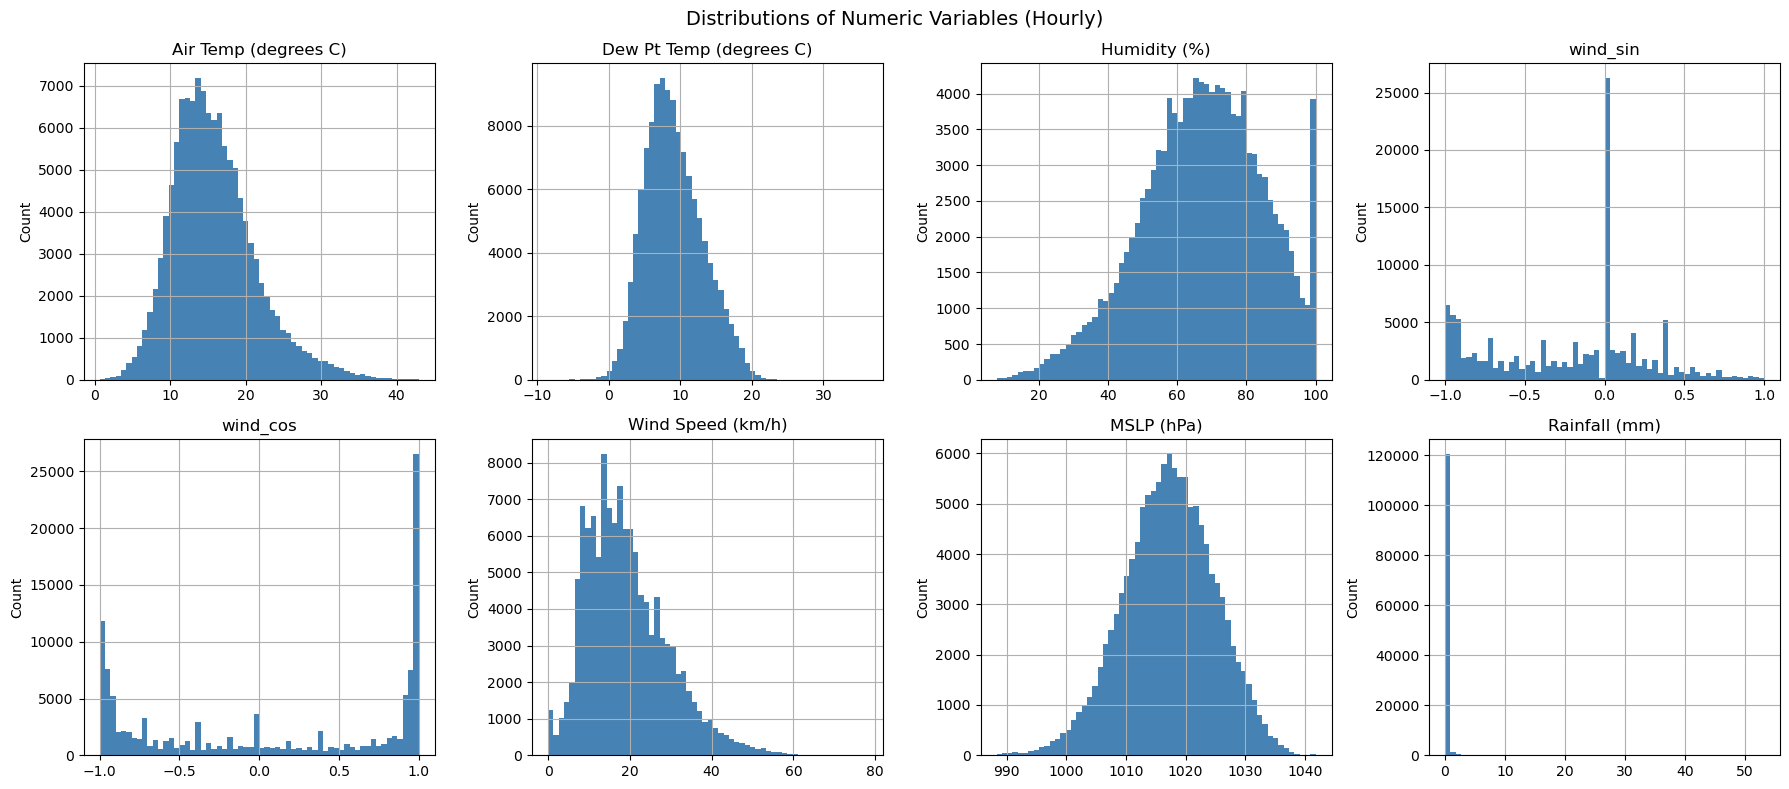

In [41]:
numeric_cols = ['Air Temp (degrees C)', 'Dew Pt Temp (degrees C)', 'Humidity (%)',
                'wind_sin', 'wind_cos', 'Wind Speed (km/h)', 'MSLP (hPa)', 'Rainfall (mm)']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Distributions of Numeric Variables (Hourly)', fontsize=14)

for ax, col in zip(axes.flatten(), numeric_cols):
    all_df[col].hist(bins=60, ax=ax, color='steelblue', edgecolor='none')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_01_variable_distributions.png', dpi=300, bbox_inches='tight')
plt.show()


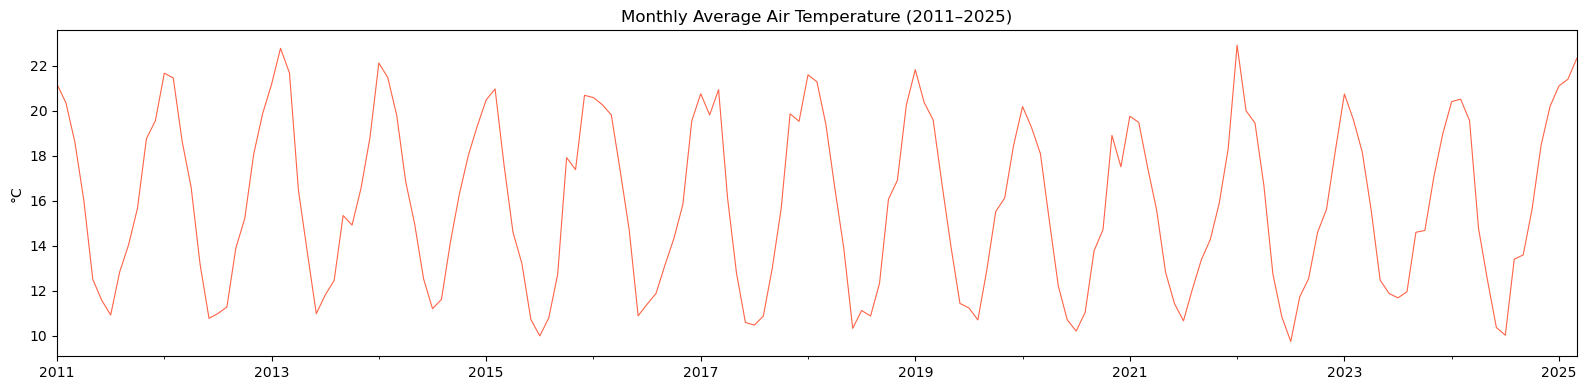

In [42]:
# Monthly average temperature — seasonal pattern
monthly_avg = all_df['Air Temp (degrees C)'].resample('ME').mean()

fig, ax = plt.subplots(figsize=(16, 4))
monthly_avg.plot(ax=ax, color='tomato', linewidth=0.8)
ax.set_title('Monthly Average Air Temperature (2011–2025)')
ax.set_ylabel('°C')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_02_monthly_avg_temperature.png', dpi=300, bbox_inches='tight')
plt.show()


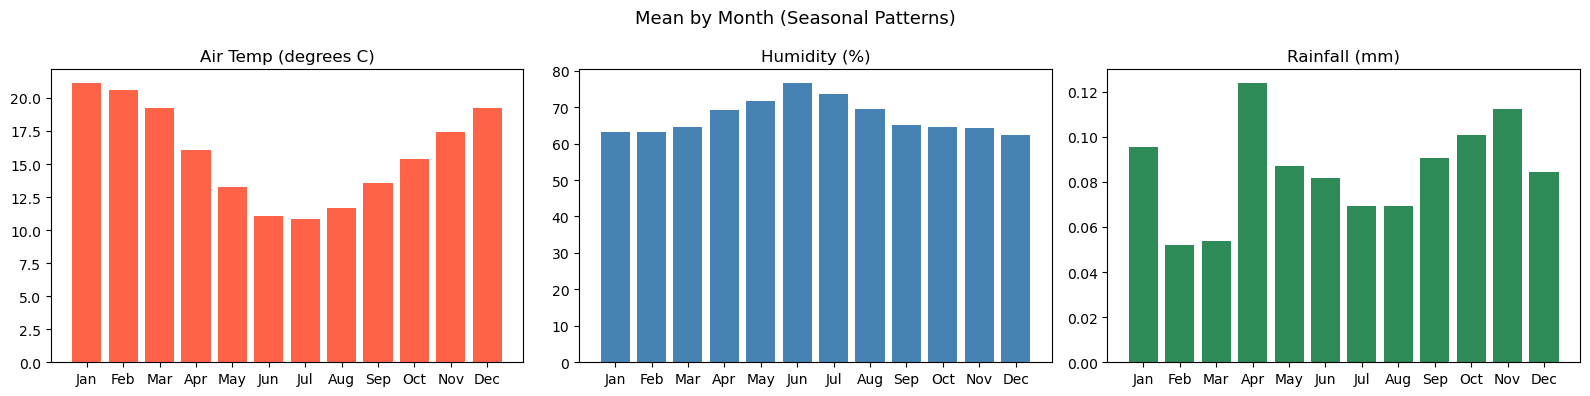

In [43]:
# Average by month-of-year to show seasonality
all_df['month'] = all_df.index.month
seasonal = all_df.groupby('month')[['Air Temp (degrees C)', 'Humidity (%)', 'Rainfall (mm)']].mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Mean by Month (Seasonal Patterns)', fontsize=13)

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

for ax, col, color in zip(axes, seasonal.columns, ['tomato', 'steelblue', 'seagreen']):
    ax.bar(seasonal.index, seasonal[col], color=color)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels)
    ax.set_title(col)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_03_seasonal_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

all_df.drop(columns=['month'], inplace=True)


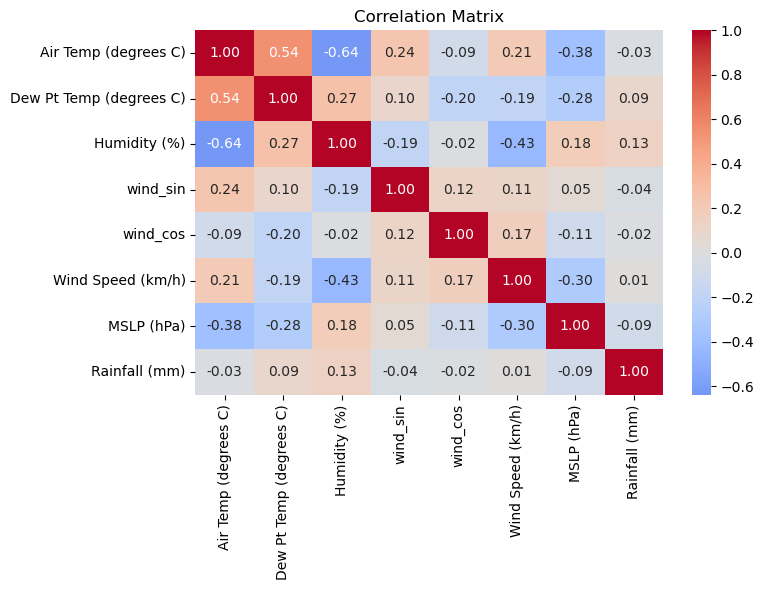

In [44]:
# Correlation heatmap (numeric columns only)
corr = all_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_04_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


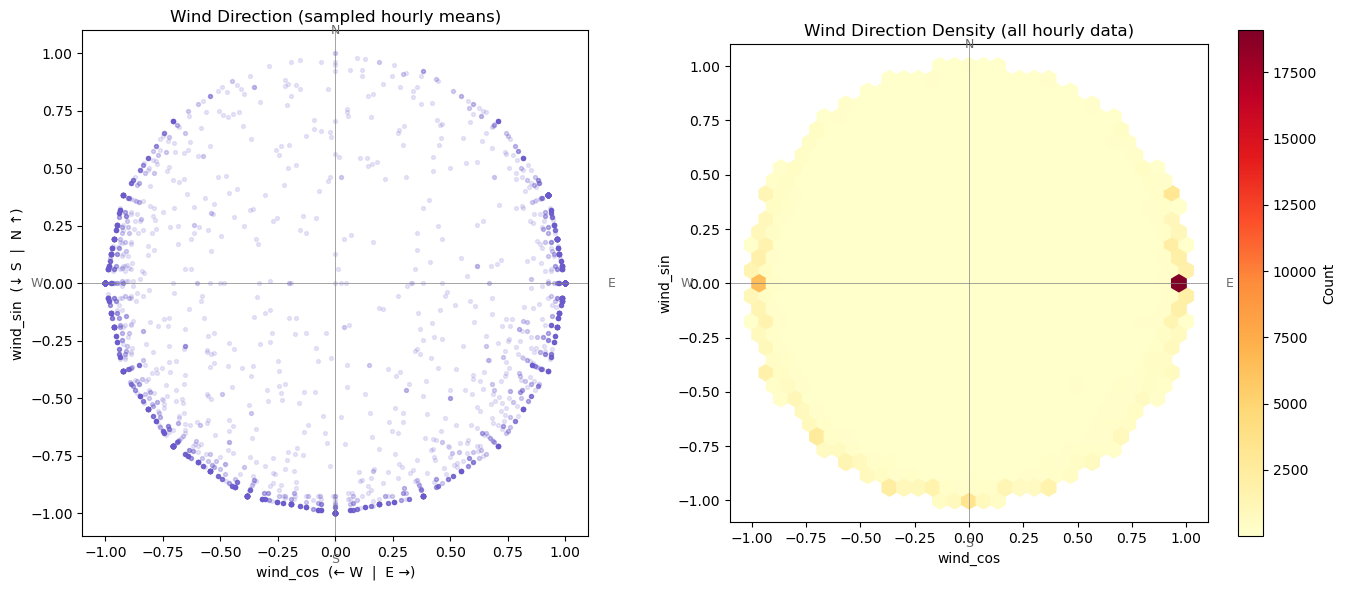

In [45]:
# Wind direction: scatter of hourly-mean sin/cos components on the unit circle
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sample = all_df[['wind_sin', 'wind_cos']].dropna().sample(5000, random_state=42)
axes[0].scatter(sample['wind_cos'], sample['wind_sin'], alpha=0.15, s=8, color='slateblue')
axes[0].set_xlabel('wind_cos  (← W  |  E →)')
axes[0].set_ylabel('wind_sin  (↓ S  |  N ↑)')
axes[0].set_title('Wind Direction (sampled hourly means)')
axes[0].axhline(0, color='grey', linewidth=0.5)
axes[0].axvline(0, color='grey', linewidth=0.5)
axes[0].set_aspect('equal')

hb = axes[1].hexbin(all_df['wind_cos'], all_df['wind_sin'],
                    gridsize=30, cmap='YlOrRd', mincnt=1)
axes[1].set_xlabel('wind_cos')
axes[1].set_ylabel('wind_sin')
axes[1].set_title('Wind Direction Density (all hourly data)')
axes[1].axhline(0, color='grey', linewidth=0.5)
axes[1].axvline(0, color='grey', linewidth=0.5)
axes[1].set_aspect('equal')
fig.colorbar(hb, ax=axes[1], label='Count')

for label, (cx, cy) in [('N',(0,1.1)),('S',(0,-1.2)),('E',(1.2,0)),('W',(-1.3,0))]:
    for ax in axes:
        ax.text(cx, cy, label, ha='center', va='center', fontsize=9, color='dimgrey')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_05_wind_direction.png', dpi=300, bbox_inches='tight')
plt.show()


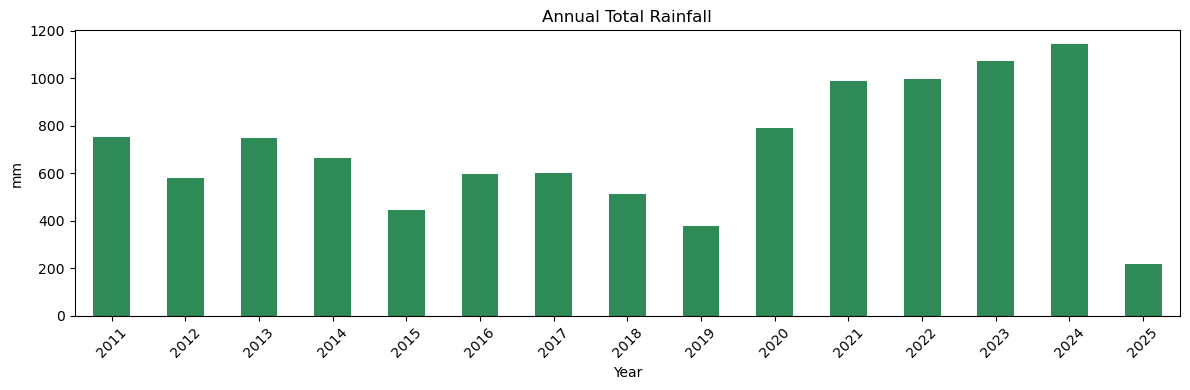

In [46]:
# Rainfall: annual total (summing hourly increments gives true annual rainfall)
all_df['year'] = all_df.index.year
annual_rain = all_df.groupby('year')['Rainfall (mm)'].sum()

fig, ax = plt.subplots(figsize=(12, 4))
annual_rain.plot(kind='bar', ax=ax, color='seagreen')
ax.set_title('Annual Total Rainfall')
ax.set_ylabel('mm')
ax.set_xlabel('Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_06_annual_rainfall.png', dpi=300, bbox_inches='tight')
plt.show()

all_df.drop(columns=['year'], inplace=True)


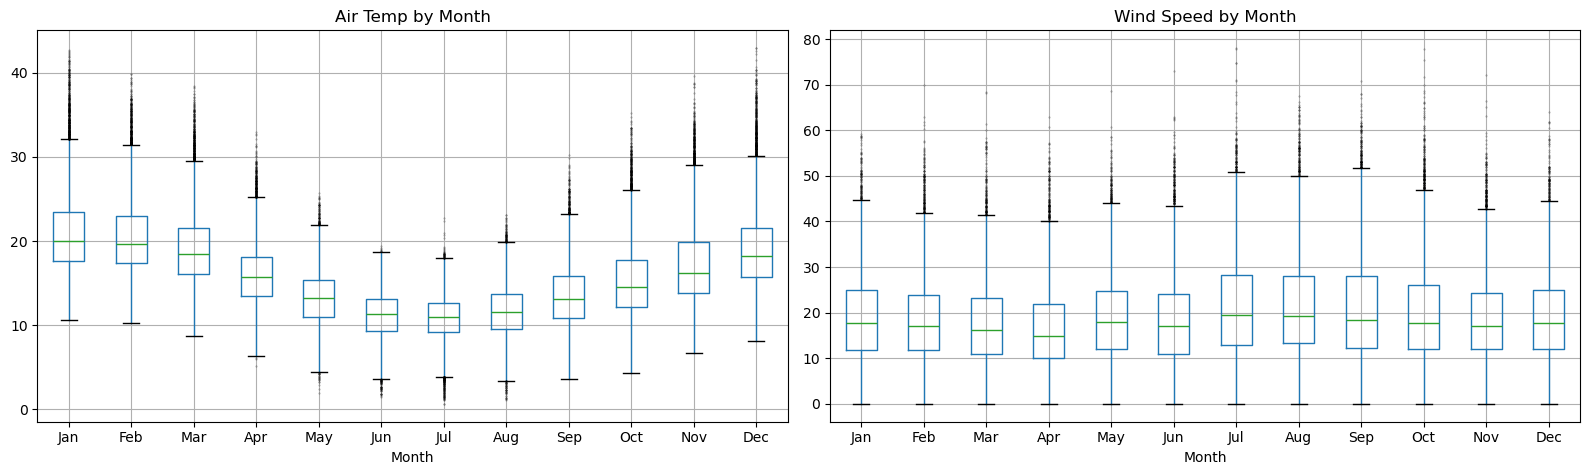

In [47]:
# Boxplots by month to visualise spread and outliers
all_df['month'] = all_df.index.month

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

all_df.boxplot(column='Air Temp (degrees C)', by='month', ax=axes[0],
               flierprops=dict(marker='.', markersize=1, alpha=0.3))
axes[0].set_title('Air Temp by Month')
axes[0].set_xlabel('Month')
axes[0].set_xticklabels(month_labels)

all_df.boxplot(column='Wind Speed (km/h)', by='month', ax=axes[1],
               flierprops=dict(marker='.', markersize=1, alpha=0.3))
axes[1].set_title('Wind Speed by Month')
axes[1].set_xlabel('Month')
axes[1].set_xticklabels(month_labels)

fig.suptitle('')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_07_boxplots_by_month.png', dpi=300, bbox_inches='tight')
plt.show()

all_df.drop(columns=['month'], inplace=True)


## Feature Engineering

In [48]:
# Aggregate hourly -> daily
daily_df = all_df.resample('D').agg({
    'Air Temp (degrees C)':     ['mean', 'min', 'max'],
    'Dew Pt Temp (degrees C)':  'mean',
    'Humidity (%)':             'mean',
    'wind_sin':                 'mean',
    'wind_cos':                 'mean',
    'Wind Speed (km/h)':        ['mean', 'max'],
    'MSLP (hPa)':               'mean',
    'Rainfall (mm)':            'sum',
})
daily_df.columns = ['_'.join(c).strip() for c in daily_df.columns]
daily_df = daily_df.rename(columns={
    'Air Temp (degrees C)_mean': 'temp_mean',
    'Air Temp (degrees C)_min':  'temp_min',
    'Air Temp (degrees C)_max':  'temp_max',
    'Dew Pt Temp (degrees C)_mean': 'dewpt_mean',
    'Humidity (%)_mean':         'humidity_mean',
    'wind_sin_mean':             'wind_sin',
    'wind_cos_mean':             'wind_cos',
    'Wind Speed (km/h)_mean':    'wind_speed_mean',
    'Wind Speed (km/h)_max':     'wind_speed_max',
    'MSLP (hPa)_mean':          'mslp_mean',
    'Rainfall (mm)_sum':        'rainfall_total',
})
daily_df = daily_df.dropna(subset=['temp_mean'])
print(daily_df.shape)
daily_df.head()

(5182, 11)


,temp_mean,temp_min,temp_max,dewpt_mean,humidity_mean,wind_sin,wind_cos,wind_speed_mean,wind_speed_max,mslp_mean,rainfall_total
Timestamp,,,,,,,,,,,
2011-01-01,19.730208,16.916667,24.600000,12.075764,61.636806,-0.050928,-0.683023,14.066667,26.400000,1011.634514,0.0
2011-01-02,18.020500,15.360000,20.683333,8.278500,53.443333,0.151935,-0.955823,21.477500,31.000000,1016.154583,0.0
2011-01-03,16.548611,14.266667,19.800000,5.492222,48.038889,0.254123,-0.919064,24.220833,30.800000,1016.905972,0.0
2011-01-04,16.827708,13.150000,20.716667,8.932153,60.083333,-0.025413,-0.861826,15.683333,25.333333,1012.337986,0.0
2011-01-05,18.089514,14.700000,21.183333,11.718333,66.663194,-0.327862,-0.665911,19.762500,29.500000,1010.039444,0.0


In [49]:
# Cyclical time features: day-of-year encodes the annual cycle
doy = daily_df.index.day_of_year
daily_df['doy_sin'] = np.sin(2 * np.pi * doy / 365)
daily_df['doy_cos'] = np.cos(2 * np.pi * doy / 365)

# Month as integer (useful for tree models)
daily_df['month'] = daily_df.index.month

daily_df[['doy_sin', 'doy_cos', 'month']].head()

,doy_sin,doy_cos,month
Timestamp,,,
2011-01-01,0.017213,0.999852,1
2011-01-02,0.034422,0.999407,1
2011-01-03,0.051620,0.998667,1
2011-01-04,0.068802,0.997630,1
2011-01-05,0.085965,0.996298,1


In [50]:
# Lag features: weather from 1, 2, 3, and 7 days ago
lag_cols = ['temp_mean', 'temp_max', 'humidity_mean', 'mslp_mean',
            'wind_speed_mean', 'rainfall_total', 'wind_sin', 'wind_cos']

for lag in [1, 2, 3, 7]:
    for col in lag_cols:
        daily_df[f'{col}_lag{lag}'] = daily_df[col].shift(lag)

print(f'Features after lag engineering: {daily_df.shape[1]}')
daily_df.head()

Features after lag engineering: 46


,temp_mean,temp_min,temp_max,dewpt_mean,humidity_mean,wind_sin,wind_cos,wind_speed_mean,wind_speed_max,mslp_mean,...,wind_sin_lag3,wind_cos_lag3,temp_mean_lag7,temp_max_lag7,humidity_mean_lag7,mslp_mean_lag7,wind_speed_mean_lag7,rainfall_total_lag7,wind_sin_lag7,wind_cos_lag7
Timestamp,,,,,,,,,,,,,,,,,,,,,
2011-01-01,19.730208,16.916667,24.600000,12.075764,61.636806,-0.050928,-0.683023,14.066667,26.400000,1011.634514,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-02,18.020500,15.360000,20.683333,8.278500,53.443333,0.151935,-0.955823,21.477500,31.000000,1016.154583,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-03,16.548611,14.266667,19.800000,5.492222,48.038889,0.254123,-0.919064,24.220833,30.800000,1016.905972,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-04,16.827708,13.150000,20.716667,8.932153,60.083333,-0.025413,-0.861826,15.683333,25.333333,1012.337986,...,-0.050928,-0.683023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-05,18.089514,14.700000,21.183333,11.718333,66.663194,-0.327862,-0.665911,19.762500,29.500000,1010.039444,...,0.151935,-0.955823,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
# Target: did it rain the NEXT day? (total > 0.2mm to exclude trace rain)
RAIN_THRESHOLD = 0.2
daily_df['rain_tomorrow'] = (daily_df['rainfall_total'].shift(-1) > RAIN_THRESHOLD).astype(int)

# Drop last row (no known next-day label) and rows with NaN lags (first 7 days)
daily_df = daily_df.dropna()

print(daily_df['rain_tomorrow'].value_counts())
print(f'Rain days: {daily_df["rain_tomorrow"].mean()*100:.1f}%')
print(f'Total rows: {len(daily_df)}')
daily_df.head()

rain_tomorrow
0    3290
1    1885
Name: count, dtype: int64
Rain days: 36.4%
Total rows: 5175


,temp_mean,temp_min,temp_max,dewpt_mean,humidity_mean,wind_sin,wind_cos,wind_speed_mean,wind_speed_max,mslp_mean,...,wind_cos_lag3,temp_mean_lag7,temp_max_lag7,humidity_mean_lag7,mslp_mean_lag7,wind_speed_mean_lag7,rainfall_total_lag7,wind_sin_lag7,wind_cos_lag7,rain_tomorrow
Timestamp,,,,,,,,,,,,,,,,,,,,,
2011-01-08,26.264889,19.580000,33.150000,14.711111,50.841111,-0.126407,0.433755,29.122222,39.000000,1008.669667,...,-0.665911,19.730208,24.600000,61.636806,1011.634514,14.066667,0.0,-0.050928,-0.683023,0
2011-01-09,20.359028,18.300000,22.183333,15.054444,71.717361,-0.054107,-0.920219,20.413889,26.200000,1017.195417,...,-0.201278,18.020500,20.683333,53.443333,1016.154583,21.477500,0.0,0.151935,-0.955823,1
2011-01-10,21.469861,19.840000,24.560000,18.823542,85.059028,-0.332436,-0.358506,8.390972,12.333333,1013.887014,...,0.986679,16.548611,19.800000,48.038889,1016.905972,24.220833,0.0,0.254123,-0.919064,1
2011-01-11,22.491111,20.816667,25.550000,20.264028,87.625694,0.316587,-0.129764,9.508333,23.800000,1009.369444,...,0.433755,16.827708,20.716667,60.083333,1012.337986,15.683333,0.0,-0.025413,-0.861826,1
2011-01-12,24.061667,21.340000,26.733333,21.028611,83.513889,0.383121,0.490689,18.098611,37.400000,1003.879444,...,-0.920219,18.089514,21.183333,66.663194,1010.039444,19.762500,0.0,-0.327862,-0.665911,1


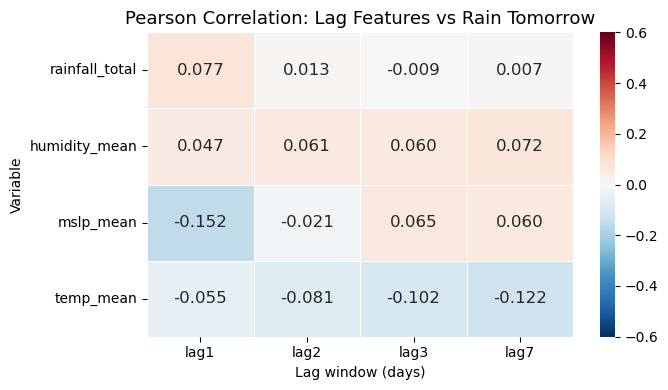

Saved: dc1_extra_lag_target_correlation_heatmap.png


In [52]:
# Correlation heatmap: lag features vs Rain target (rain_tomorrow)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

lag_vars = ['rainfall_total', 'humidity_mean', 'mslp_mean', 'temp_mean']
lag_days = [1, 2, 3, 7]

pivot = pd.DataFrame(index=lag_vars,
                     columns=[f'lag{d}' for d in lag_days],
                     dtype=float)
for var in lag_vars:
    for d in lag_days:
        col = f'{var}_lag{d}'
        if col in daily_df.columns:
            pivot.loc[var, f'lag{d}'] = daily_df[col].corr(daily_df['rain_tomorrow'])

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot.astype(float), annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, vmin=-0.6, vmax=0.6,
            linewidths=0.5, annot_kws={'size': 12}, ax=ax)
ax.set_title('Pearson Correlation: Lag Features vs Rain Tomorrow', fontsize=13)
ax.set_xlabel('Lag window (days)')
ax.set_ylabel('Variable')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_extra_lag_target_correlation_heatmap.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved: dc1_extra_lag_target_correlation_heatmap.png')


## PCA

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Temporal split: last 2 years as test
split_date = '2023-01-01'
train = daily_df[daily_df.index < split_date]
test  = daily_df[daily_df.index >= split_date]

X_train = train.drop(columns=['rain_tomorrow'])
y_train = train['rain_tomorrow']
X_test  = test.drop(columns=['rain_tomorrow'])
y_test  = test['rain_tomorrow']

print(f'Train: {len(X_train)} days  ({X_train.index.min().date()} to {X_train.index.max().date()})')
print(f'Test:  {len(X_test)} days  ({X_test.index.min().date()} to {X_test.index.max().date()})')
print(f'Train rain rate: {y_train.mean()*100:.1f}%  |  Test rain rate: {y_test.mean()*100:.1f}%')


Train: 4373 days  (2011-01-08 to 2022-12-31)
Test:  802 days  (2023-01-01 to 2025-03-12)
Train rain rate: 35.2%  |  Test rain rate: 43.0%


In [54]:
# Scale: fit on train only, apply to both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [55]:
# Fit PCA on training set only
pca = PCA()
pca.fit(X_train_scaled)

explained = pca.explained_variance_ratio_
cumulative = explained.cumsum()

# How many components reach 95%?
n_95 = (cumulative < 0.95).sum() + 1
print(f'Components to explain 95% of variance: {n_95} (out of {X_train_scaled.shape[1]})')

Components to explain 95% of variance: 27 (out of 46)


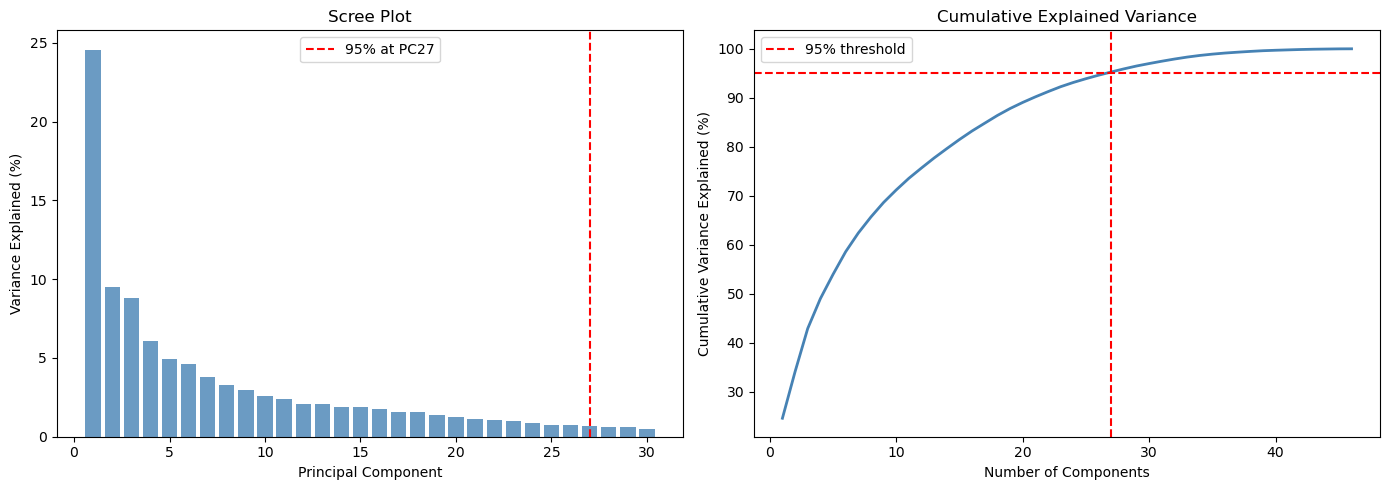

In [56]:
# Scree plot + cumulative explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, 31), explained[:30] * 100, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Scree Plot')
axes[0].axvline(n_95, color='red', linestyle='--', label=f'95% at PC{n_95}')
axes[0].legend()

axes[1].plot(range(1, len(cumulative) + 1), cumulative * 100, color='steelblue', linewidth=2)
axes[1].axhline(95, color='red', linestyle='--', label='95% threshold')
axes[1].axvline(n_95, color='red', linestyle='--')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_08_pca_scree_cumulative.png', dpi=300, bbox_inches='tight')
plt.show()


In [57]:
# Transform train and test to n_95 components
pca_final = PCA(n_components=n_95)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca  = pca_final.transform(X_test_scaled)

print(f'X_train_pca shape: {X_train_pca.shape}')
print(f'X_test_pca shape:  {X_test_pca.shape}')

X_train_pca shape: (4373, 27)
X_test_pca shape:  (802, 27)


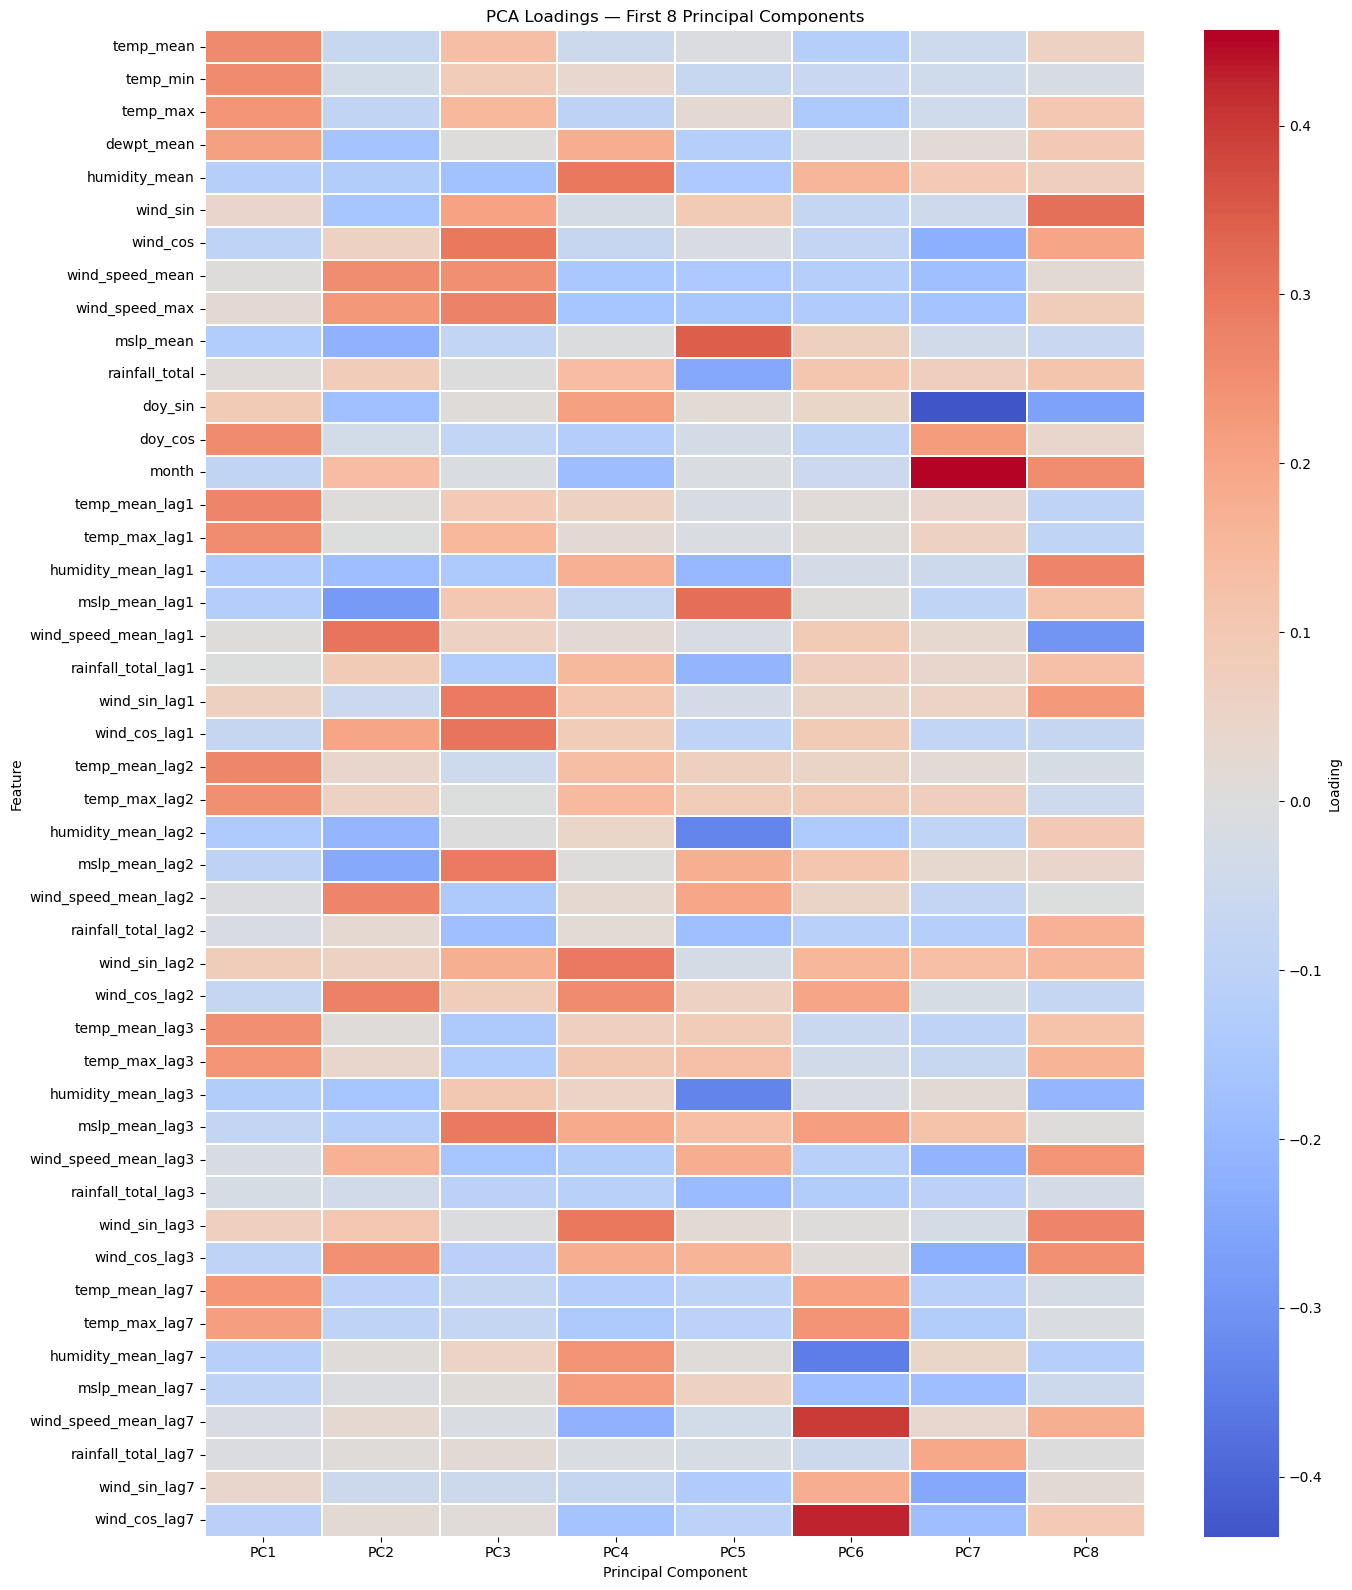

In [58]:
# Loadings heatmap: which original features drive each of the first 8 PCs
import seaborn as sns

n_show = 8
loadings = pd.DataFrame(
    pca_final.components_[:n_show].T,
    index=X_train.columns,
    columns=[f'PC{i+1}' for i in range(n_show)]
)

fig, ax = plt.subplots(figsize=(14, 16))
sns.heatmap(loadings, cmap='coolwarm', center=0, ax=ax,
            linewidths=0.3, cbar_kws={'label': 'Loading'})
ax.set_title('PCA Loadings — First 8 Principal Components')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_09_pca_loadings_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


## Logistic Regression

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

# Train on PCA-transformed data
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_pca, y_train)

y_pred  = lr.predict(X_test_pca)
y_proba = lr.predict_proba(X_test_pca)[:, 1]

print('Classification Report')
print('=' * 45)
print(classification_report(y_test, y_pred, target_names=['No Rain', 'Rain']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}')


Classification Report
              precision    recall  f1-score   support

     No Rain       0.70      0.91      0.79       457
        Rain       0.80      0.48      0.60       345

    accuracy                           0.72       802
   macro avg       0.75      0.69      0.69       802
weighted avg       0.74      0.72      0.71       802

ROC-AUC: 0.7945


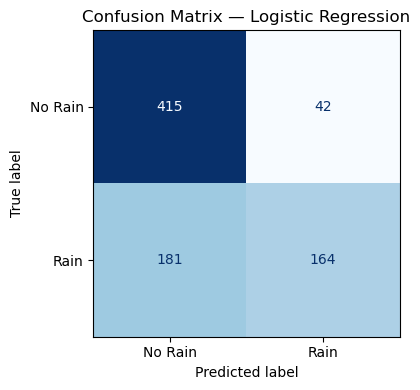

In [60]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=['No Rain', 'Rain']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_10_lr_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


---
## Logistic Regression — No Lag, No Cyclical Features

Re-runs the full PCA + Logistic Regression pipeline using only the **base daily features**,
dropping all lag columns and all sin/cos cyclical encodings (`wind_sin`, `wind_cos`, `doy_sin`, `doy_cos`).

This lets us compare directly whether the lag features and cyclical encodings add predictive value.


In [61]:
# Feature set: base daily weather only — no lags, no sin/cos cyclical columns
exclude_cols = (
    ['rain_tomorrow']
    + [c for c in daily_df.columns if '_lag' in c]
    + [c for c in daily_df.columns if c in ['doy_sin', 'doy_cos', 'wind_sin', 'wind_cos']]
)
feature_cols_base = [c for c in daily_df.columns if c not in exclude_cols]
print(f'Features used ({len(feature_cols_base)}):')
print(feature_cols_base)

split_date = '2023-01-01'
train2 = daily_df[daily_df.index < split_date]
test2  = daily_df[daily_df.index >= split_date]

X_train2 = train2[feature_cols_base]
y_train2 = train2['rain_tomorrow']
X_test2  = test2[feature_cols_base]
y_test2  = test2['rain_tomorrow']

print(f'\nTrain: {len(X_train2)} days | Test: {len(X_test2)} days')
print(f'Train rain rate: {y_train2.mean()*100:.1f}%  |  Test rain rate: {y_test2.mean()*100:.1f}%')


Features used (10):
['temp_mean', 'temp_min', 'temp_max', 'dewpt_mean', 'humidity_mean', 'wind_speed_mean', 'wind_speed_max', 'mslp_mean', 'rainfall_total', 'month']

Train: 4373 days | Test: 802 days
Train rain rate: 35.2%  |  Test rain rate: 43.0%


In [62]:
# Scale and PCA — fit on train2 only
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

scaler2 = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled  = scaler2.transform(X_test2)

pca2 = PCA()
pca2.fit(X_train2_scaled)
cumulative2 = pca2.explained_variance_ratio_.cumsum()
n_95_2 = int((cumulative2 < 0.95).sum()) + 1
print(f'Components for 95% variance: {n_95_2} (out of {X_train2_scaled.shape[1]} features)')

pca2_final = PCA(n_components=n_95_2)
X_train2_pca = pca2_final.fit_transform(X_train2_scaled)
X_test2_pca  = pca2_final.transform(X_test2_scaled)
print(f'X_train2_pca shape: {X_train2_pca.shape}')


Components for 95% variance: 6 (out of 10 features)
X_train2_pca shape: (4373, 6)


In [63]:
# Logistic Regression on base features (no lag, no cyclical)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)

lr2 = LogisticRegression(max_iter=1000, random_state=42)
lr2.fit(X_train2_pca, y_train2)

y_pred2  = lr2.predict(X_test2_pca)
y_proba2 = lr2.predict_proba(X_test2_pca)[:, 1]

print('Classification Report — No Lag / No Cyclical')
print('=' * 50)
print(classification_report(y_test2, y_pred2, target_names=['No Rain', 'Rain']))
print(f'ROC-AUC: {roc_auc_score(y_test2, y_proba2):.4f}')


Classification Report — No Lag / No Cyclical
              precision    recall  f1-score   support

     No Rain       0.67      0.94      0.78       457
        Rain       0.83      0.39      0.53       345

    accuracy                           0.70       802
   macro avg       0.75      0.67      0.66       802
weighted avg       0.74      0.70      0.67       802

ROC-AUC: 0.7731


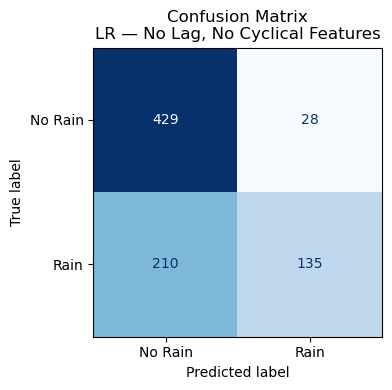

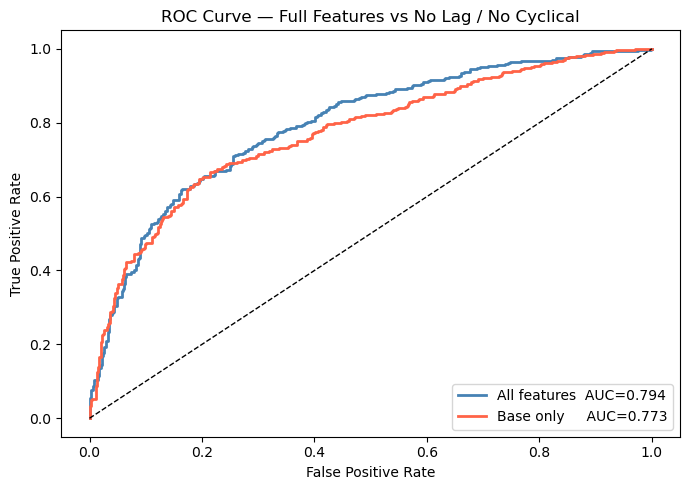

In [64]:
import matplotlib.pyplot as plt

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test2, y_pred2),
                       display_labels=['No Rain', 'Rain']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix\nLR — No Lag, No Cyclical Features')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_11_lr_no_lag_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# ROC curve comparison
from sklearn.metrics import roc_curve
fig, ax = plt.subplots(figsize=(7, 5))
for y_prob, label, colour in [
    (y_proba,  f'All features  AUC={roc_auc_score(y_test,  y_proba):.3f}',  'steelblue'),
    (y_proba2, f'Base only     AUC={roc_auc_score(y_test2, y_proba2):.3f}', 'tomato'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, lw=2, color=colour, label=label)
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Full Features vs No Lag / No Cyclical')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_12_lr_roc_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


---
## Logistic Regression — Class Balanced (`class_weight='balanced'`)

Reuses the PCA-transformed features from both the full model and the no-lag model,
but fits with `class_weight='balanced'` to penalise misclassifying the minority class more heavily.
Compare precision/recall/F1 and ROC-AUC against the unweighted baselines above.


In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)

# Full features — balanced
lr_bal = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_bal.fit(X_train_pca, y_train)
y_pred_bal  = lr_bal.predict(X_test_pca)
y_proba_bal = lr_bal.predict_proba(X_test_pca)[:, 1]

print('Full features — class_weight=balanced')
print('=' * 45)
print(classification_report(y_test, y_pred_bal, target_names=['No Rain', 'Rain']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_bal):.4f}')


Full features — class_weight=balanced
              precision    recall  f1-score   support

     No Rain       0.76      0.75      0.75       457
        Rain       0.67      0.68      0.68       345

    accuracy                           0.72       802
   macro avg       0.72      0.72      0.72       802
weighted avg       0.72      0.72      0.72       802

ROC-AUC: 0.7967


In [66]:
# No-lag / no-cyclical features — balanced
lr2_bal = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr2_bal.fit(X_train2_pca, y_train2)
y_pred2_bal  = lr2_bal.predict(X_test2_pca)
y_proba2_bal = lr2_bal.predict_proba(X_test2_pca)[:, 1]

print('No-lag / no-cyclical — class_weight=balanced')
print('=' * 45)
print(classification_report(y_test2, y_pred2_bal, target_names=['No Rain', 'Rain']))
print(f'ROC-AUC: {roc_auc_score(y_test2, y_proba2_bal):.4f}')


No-lag / no-cyclical — class_weight=balanced
              precision    recall  f1-score   support

     No Rain       0.75      0.79      0.77       457
        Rain       0.70      0.65      0.68       345

    accuracy                           0.73       802
   macro avg       0.73      0.72      0.72       802
weighted avg       0.73      0.73      0.73       802

ROC-AUC: 0.7737


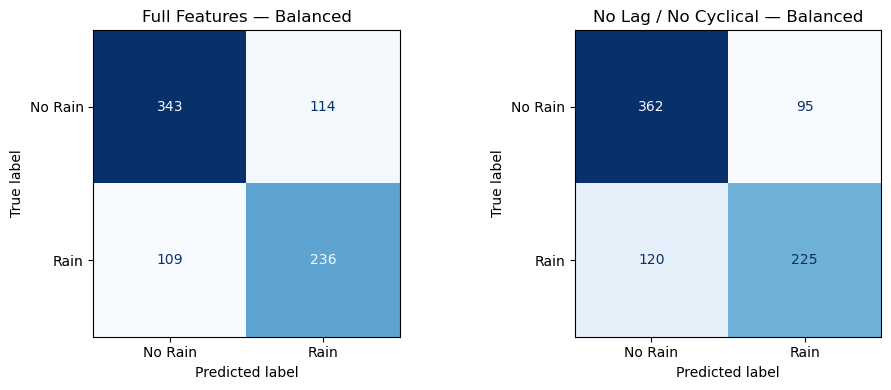

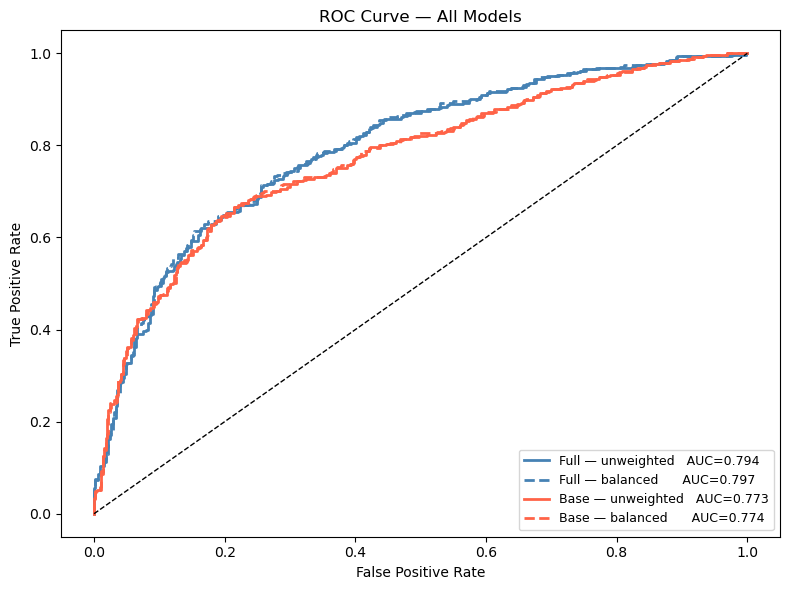

In [67]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, y_p, title in [
    (axes[0], y_pred_bal,  'Full Features — Balanced'),
    (axes[1], y_pred2_bal, 'No Lag / No Cyclical — Balanced'),
]:
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_p),
                          display_labels=['No Rain', 'Rain']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_13_balanced_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

# ROC: all 4 models on one axes
fig, ax = plt.subplots(figsize=(8, 6))
for y_prob, label, colour, ls in [
    (y_proba,     f'Full — unweighted   AUC={roc_auc_score(y_test,  y_proba):.3f}',     'steelblue', '-'),
    (y_proba_bal, f'Full — balanced      AUC={roc_auc_score(y_test,  y_proba_bal):.3f}', 'steelblue', '--'),
    (y_proba2,    f'Base — unweighted   AUC={roc_auc_score(y_test2, y_proba2):.3f}',    'tomato',    '-'),
    (y_proba2_bal,f'Base — balanced      AUC={roc_auc_score(y_test2, y_proba2_bal):.3f}','tomato',    '--'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, lw=2, color=colour, linestyle=ls, label=label)
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — All Models')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_14_all_models_roc.png', dpi=300, bbox_inches='tight')
plt.show()


---
## Feature Importance Tables

Logistic Regression coefficients live in PCA space, not the original feature space.
To recover per-feature importance we project back:

```
effective_importance = PCA_loadings @ LR_coefficients
```

Positive values push the model toward predicting Rain; negative toward No Rain.
Absolute value gives overall importance regardless of direction.
Tables are shown for all four models.


In [68]:
import pandas as pd
import numpy as np

def feature_importance_table(lr_model, pca_model, feature_names, top_n=None):
    """Project LR coefficients back through PCA loadings."""
    loadings   = pca_model.components_.T          # shape (n_features, n_components)
    coef       = lr_model.coef_[0]                # shape (n_components,)
    importance = loadings @ coef                  # shape (n_features,)
    df = pd.DataFrame({
        'Feature':    feature_names,
        'Importance': importance,
        'Abs':        np.abs(importance),
        'Direction':  ['→ Rain' if v > 0 else '→ No Rain' for v in importance],
    }).sort_values('Abs', ascending=False).reset_index(drop=True)
    df.index += 1
    if top_n:
        df = df.head(top_n)
    return df.drop(columns='Abs')

# ── Full features (unweighted) ──
print('=' * 60)
print('Model 1 — Full Features, Unweighted LR')
print('=' * 60)
t1 = feature_importance_table(lr, pca_final, X_train.columns.tolist())
print(t1.to_string())

# ── Full features (balanced) ──
print('\n' + '=' * 60)
print('Model 2 — Full Features, Balanced LR')
print('=' * 60)
t2 = feature_importance_table(lr_bal, pca_final, X_train.columns.tolist())
print(t2.to_string())

# ── No-lag / no-cyclical (unweighted) ──
print('\n' + '=' * 60)
print('Model 3 — No Lag / No Cyclical, Unweighted LR')
print('=' * 60)
t3 = feature_importance_table(lr2, pca2_final, X_train2.columns.tolist())
print(t3.to_string())

# ── No-lag / no-cyclical (balanced) ──
print('\n' + '=' * 60)
print('Model 4 — No Lag / No Cyclical, Balanced LR')
print('=' * 60)
t4 = feature_importance_table(lr2_bal, pca2_final, X_train2.columns.tolist())
print(t4.to_string())


Model 1 — Full Features, Unweighted LR
                 Feature  Importance  Direction
1              mslp_mean   -0.601164  → No Rain
2               wind_cos    0.450764     → Rain
3         rainfall_total    0.362246     → Rain
4         mslp_mean_lag1   -0.236188  → No Rain
5         mslp_mean_lag3    0.233394     → Rain
6          humidity_mean    0.179841     → Rain
7             dewpt_mean    0.109677     → Rain
8     humidity_mean_lag3   -0.108763  → No Rain
9          wind_cos_lag1    0.106446     → Rain
10         wind_cos_lag7    0.099777     → Rain
11    humidity_mean_lag1    0.099570     → Rain
12         temp_max_lag1   -0.098413  → No Rain
13         wind_sin_lag7   -0.092792  → No Rain
14         wind_sin_lag2   -0.090395  → No Rain
15        wind_speed_max    0.089451     → Rain
16         wind_sin_lag3    0.084894     → Rain
17  wind_speed_mean_lag3   -0.078525  → No Rain
18        mslp_mean_lag7    0.077549     → Rain
19        temp_mean_lag1   -0.072264  → No Rain
2

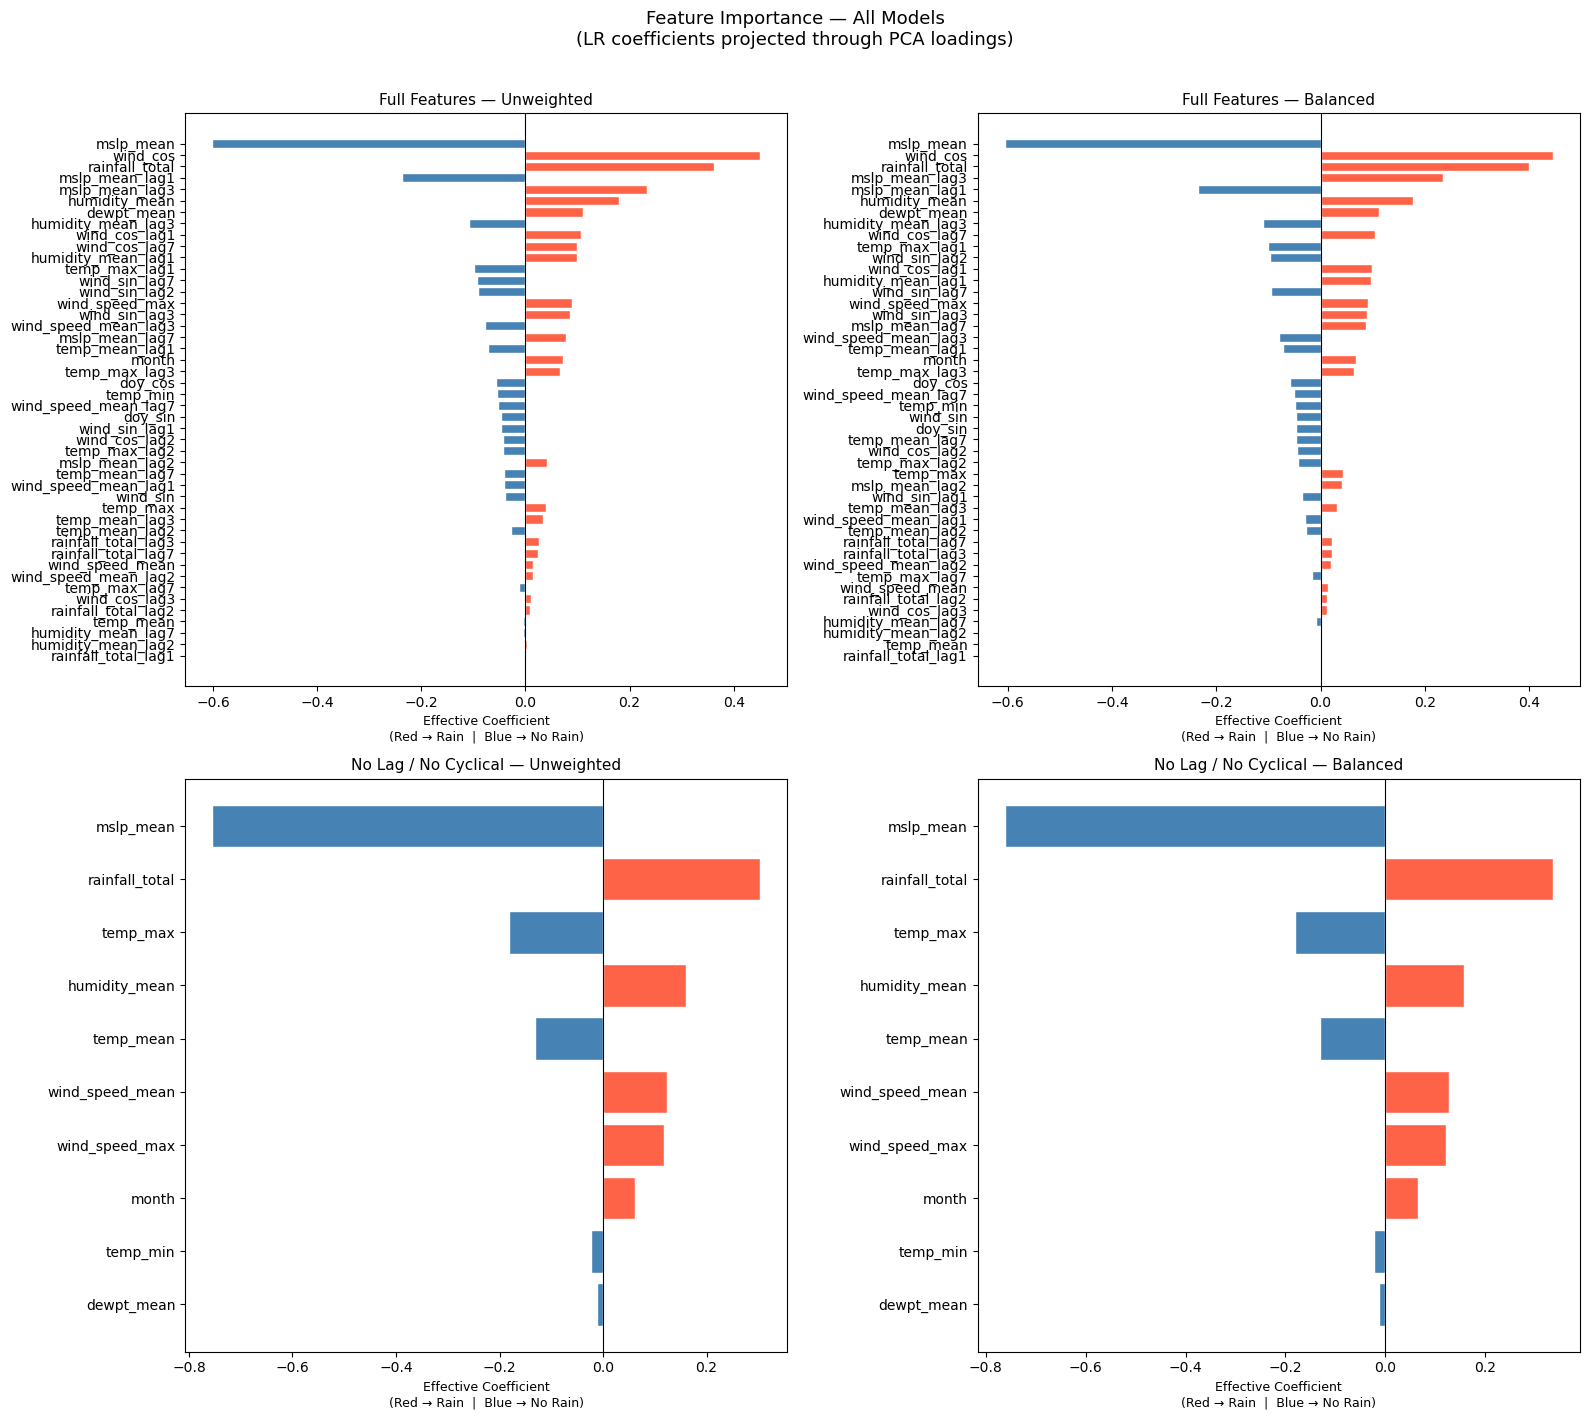

In [69]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
titles = [
    'Full Features — Unweighted',
    'Full Features — Balanced',
    'No Lag / No Cyclical — Unweighted',
    'No Lag / No Cyclical — Balanced',
]
tables = [t1, t2, t3, t4]

for ax, df, title in zip(axes.flatten(), tables, titles):
    colours = ['tomato' if d == '→ Rain' else 'steelblue' for d in df['Direction']]
    ax.barh(df['Feature'][::-1], df['Importance'][::-1], color=colours[::-1], edgecolor='white')
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Effective Coefficient\n(Red → Rain  |  Blue → No Rain)', fontsize=9)

plt.suptitle('Feature Importance — All Models\n(LR coefficients projected through PCA loadings)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_15_feature_importance_all_models.png', dpi=300, bbox_inches='tight')
plt.show()


---
## Class-Balanced LR — Pruned Features (drop < 0.2% relative importance)

Uses the balanced model's effective feature importances to remove any feature
whose absolute contribution is less than **0.2%** of the total absolute importance sum.
The pruned feature set is then re-run through the full pipeline: scale → PCA → LR (balanced).


In [70]:
import numpy as np
import pandas as pd

# Compute effective importance from the full-feature balanced model
loadings_bal  = pca_final.components_.T       # (n_features, n_components)
importance_bal = loadings_bal @ lr_bal.coef_[0]  # (n_features,)
abs_imp       = np.abs(importance_bal)
rel_imp_pct   = 100 * abs_imp / abs_imp.sum()  # relative % of total

imp_df = pd.DataFrame({
    'Feature':       X_train.columns.tolist(),
    'Importance':    importance_bal,
    'Abs':           abs_imp,
    'Relative (%)':  rel_imp_pct,
    'Direction':     ['→ Rain' if v > 0 else '→ No Rain' for v in importance_bal],
}).sort_values('Abs', ascending=False).reset_index(drop=True)
imp_df.index += 1

THRESHOLD = 0.2  # drop features below this % of total importance
keep_mask    = imp_df['Relative (%)'] >= THRESHOLD
drop_mask    = ~keep_mask

print(f'Importance threshold : {THRESHOLD}% of total')
print(f'Features kept        : {keep_mask.sum()} / {len(imp_df)}')
print(f'Features dropped     : {drop_mask.sum()}')
print()
print(imp_df[['Feature','Relative (%)','Direction']].to_string())

kept_features    = imp_df.loc[keep_mask,  'Feature'].tolist()
dropped_features = imp_df.loc[drop_mask, 'Feature'].tolist()
print(f'\nDropped: {dropped_features}')


Importance threshold : 0.2% of total
Features kept        : 42 / 46
Features dropped     : 4

                 Feature  Relative (%)  Direction
1              mslp_mean     14.427617  → No Rain
2               wind_cos     10.601058     → Rain
3         rainfall_total      9.501846     → Rain
4         mslp_mean_lag3      5.612767     → Rain
5         mslp_mean_lag1      5.609126  → No Rain
6          humidity_mean      4.237231     → Rain
7             dewpt_mean      2.675875     → Rain
8     humidity_mean_lag3      2.615462  → No Rain
9          wind_cos_lag7      2.500454     → Rain
10         temp_max_lag1      2.420305  → No Rain
11         wind_sin_lag2      2.335608  → No Rain
12         wind_cos_lag1      2.326239     → Rain
13    humidity_mean_lag1      2.323433     → Rain
14         wind_sin_lag7      2.288262  → No Rain
15        wind_speed_max      2.168852     → Rain
16         wind_sin_lag3      2.125612     → Rain
17        mslp_mean_lag7      2.050184     → Rain
18  wi

In [71]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)

# Subset to kept features
X_train_pr = X_train[kept_features]
X_test_pr  = X_test[kept_features]

# Scale
scaler_pr = StandardScaler()
X_train_pr_scaled = scaler_pr.fit_transform(X_train_pr)
X_test_pr_scaled  = scaler_pr.transform(X_test_pr)

# PCA
pca_pr = PCA()
pca_pr.fit(X_train_pr_scaled)
cum_pr = pca_pr.explained_variance_ratio_.cumsum()
n_95_pr = int((cum_pr < 0.95).sum()) + 1
print(f'PCA components for 95% variance: {n_95_pr} (from {len(kept_features)} features)')

pca_pr_final = PCA(n_components=n_95_pr)
X_train_pr_pca = pca_pr_final.fit_transform(X_train_pr_scaled)
X_test_pr_pca  = pca_pr_final.transform(X_test_pr_scaled)

# Logistic Regression — balanced
lr_pr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_pr.fit(X_train_pr_pca, y_train)

y_pred_pr  = lr_pr.predict(X_test_pr_pca)
y_proba_pr = lr_pr.predict_proba(X_test_pr_pca)[:, 1]

print('\nClassification Report — Pruned Features, Balanced LR')
print('=' * 52)
print(classification_report(y_test, y_pred_pr, target_names=['No Rain', 'Rain']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_pr):.4f}')


PCA components for 95% variance: 25 (from 42 features)

Classification Report — Pruned Features, Balanced LR
              precision    recall  f1-score   support

     No Rain       0.75      0.75      0.75       457
        Rain       0.67      0.68      0.67       345

    accuracy                           0.72       802
   macro avg       0.71      0.71      0.71       802
weighted avg       0.72      0.72      0.72       802

ROC-AUC: 0.7958


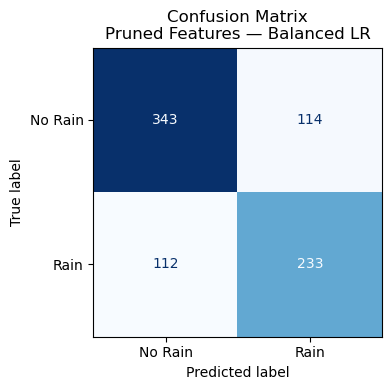

Feature Importance — Pruned Balanced Model
                 Feature  Importance  Relative (%)  Direction
1              mslp_mean     -0.6145       14.5394  → No Rain
2               wind_cos      0.4289       10.1491     → Rain
3         rainfall_total      0.4098        9.6964     → Rain
4         mslp_mean_lag3      0.2447        5.7898     → Rain
5         mslp_mean_lag1     -0.2404        5.6879  → No Rain
6          humidity_mean      0.1631        3.8592     → Rain
7          wind_cos_lag7      0.1320        3.1225     → Rain
8     humidity_mean_lag3     -0.1216        2.8784  → No Rain
9          wind_sin_lag2     -0.1190        2.8163  → No Rain
10            dewpt_mean      0.1031        2.4397     → Rain
11         wind_sin_lag3      0.0978        2.3140     → Rain
12         temp_max_lag1     -0.0939        2.2230  → No Rain
13    humidity_mean_lag1      0.0919        2.1750     → Rain
14         wind_sin_lag7     -0.0880        2.0834  → No Rain
15  wind_speed_mean_lag3   

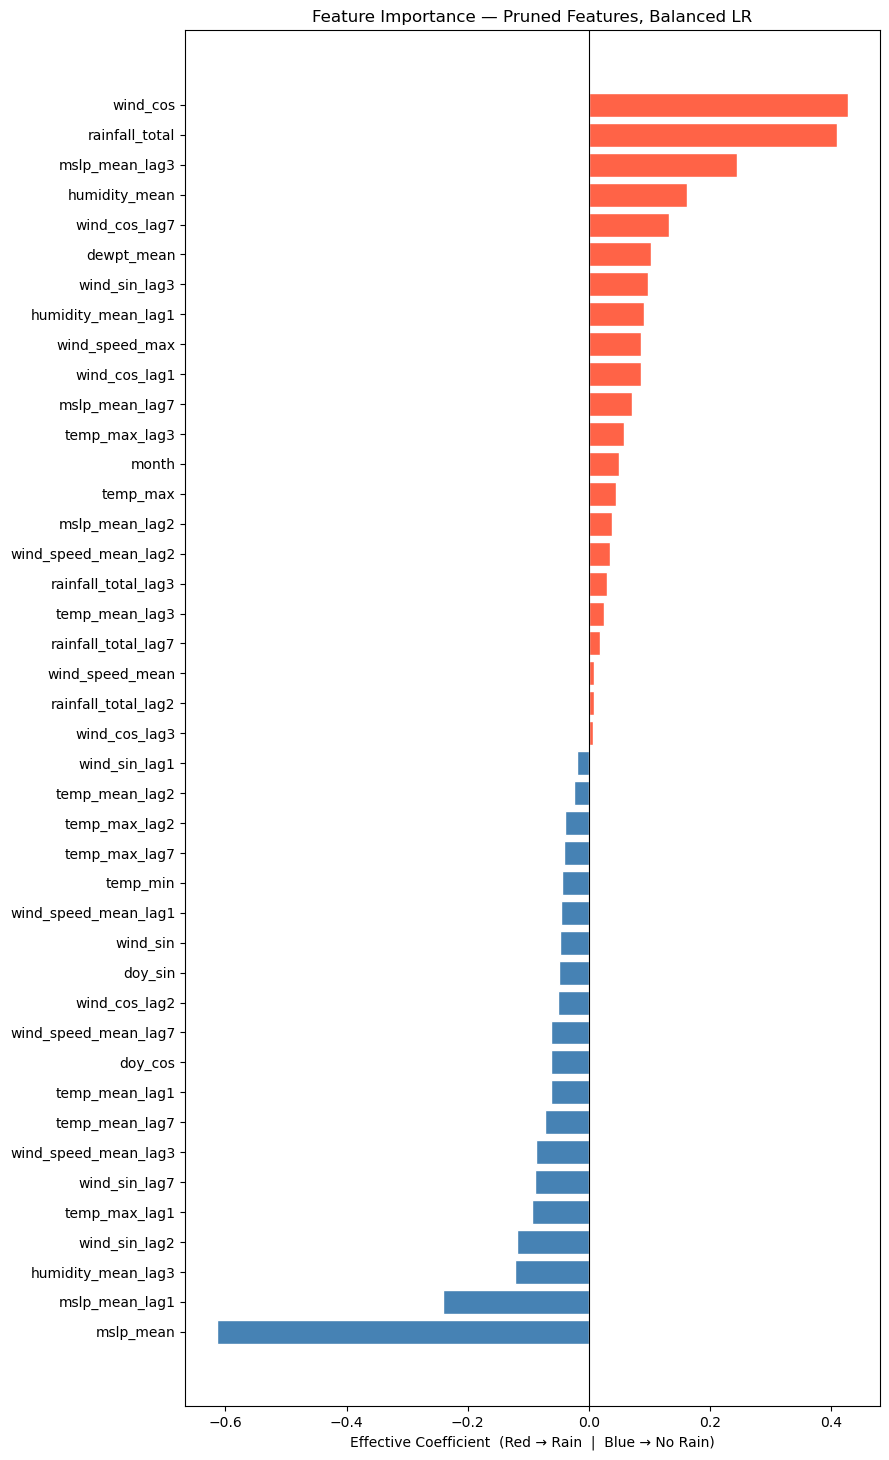

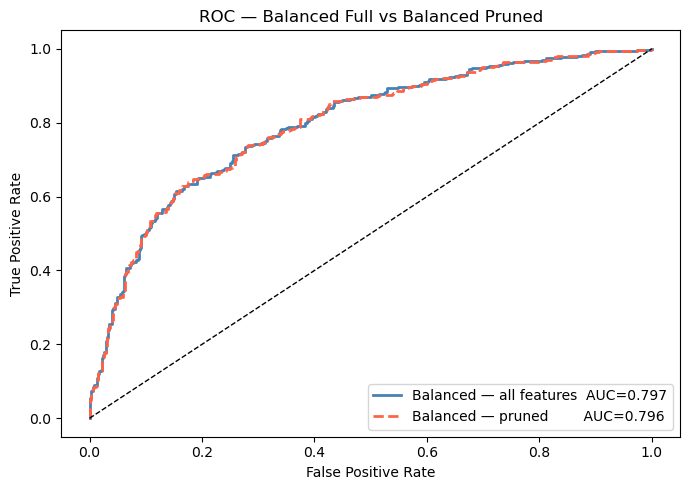

In [72]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_pr),
                       display_labels=['No Rain', 'Rain']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix\nPruned Features — Balanced LR')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_16_pruned_balanced_confusion.png', dpi=300, bbox_inches='tight')
plt.show()

# Feature importance table for pruned model
loadings_pr   = pca_pr_final.components_.T
imp_pr        = loadings_pr @ lr_pr.coef_[0]
imp_pr_df = pd.DataFrame({
    'Feature':      kept_features,
    'Importance':   imp_pr,
    'Relative (%)': 100 * np.abs(imp_pr) / np.abs(imp_pr).sum(),
    'Direction':    ['→ Rain' if v > 0 else '→ No Rain' for v in imp_pr],
}).sort_values('Relative (%)', ascending=False).reset_index(drop=True)
imp_pr_df.index += 1
print('Feature Importance — Pruned Balanced Model')
print('=' * 52)
print(imp_pr_df[['Feature','Importance','Relative (%)','Direction']].round(4).to_string())

# Bar chart
imp_sorted = imp_pr_df.sort_values('Importance')
colours = ['tomato' if v > 0 else 'steelblue' for v in imp_sorted['Importance']]
fig, ax = plt.subplots(figsize=(9, max(4, len(kept_features) * 0.35)))
ax.barh(imp_sorted['Feature'], imp_sorted['Importance'], color=colours, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Effective Coefficient  (Red → Rain  |  Blue → No Rain)')
ax.set_title('Feature Importance — Pruned Features, Balanced LR')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_17_pruned_balanced_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# ROC comparison: balanced full vs balanced pruned
fig, ax = plt.subplots(figsize=(7, 5))
for y_prob, label, colour, ls in [
    (y_proba_bal, f'Balanced — all features  AUC={roc_auc_score(y_test, y_proba_bal):.3f}', 'steelblue', '-'),
    (y_proba_pr,  f'Balanced — pruned        AUC={roc_auc_score(y_test, y_proba_pr):.3f}',  'tomato',    '--'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, lw=2, color=colour, linestyle=ls, label=label)
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC — Balanced Full vs Balanced Pruned')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_18_pruned_vs_full_roc.png', dpi=300, bbox_inches='tight')
plt.show()


---
## SMOTE — Synthetic Minority Over-sampling

SMOTE generates synthetic Rain-day samples by interpolating between existing minority-class
neighbours in feature space. Applied **after scaling, before PCA** to avoid contaminating
the test set or the PCA fit.

Pipeline: Scale (train only) → SMOTE (train only) → PCA (on resampled train) → LR


In [73]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)
import numpy as np

# --- Scale (fit on original train only) ---
scaler_sm = StandardScaler()
X_train_sm_scaled = scaler_sm.fit_transform(X_train)
X_test_sm_scaled  = scaler_sm.transform(X_test)

print('Before SMOTE:')
print(f'  Rain: {y_train.sum()}  |  No Rain: {(y_train==0).sum()}')

# --- SMOTE (applied to scaled train only) ---
sm = SMOTE(random_state=42)
X_train_sm_res, y_train_sm_res = sm.fit_resample(X_train_sm_scaled, y_train)

print('After SMOTE:')
print(f'  Rain: {y_train_sm_res.sum()}  |  No Rain: {(y_train_sm_res==0).sum()}')
print(f'  Total training samples: {len(y_train_sm_res)}')

# --- PCA (fit on resampled train) ---
pca_sm = PCA()
pca_sm.fit(X_train_sm_res)
cum_sm = pca_sm.explained_variance_ratio_.cumsum()
n_95_sm = int((cum_sm < 0.95).sum()) + 1
print(f'\nPCA components for 95% variance: {n_95_sm}')

pca_sm_final = PCA(n_components=n_95_sm)
X_train_sm_pca = pca_sm_final.fit_transform(X_train_sm_res)
X_test_sm_pca  = pca_sm_final.transform(X_test_sm_scaled)

# --- Logistic Regression ---
lr_sm = LogisticRegression(max_iter=1000, random_state=42)
lr_sm.fit(X_train_sm_pca, y_train_sm_res)

y_pred_sm  = lr_sm.predict(X_test_sm_pca)
y_proba_sm = lr_sm.predict_proba(X_test_sm_pca)[:, 1]

print('\nClassification Report — SMOTE')
print('=' * 45)
print(classification_report(y_test, y_pred_sm, target_names=['No Rain', 'Rain']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_sm):.4f}')


Before SMOTE:
  Rain: 1540  |  No Rain: 2833
After SMOTE:
  Rain: 2833  |  No Rain: 2833
  Total training samples: 5666

PCA components for 95% variance: 27

Classification Report — SMOTE
              precision    recall  f1-score   support

     No Rain       0.75      0.76      0.76       457
        Rain       0.68      0.67      0.67       345

    accuracy                           0.72       802
   macro avg       0.72      0.71      0.71       802
weighted avg       0.72      0.72      0.72       802

ROC-AUC: 0.7900


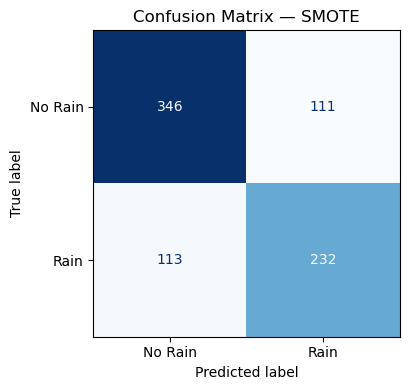

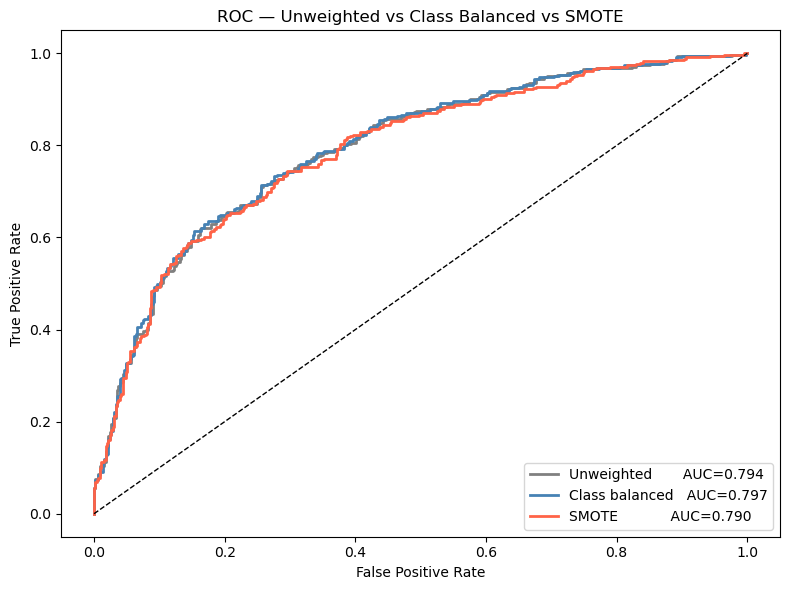

Model Comparison Summary
         Model  ROC-AUC  Rain Recall  Rain Precision
    Unweighted   0.7945       0.4754          0.7961
Class Balanced   0.7967       0.6841          0.6743
         SMOTE   0.7900       0.6725          0.6764


In [74]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import roc_curve, recall_score, precision_score

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_sm),
                       display_labels=['No Rain', 'Rain']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — SMOTE')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_19_smote_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# ROC: unweighted vs balanced vs SMOTE
fig, ax = plt.subplots(figsize=(8, 6))
for y_prob, label, colour, ls in [
    (y_proba,     f'Unweighted       AUC={roc_auc_score(y_test, y_proba):.3f}',     'grey',      '-'),
    (y_proba_bal, f'Class balanced   AUC={roc_auc_score(y_test, y_proba_bal):.3f}', 'steelblue', '-'),
    (y_proba_sm,  f'SMOTE            AUC={roc_auc_score(y_test, y_proba_sm):.3f}',  'tomato',    '-'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, lw=2, color=colour, linestyle=ls, label=label)
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC — Unweighted vs Class Balanced vs SMOTE')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_20_smote_roc_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary comparison table
summary = pd.DataFrame({
    'Model':          ['Unweighted', 'Class Balanced', 'SMOTE'],
    'ROC-AUC':        [
        round(roc_auc_score(y_test, y_proba),     4),
        round(roc_auc_score(y_test, y_proba_bal), 4),
        round(roc_auc_score(y_test, y_proba_sm),  4),
    ],
    'Rain Recall':    [
        round(recall_score(y_test, y_pred,     pos_label=1), 4),
        round(recall_score(y_test, y_pred_bal, pos_label=1), 4),
        round(recall_score(y_test, y_pred_sm,  pos_label=1), 4),
    ],
    'Rain Precision': [
        round(precision_score(y_test, y_pred,     pos_label=1, zero_division=0), 4),
        round(precision_score(y_test, y_pred_bal, pos_label=1, zero_division=0), 4),
        round(precision_score(y_test, y_pred_sm,  pos_label=1, zero_division=0), 4),
    ],
})
print('Model Comparison Summary')
print('=' * 50)
print(summary.to_string(index=False))


---
## ADASYN — Adaptive Synthetic Sampling

ADASYN is similar to SMOTE but focuses synthetic generation on harder-to-learn
minority instances (those surrounded by many majority-class neighbours).
Applied **after scaling, before PCA** — same pipeline order as SMOTE.

Pipeline: Scale (train only) → ADASYN (train only) → PCA (on resampled train) → LR


In [75]:
from imblearn.over_sampling import ADASYN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)
import numpy as np

# --- Scale (fit on original train only) ---
scaler_ad = StandardScaler()
X_train_ad_scaled = scaler_ad.fit_transform(X_train)
X_test_ad_scaled  = scaler_ad.transform(X_test)

print("Before ADASYN:")
print(f"  Rain: {y_train.sum()}  |  No Rain: {(y_train==0).sum()}")

# --- ADASYN (applied to scaled train only) ---
ad = ADASYN(random_state=42)
X_train_ad_res, y_train_ad_res = ad.fit_resample(X_train_ad_scaled, y_train)

print("After ADASYN:")
print(f"  Rain: {y_train_ad_res.sum()}  |  No Rain: {(y_train_ad_res==0).sum()}")
print(f"  Total training samples: {len(y_train_ad_res)}")

# --- PCA (fit on resampled train) ---
pca_ad = PCA()
pca_ad.fit(X_train_ad_res)
cum_ad = pca_ad.explained_variance_ratio_.cumsum()
n_95_ad = int((cum_ad < 0.95).sum()) + 1
print(f"PCA components for 95% variance: {n_95_ad}")

pca_ad_final = PCA(n_components=n_95_ad)
X_train_ad_pca = pca_ad_final.fit_transform(X_train_ad_res)
X_test_ad_pca  = pca_ad_final.transform(X_test_ad_scaled)

# --- Logistic Regression ---
lr_ad = LogisticRegression(max_iter=1000, random_state=42)
lr_ad.fit(X_train_ad_pca, y_train_ad_res)

y_pred_ad  = lr_ad.predict(X_test_ad_pca)
y_proba_ad = lr_ad.predict_proba(X_test_ad_pca)[:, 1]

print("Classification Report — ADASYN")
print("=" * 45)
print(classification_report(y_test, y_pred_ad, target_names=["No Rain", "Rain"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_ad):.4f}")


Before ADASYN:
  Rain: 1540  |  No Rain: 2833
After ADASYN:
  Rain: 2822  |  No Rain: 2833
  Total training samples: 5655
PCA components for 95% variance: 27
Classification Report — ADASYN
              precision    recall  f1-score   support

     No Rain       0.76      0.75      0.75       457
        Rain       0.67      0.68      0.68       345

    accuracy                           0.72       802
   macro avg       0.71      0.71      0.71       802
weighted avg       0.72      0.72      0.72       802

ROC-AUC: 0.7920


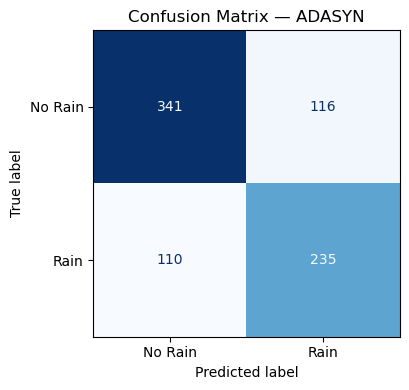

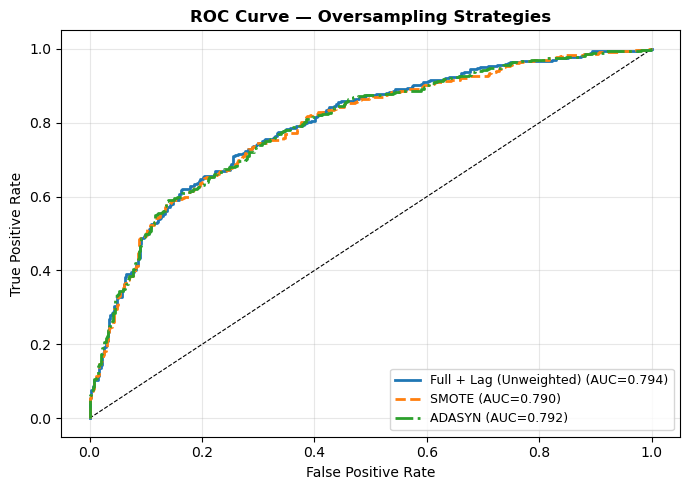

In [76]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, recall_score, precision_score

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_ad),
                       display_labels=["No Rain", "Rain"]).plot(
    ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — ADASYN")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/dc1_21_adasyn_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# ROC — ADASYN vs SMOTE vs Unweighted
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
for label, y_true, yp, ls in [
    ("Full + Lag (Unweighted)", y_test,  y_proba,    "-"),
    ("SMOTE",                   y_test,  y_proba_sm, "--"),
    ("ADASYN",                  y_test,  y_proba_ad, "-."),
]:
    fpr, tpr, _ = roc_curve(y_true, yp)
    auc = roc_auc_score(y_true, yp)
    ax.plot(fpr, tpr, ls=ls, lw=2, label=f"{label} (AUC={auc:.3f})")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Oversampling Strategies", fontweight="bold")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/dc1_22_adasyn_roc_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


---
## Overfitting Checks

**Train vs Test AUC gap** — a large gap (> 0.05) signals the model memorised training data.
Logistic Regression is low-variance by design, so gaps should be small.

**Learning curves** — plot training score and cross-validated score as the training set grows.
A healthy model has both curves converging; a persistent gap = overfitting.
We use *TimeSeriesSplit* (no shuffling) to respect the temporal order of the data.


                          Model  Train AUC  Test AUC     Gap Status
        Full + Lag (Unweighted)     0.7731    0.7945 -0.0214     OK
          Full + Lag (Balanced)     0.7736    0.7967 -0.0230     OK
No-Lag / No-Cyclic (Unweighted)     0.7427    0.7731 -0.0304     OK
  No-Lag / No-Cyclic (Balanced)     0.7431    0.7737 -0.0306     OK
     Pruned Features (Balanced)     0.7736    0.7958 -0.0222     OK
             SMOTE (Unweighted)     0.7724    0.7900 -0.0176     OK
            ADASYN (Unweighted)     0.7725    0.7920 -0.0195     OK


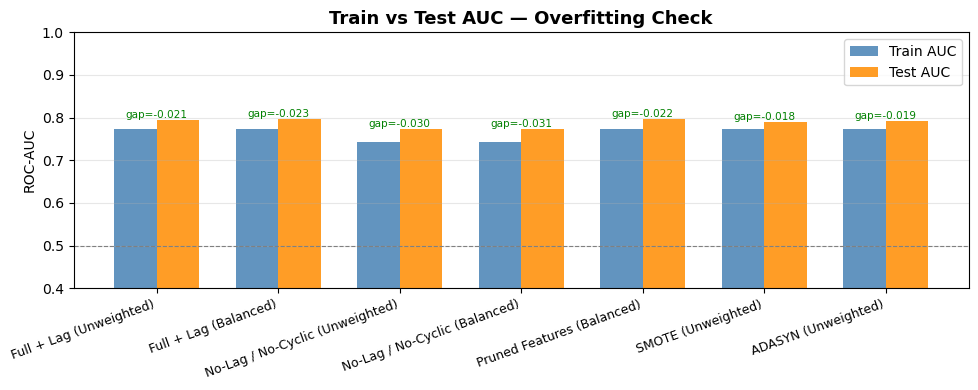

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# For SMOTE/ADASYN: evaluate train AUC on the original (non-synthetic) training data
X_train_sm_orig_pca = pca_sm_final.transform(X_train_sm_scaled)
X_train_ad_orig_pca = pca_ad_final.transform(X_train_ad_scaled)

specs = [
    ("Full + Lag (Unweighted)",        lr,      X_train_pca,         y_train,  X_test_pca,    y_test),
    ("Full + Lag (Balanced)",           lr_bal,  X_train_pca,         y_train,  X_test_pca,    y_test),
    ("No-Lag / No-Cyclic (Unweighted)", lr2,     X_train2_pca,        y_train2, X_test2_pca,   y_test2),
    ("No-Lag / No-Cyclic (Balanced)",   lr2_bal, X_train2_pca,        y_train2, X_test2_pca,   y_test2),
    ("Pruned Features (Balanced)",      lr_pr,   X_train_pr_pca,      y_train,  X_test_pr_pca, y_test),
    ("SMOTE (Unweighted)",              lr_sm,   X_train_sm_orig_pca, y_train,  X_test_sm_pca, y_test),
    ("ADASYN (Unweighted)",             lr_ad,   X_train_ad_orig_pca, y_train,  X_test_ad_pca, y_test),
]

rows = []
for name, model, X_tr, y_tr, X_te, y_te in specs:
    tr  = roc_auc_score(y_tr, model.predict_proba(X_tr)[:, 1])
    te  = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])
    gap = tr - te
    rows.append({"Model": name, "Train AUC": tr, "Test AUC": te,
                 "Gap": gap, "Status": "OVERFIT" if gap > 0.05 else "OK"})

gap_df = pd.DataFrame(rows)
print(gap_df.to_string(index=False, float_format="{:.4f}".format))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(gap_df))
ax.bar(x, gap_df["Train AUC"], 0.35, label="Train AUC",
       color="steelblue", alpha=0.85)
ax.bar([i + 0.35 for i in x], gap_df["Test AUC"], 0.35, label="Test AUC",
       color="darkorange", alpha=0.85)
ax.axhline(0.5, color="grey", lw=0.8, ls="--")
ax.set_xticks([i + 0.175 for i in x])
ax.set_xticklabels(gap_df["Model"], rotation=20, ha="right", fontsize=9)
ax.set_ylabel("ROC-AUC")
ax.set_ylim(0.4, 1.0)
ax.set_title("Train vs Test AUC — Overfitting Check", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

# Annotate gap on each pair
for i, row in gap_df.iterrows():
    ax.text(i + 0.175, max(row["Train AUC"], row["Test AUC"]) + 0.005,
            f"gap={row['Gap']:.3f}", ha="center", fontsize=7.5,
            color="red" if row["Status"] == "OVERFIT" else "green")

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/dc1_24_train_test_auc_gap.png", dpi=300, bbox_inches="tight")
plt.show()


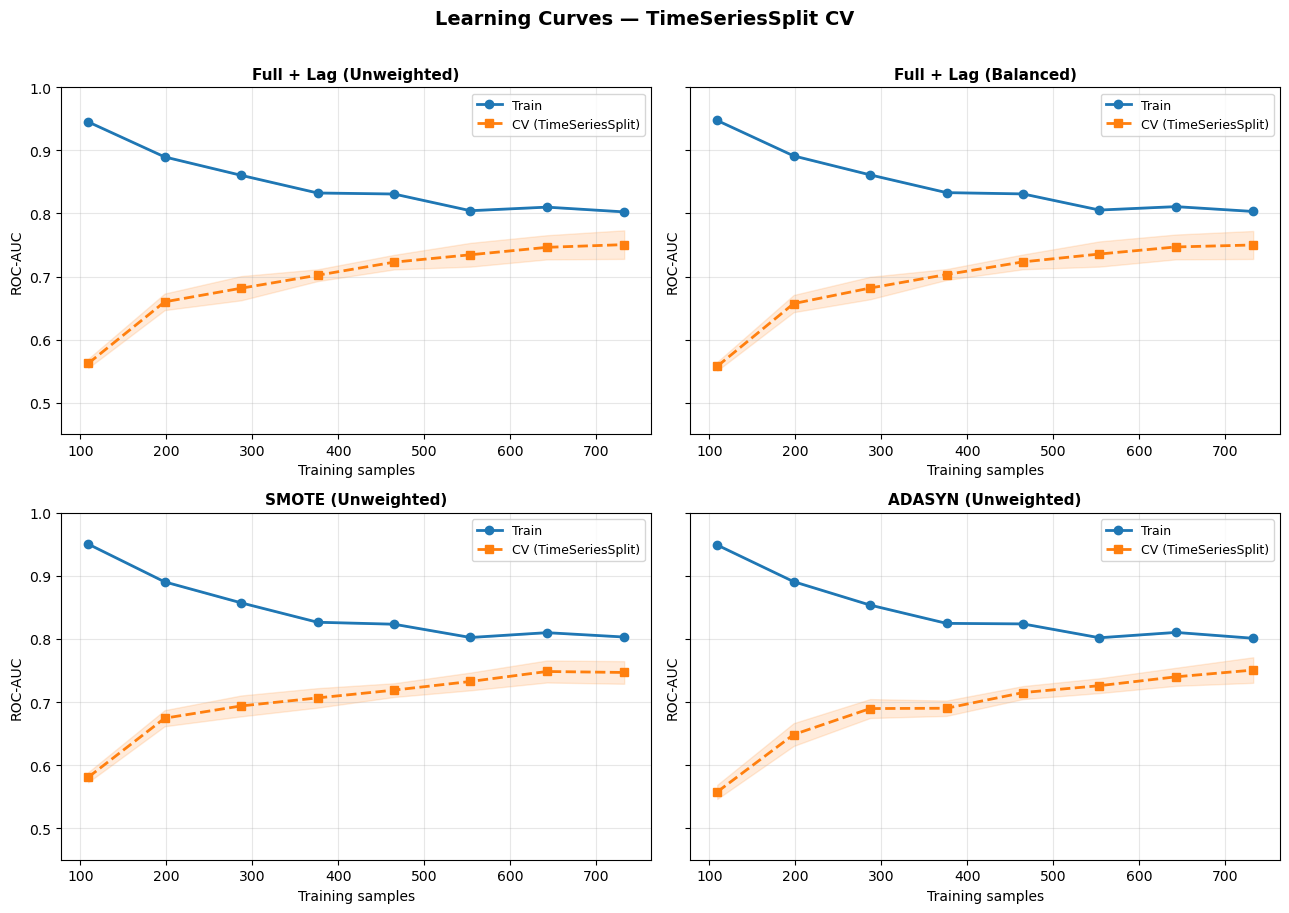

Interpretation:
  • Both curves close together → low overfitting
  • Train >> CV → overfitting
  • Both curves low and flat → underfitting


In [78]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import learning_curve, TimeSeriesSplit
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN

tscv = TimeSeriesSplit(n_splits=5)
train_sizes = np.linspace(0.15, 1.0, 8)

pipe_configs = [
    ("Full + Lag (Unweighted)",
     Pipeline([("sc", StandardScaler()),
               ("pca", PCA(n_components=0.95)),
               ("lr", LogisticRegression(max_iter=1000, random_state=42))]),
     X_train, y_train),
    ("Full + Lag (Balanced)",
     Pipeline([("sc", StandardScaler()),
               ("pca", PCA(n_components=0.95)),
               ("lr", LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"))]),
     X_train, y_train),
    ("SMOTE (Unweighted)",
     ImbPipeline([("sc", StandardScaler()),
                  ("sm", SMOTE(random_state=42)),
                  ("pca", PCA(n_components=0.95)),
                  ("lr", LogisticRegression(max_iter=1000, random_state=42))]),
     X_train, y_train),
    ("ADASYN (Unweighted)",
     ImbPipeline([("sc", StandardScaler()),
                  ("ad", ADASYN(random_state=42)),
                  ("pca", PCA(n_components=0.95)),
                  ("lr", LogisticRegression(max_iter=1000, random_state=42))]),
     X_train, y_train),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=True)
palette_tr = "#1f77b4"
palette_cv = "#ff7f0e"

for ax, (label, pipe, X, y) in zip(axes.flat, pipe_configs):
    sizes, tr_scores, cv_scores = learning_curve(
        pipe, X, y,
        train_sizes=train_sizes,
        cv=tscv,
        scoring="roc_auc",
        n_jobs=-1,
    )
    tr_mean = tr_scores.mean(axis=1)
    tr_std  = tr_scores.std(axis=1)
    cv_mean = cv_scores.mean(axis=1)
    cv_std  = cv_scores.std(axis=1)

    ax.plot(sizes, tr_mean, "o-", color=palette_tr, lw=2, label="Train")
    ax.fill_between(sizes, tr_mean - tr_std, tr_mean + tr_std,
                    alpha=0.15, color=palette_tr)
    ax.plot(sizes, cv_mean, "s--", color=palette_cv, lw=2, label="CV (TimeSeriesSplit)")
    ax.fill_between(sizes, cv_mean - cv_std, cv_mean + cv_std,
                    alpha=0.15, color=palette_cv)
    ax.set_title(label.replace(" ", " "), fontsize=11, fontweight="bold")
    ax.set_xlabel("Training samples")
    ax.set_ylabel("ROC-AUC")
    ax.set_ylim(0.45, 1.0)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("Learning Curves — TimeSeriesSplit CV",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/dc1_25_learning_curves.png", dpi=300, bbox_inches="tight")
plt.show()

print("Interpretation:")
print("  • Both curves close together → low overfitting")
print("  • Train >> CV → overfitting")
print("  • Both curves low and flat → underfitting")


                                                          Model  TN  FP  FN  TP   Acc  Rain Recall  Rain Precision
                 F u l l   +   L a g   ( U n w e i g h t e d )  415  42 181 164 0.722        0.475           0.796
                     F u l l   +   L a g   ( B a l a n c e d )  343 114 109 236 0.722        0.684           0.674
 N o - L a g   /   N o - C y c l i c   ( U n w e i g h t e d )  429  28 210 135 0.703        0.391           0.828
     N o - L a g   /   N o - C y c l i c   ( B a l a n c e d )  362  95 120 225 0.732        0.652           0.703
           P r u n e d   F e a t u r e s   ( B a l a n c e d )  343 114 112 233 0.718        0.675           0.671
                           S M O T E   ( U n w e i g h t e d )  346 111 113 232 0.721        0.672           0.676
                         A D A S Y N   ( U n w e i g h t e d )  341 116 110 235 0.718        0.681           0.670


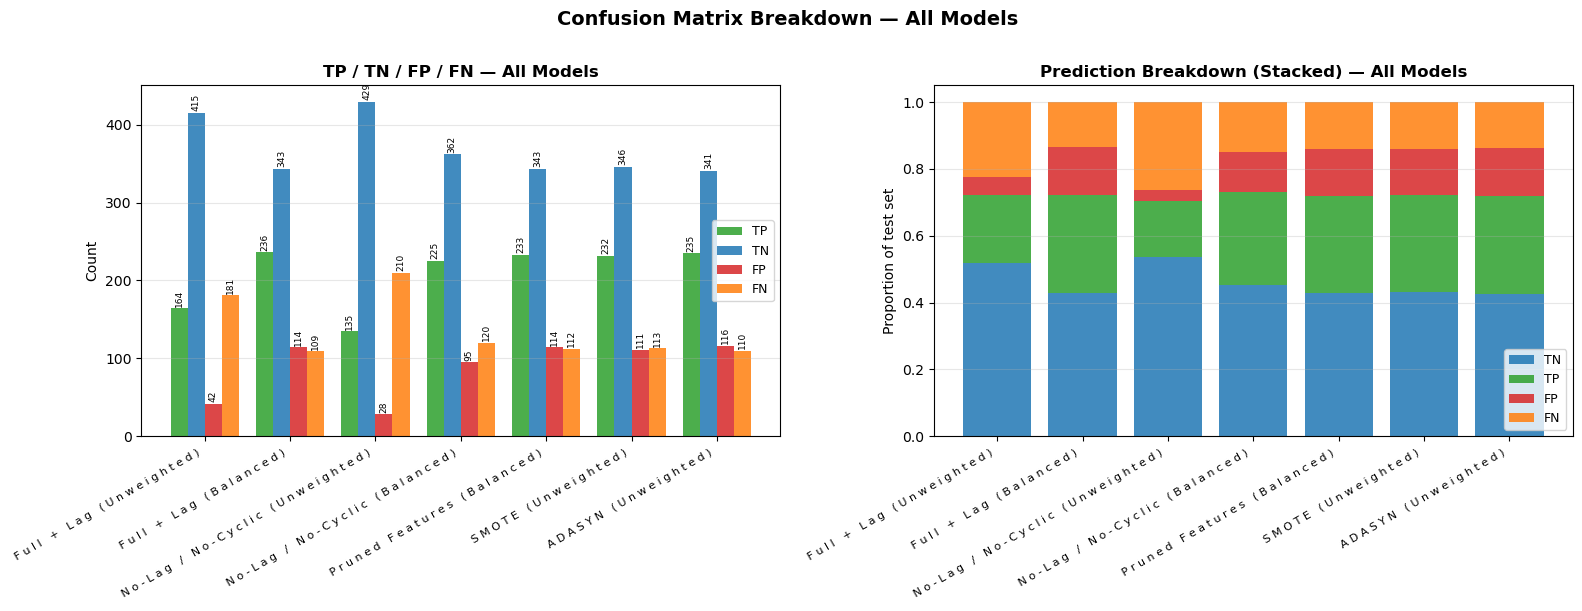

In [79]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

cm_specs = [
    ("Full + Lag (Unweighted)",        y_test,  y_pred),
    ("Full + Lag (Balanced)",          y_test,  y_pred_bal),
    ("No-Lag / No-Cyclic (Unweighted)", y_test2, y_pred2),
    ("No-Lag / No-Cyclic (Balanced)",   y_test2, y_pred2_bal),
    ("Pruned Features (Balanced)",      y_test,  y_pred_pr),
    ("SMOTE (Unweighted)",             y_test,  y_pred_sm),
    ("ADASYN (Unweighted)",            y_test,  y_pred_ad),
]

rows = []
for label, y_true, y_pred_m in cm_specs:
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_m).ravel()
    total = tn + fp + fn + tp
    rows.append({
        "Model":   label.replace("", " "),
        "TN":      tn, "FP": fp, "FN": fn, "TP": tp,
        "Total":   total,
        "Acc":     (tp + tn) / total,
        "Rain Recall":    tp / (tp + fn),
        "Rain Precision": tp / (tp + fp) if (tp + fp) > 0 else 0,
    })

cm_df = pd.DataFrame(rows)
print(cm_df[["Model", "TN", "FP", "FN", "TP", "Acc", "Rain Recall", "Rain Precision"]]
      .to_string(index=False, float_format="{:.3f}".format))

# ── Grouped bar chart ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
labels  = [r["Model"] for r in rows]
x       = np.arange(len(labels))
bar_w   = 0.2

# Panel 1: Raw counts (TP, TN, FP, FN)
ax = axes[0]
offsets = [-1.5, -0.5, 0.5, 1.5]
colors  = ["#2ca02c", "#1f77b4", "#d62728", "#ff7f0e"]
keys    = ["TP", "TN", "FP", "FN"]
for off, color, key in zip(offsets, colors, keys):
    vals = cm_df[key].values
    bars = ax.bar(x + off * bar_w, vals, bar_w, label=key, color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                str(v), ha="center", va="bottom", fontsize=6.5, rotation=90)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Count")
ax.set_title("TP / TN / FP / FN — All Models", fontweight="bold", fontsize=12)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

# Panel 2: Stacked proportions
ax2 = axes[1]
totals = cm_df["Total"].values
tp_r = cm_df["TP"].values / totals
tn_r = cm_df["TN"].values / totals
fp_r = cm_df["FP"].values / totals
fn_r = cm_df["FN"].values / totals
ax2.bar(x, tn_r, label="TN", color="#1f77b4", alpha=0.85)
ax2.bar(x, tp_r, bottom=tn_r, label="TP", color="#2ca02c", alpha=0.85)
ax2.bar(x, fp_r, bottom=tn_r + tp_r, label="FP", color="#d62728", alpha=0.85)
ax2.bar(x, fn_r, bottom=tn_r + tp_r + fp_r, label="FN", color="#ff7f0e", alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
ax2.set_ylabel("Proportion of test set")
ax2.set_title("Prediction Breakdown (Stacked) — All Models", fontweight="bold", fontsize=12)
ax2.legend(fontsize=9, loc="lower right")
ax2.grid(axis="y", alpha=0.3)

plt.suptitle("Confusion Matrix Breakdown — All Models",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/dc1_26_confusion_breakdown_all_models.png",
            dpi=300, bbox_inches="tight")
plt.show()


---
## Decision Threshold Tuning

All models above use the default 0.5 probability threshold. Lowering it means
predicting Rain whenever P(Rain) > threshold — catching more rain days at the
cost of more false alarms.

**F2-score** weights recall twice as heavily as precision, making it the right
metric when missing rain (false negative) is worse than a false alarm (false positive).
We scan thresholds 0.05–0.70 and pick the one that maximises F2 for each model.


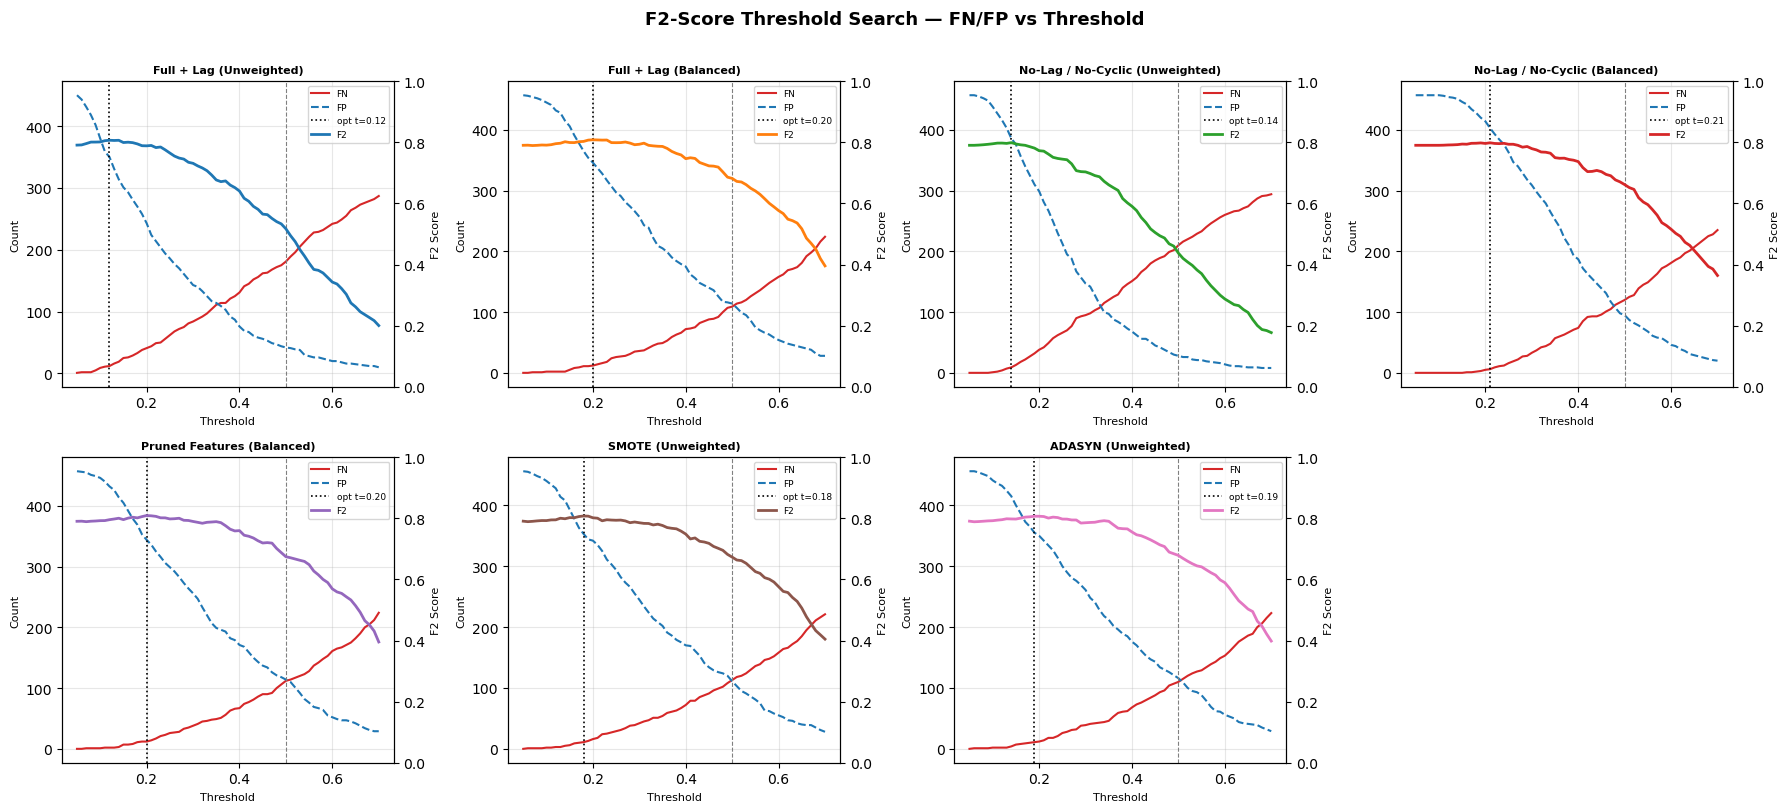

In [80]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import fbeta_score, confusion_matrix

thresholds = np.arange(0.05, 0.71, 0.01)

model_probas = [
    ("Full + Lag (Unweighted)",        y_test,  y_proba),
    ("Full + Lag (Balanced)",           y_test,  y_proba_bal),
    ("No-Lag / No-Cyclic (Unweighted)", y_test2, y_proba2),
    ("No-Lag / No-Cyclic (Balanced)",   y_test2, y_proba2_bal),
    ("Pruned Features (Balanced)",       y_test,  y_proba_pr),
    ("SMOTE (Unweighted)",               y_test,  y_proba_sm),
    ("ADASYN (Unweighted)",              y_test,  y_proba_ad),
]

palette = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd","#8c564b","#e377c2"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=False)
axes = axes.flat
summary_rows = []

for ax, (label, y_true, y_prob), color in zip(axes, model_probas, palette):
    f2s, fns, fps = [], [], []
    for t in thresholds:
        y_hat = (y_prob >= t).astype(int)
        f2s.append(fbeta_score(y_true, y_hat, beta=2, zero_division=0))
        tn, fp, fn, tp = confusion_matrix(y_true, y_hat).ravel()
        fns.append(fn); fps.append(fp)

    best_t   = thresholds[np.argmax(f2s)]
    best_f2  = max(f2s)
    y_best   = (y_prob >= best_t).astype(int)
    tn_b, fp_b, fn_b, tp_b = confusion_matrix(y_true, y_best).ravel()
    tn_d, fp_d, fn_d, tp_d = confusion_matrix(y_true, (y_prob >= 0.5).astype(int)).ravel()

    ax2 = ax.twinx()
    ax.plot(thresholds, fns, color="#d62728", lw=1.5, label="FN")
    ax.plot(thresholds, fps, color="#1f77b4", lw=1.5, ls="--", label="FP")
    ax2.plot(thresholds, f2s, color=color, lw=2, label="F2")
    ax.axvline(best_t, color="black", lw=1.2, ls=":", label=f"opt t={best_t:.2f}")
    ax.axvline(0.5,    color="grey",  lw=0.8, ls="--")
    ax.set_title(label, fontsize=8, fontweight="bold")
    ax.set_xlabel("Threshold", fontsize=8)
    ax.set_ylabel("Count", fontsize=8)
    ax2.set_ylabel("F2 Score", fontsize=8)
    ax2.set_ylim(0, 1)
    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labs1 + labs2, fontsize=6.5, loc="upper right")
    ax.grid(alpha=0.3)

    summary_rows.append({
        "Model":             label,
        "Default FN (t=0.5)": fn_d,
        "Optimal Threshold":  round(best_t, 2),
        "Optimal FN":        fn_b,
        "FN Reduction":      fn_d - fn_b,
        "Optimal FP":        fp_b,
        "Default FP (t=0.5)": fp_d,
        "Best F2":           round(best_f2, 4),
    })

# Hide last (unused) subplot
axes[-1].set_visible(False)

plt.suptitle("F2-Score Threshold Search — FN/FP vs Threshold",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/dc1_27_threshold_sweep.png", dpi=300, bbox_inches="tight")
plt.show()


THRESHOLD TUNING SUMMARY — Default (0.5) vs F2-Optimal
                          Model  Default FN (t=0.5)  Optimal Threshold  Optimal FN  FN Reduction  Optimal FP  Default FP (t=0.5)  Best F2
        Full + Lag (Unweighted)                 181               0.12          12           169         350                  42   0.8071
          Full + Lag (Balanced)                 109               0.20          12            97         346                 114   0.8086
No-Lag / No-Cyclic (Unweighted)                 210               0.14           9           201         386                  28   0.7992
  No-Lag / No-Cyclic (Balanced)                 120               0.21           6           114         403                  95   0.7988
     Pruned Features (Balanced)                 112               0.20          12           100         344                 114   0.8094
             SMOTE (Unweighted)                 113               0.18          11           102         353         

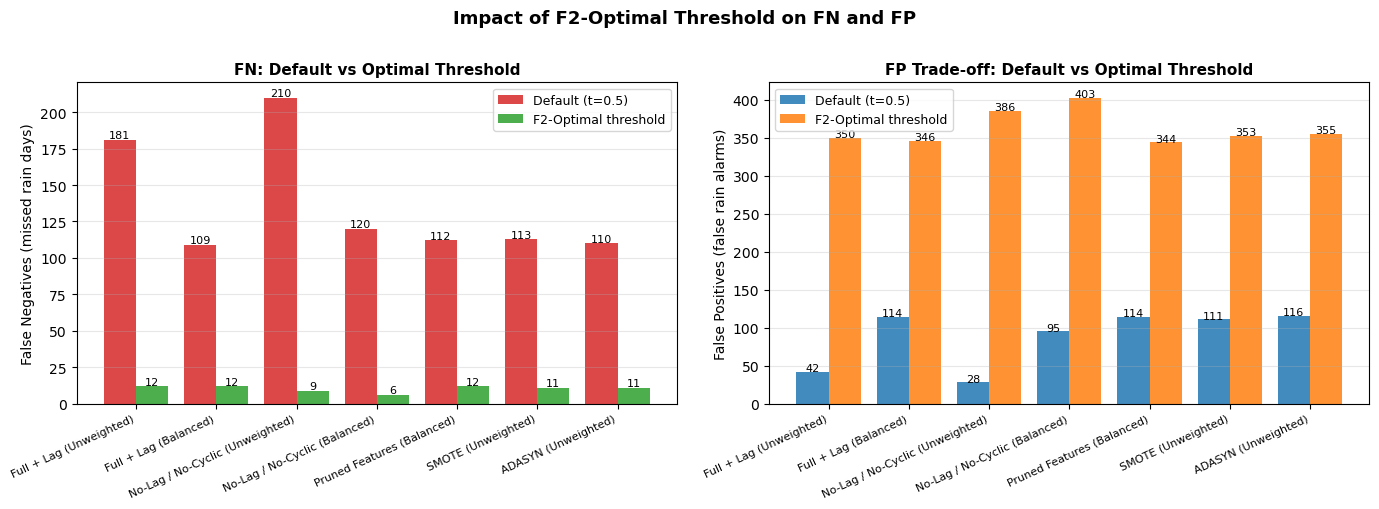

Optimal thresholds range: 0.12 – 0.21
Avg FN reduction: 126.0 fewer missed rain days per model


In [81]:
summary_df = pd.DataFrame(summary_rows)
print("=" * 90)
print("THRESHOLD TUNING SUMMARY — Default (0.5) vs F2-Optimal")
print("=" * 90)
print(summary_df.to_string(index=False))

# Side-by-side FN comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: FN before/after
ax = axes[0]
x = np.arange(len(summary_df))
ax.bar(x - 0.2, summary_df["Default FN (t=0.5)"], 0.4,
       label="Default (t=0.5)", color="#d62728", alpha=0.85)
ax.bar(x + 0.2, summary_df["Optimal FN"], 0.4,
       label="F2-Optimal threshold", color="#2ca02c", alpha=0.85)
for i, row in summary_df.iterrows():
    ax.text(i - 0.2, row["Default FN (t=0.5)"] + 1, str(int(row["Default FN (t=0.5)"])),
            ha="center", fontsize=8)
    ax.text(i + 0.2, row["Optimal FN"] + 1, str(int(row["Optimal FN"])),
            ha="center", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(summary_df["Model"], rotation=25, ha="right", fontsize=8)
ax.set_ylabel("False Negatives (missed rain days)")
ax.set_title("FN: Default vs Optimal Threshold", fontweight="bold", fontsize=11)
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)

# Panel 2: FP before/after (cost of lowering threshold)
ax2 = axes[1]
ax2.bar(x - 0.2, summary_df["Default FP (t=0.5)"], 0.4,
        label="Default (t=0.5)", color="#1f77b4", alpha=0.85)
ax2.bar(x + 0.2, summary_df["Optimal FP"], 0.4,
        label="F2-Optimal threshold", color="#ff7f0e", alpha=0.85)
for i, row in summary_df.iterrows():
    ax2.text(i - 0.2, row["Default FP (t=0.5)"] + 1, str(int(row["Default FP (t=0.5)"])),
             ha="center", fontsize=8)
    ax2.text(i + 0.2, row["Optimal FP"] + 1, str(int(row["Optimal FP"])),
             ha="center", fontsize=8)
ax2.set_xticks(x)
ax2.set_xticklabels(summary_df["Model"], rotation=25, ha="right", fontsize=8)
ax2.set_ylabel("False Positives (false rain alarms)")
ax2.set_title("FP Trade-off: Default vs Optimal Threshold", fontweight="bold", fontsize=11)
ax2.legend(fontsize=9); ax2.grid(axis="y", alpha=0.3)

plt.suptitle("Impact of F2-Optimal Threshold on FN and FP",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/dc1_28_threshold_fn_fp_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Optimal thresholds range: {summary_df['Optimal Threshold'].min()} – {summary_df['Optimal Threshold'].max()}")
print(f"Avg FN reduction: {summary_df['FN Reduction'].mean():.1f} fewer missed rain days per model")


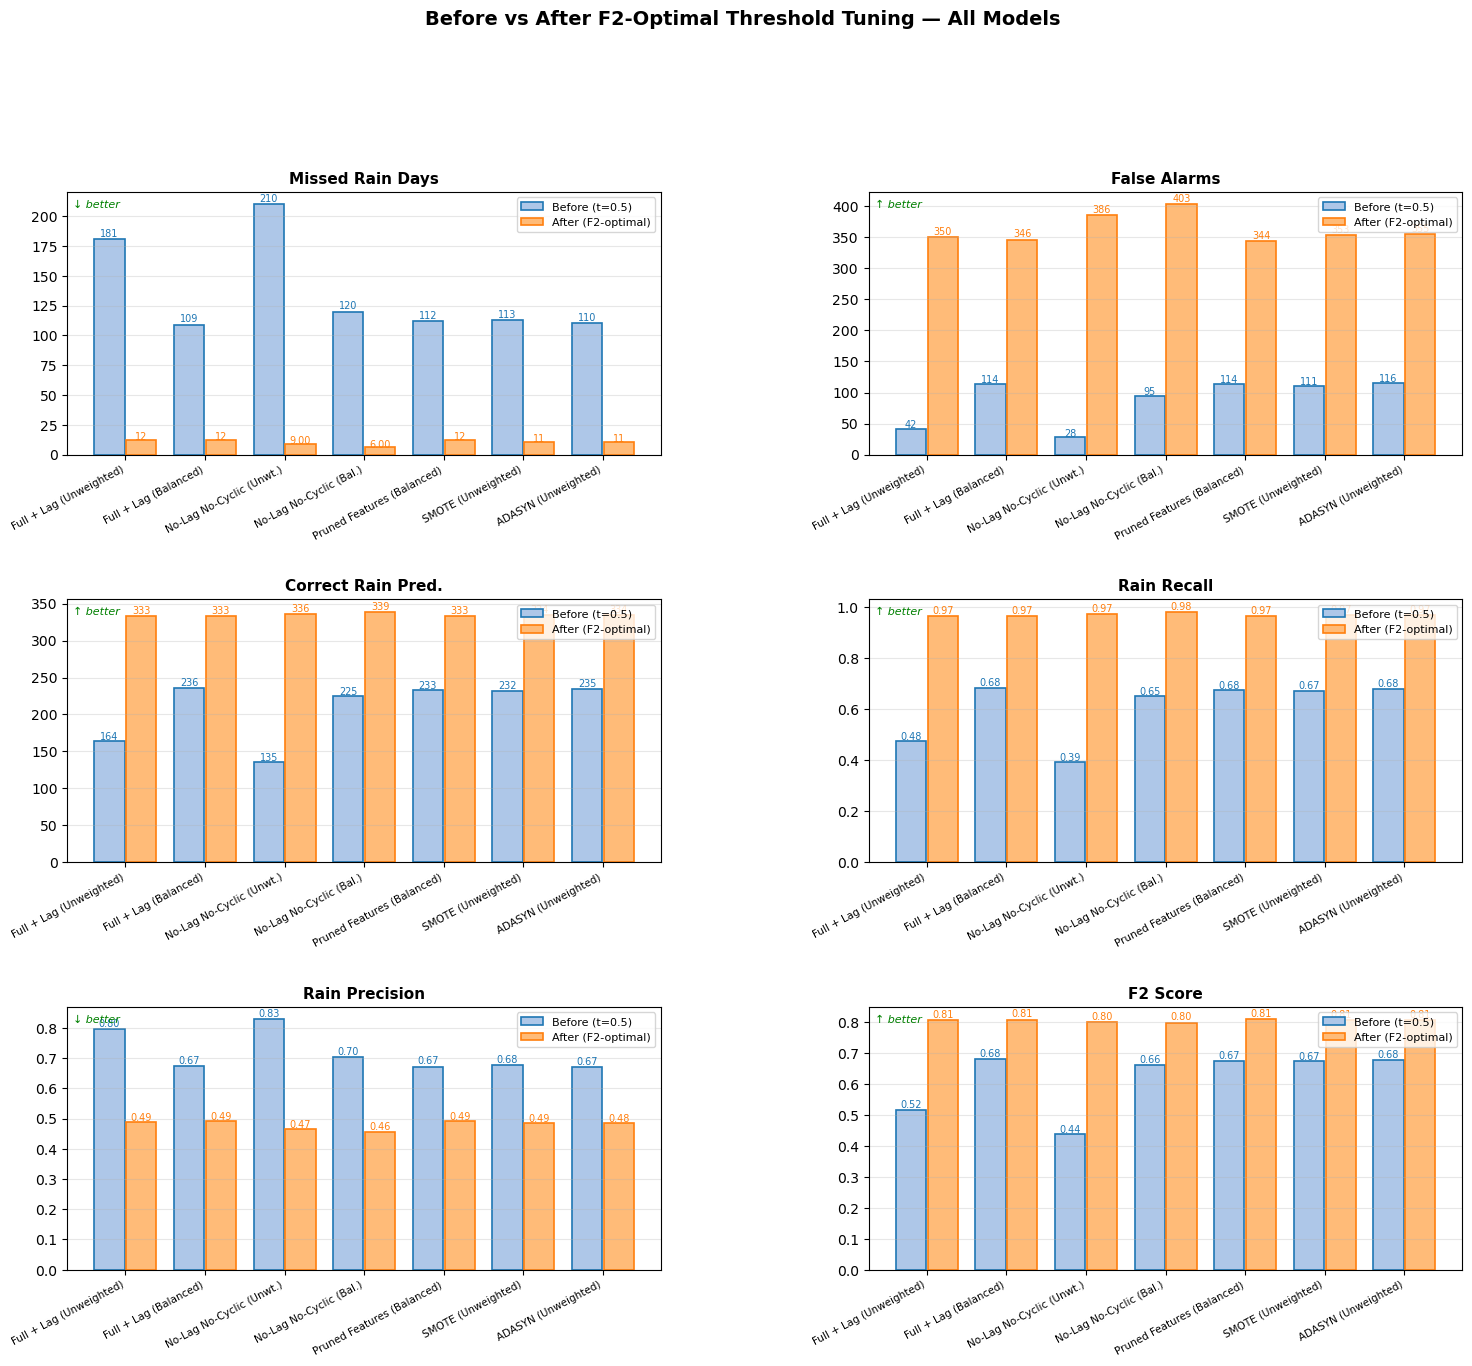

BEFORE vs AFTER THRESHOLD TUNING
                     Model  Opt t  FN (before)  FN (after)  FP (before)  FP (after)  Recall (before)  Recall (after)  F2 (before)  F2 (after)
   Full + Lag (Unweighted)  0.120          181          12           42         350            0.475           0.965        0.517       0.807
     Full + Lag (Balanced)  0.200          109          12          114         346            0.684           0.965        0.682       0.809
  No-Lag No-Cyclic (Unwt.)  0.140          210           9           28         386            0.391           0.974        0.437       0.799
   No-Lag No-Cyclic (Bal.)  0.210          120           6           95         403            0.652           0.983        0.662       0.799
Pruned Features (Balanced)  0.200          112          12          114         344            0.675           0.965        0.675       0.809
        SMOTE (Unweighted)  0.180          113          11          111         353            0.672           0.96

In [82]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from sklearn.metrics import (
    confusion_matrix, fbeta_score, f1_score,
    recall_score, precision_score, roc_auc_score
)

model_probas = [
    ("Full + Lag (Unweighted)",        y_test,  y_proba),
    ("Full + Lag (Balanced)",          y_test,  y_proba_bal),
    ("No-Lag No-Cyclic (Unwt.)",      y_test2, y_proba2),
    ("No-Lag No-Cyclic (Bal.)",       y_test2, y_proba2_bal),
    ("Pruned Features (Balanced)",     y_test,  y_proba_pr),
    ("SMOTE (Unweighted)",            y_test,  y_proba_sm),
    ("ADASYN (Unweighted)",           y_test,  y_proba_ad),
]
thresholds = np.arange(0.05, 0.71, 0.01)

def metrics_at(y_true, y_prob, t):
    y_hat = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_hat).ravel()
    rec  = recall_score(y_true, y_hat, zero_division=0)
    pre  = precision_score(y_true, y_hat, zero_division=0)
    f1   = f1_score(y_true, y_hat, zero_division=0)
    f2   = fbeta_score(y_true, y_hat, beta=2, zero_division=0)
    return dict(TN=tn, FP=fp, FN=fn, TP=tp,
                Recall=rec, Precision=pre, F1=f1, F2=f2)

rows = []
for label, y_true, y_prob in model_probas:
    f2s = [fbeta_score(y_true, (y_prob >= t).astype(int), beta=2, zero_division=0)
           for t in thresholds]
    opt_t = thresholds[np.argmax(f2s)]
    before = metrics_at(y_true, y_prob, 0.5)
    after  = metrics_at(y_true, y_prob, opt_t)
    rows.append({"Model": label,
                 "Opt t": round(opt_t, 2), **{
                     f"{k} (before)": before[k] for k in before},
                 **{f"{k} (after)": after[k]  for k in after}})

df = pd.DataFrame(rows)

# ── Figure layout ────────────────────────────────────────────────────────────
short_labels = [r["Model"] for r in rows]
x = np.arange(len(short_labels))
palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
           "#9467bd", "#8c564b", "#e377c2"]

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 2, hspace=0.55, wspace=0.35)

metric_panels = [
    ("FN",        "Missed Rain Days",   True,  fig.add_subplot(gs[0, 0])),
    ("FP",        "False Alarms",        False, fig.add_subplot(gs[0, 1])),
    ("TP",        "Correct Rain Pred.", False, fig.add_subplot(gs[1, 0])),
    ("Recall",    "Rain Recall",         False, fig.add_subplot(gs[1, 1])),
    ("Precision", "Rain Precision",      True,  fig.add_subplot(gs[2, 0])),
    ("F2",        "F2 Score",            False, fig.add_subplot(gs[2, 1])),
]

for metric, title, lower_is_better, ax in metric_panels:
    b_vals = df[f"{metric} (before)"].values.astype(float)
    a_vals = df[f"{metric} (after)"].values.astype(float)
    bars_b = ax.bar(x - 0.2, b_vals, 0.38,
                    label="Before (t=0.5)", color="#aec7e8", edgecolor="#1f77b4", lw=1.2)
    bars_a = ax.bar(x + 0.2, a_vals, 0.38,
                    label="After (F2-optimal)", color="#ffbb78", edgecolor="#ff7f0e", lw=1.2)
    for bar, v in zip(bars_b, b_vals):
        fmt = f"{v:.2f}" if isinstance(v, float) and v < 10 else str(int(v))
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(b_vals)*0.01,
                fmt, ha="center", fontsize=7, color="#1f77b4")
    for bar, v in zip(bars_a, a_vals):
        fmt = f"{v:.2f}" if isinstance(v, float) and v < 10 else str(int(v))
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(a_vals)*0.01,
                fmt, ha="center", fontsize=7, color="#ff7f0e")
    ax.set_xticks(x)
    ax.set_xticklabels(short_labels, rotation=28, ha="right", fontsize=7.5)
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    # Arrow annotations showing direction of change
    arrow = "↓ better" if lower_is_better else "↑ better"
    ax.text(0.01, 0.97, arrow, transform=ax.transAxes,
            fontsize=8, va="top", color="green", style="italic")

plt.suptitle("Before vs After F2-Optimal Threshold Tuning — All Models",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig(f"{PLOTS_DIR}/dc1_29_before_after_threshold.png", dpi=300, bbox_inches="tight")
plt.show()

# ── Clean summary table ───────────────────────────────────────────────────────
print("" + "="*95)
print("BEFORE vs AFTER THRESHOLD TUNING")
print("="*95)
cols = ["Model", "Opt t",
        "FN (before)", "FN (after)",
        "FP (before)", "FP (after)",
        "Recall (before)", "Recall (after)",
        "F2 (before)",    "F2 (after)"]
print(df[cols].to_string(index=False, float_format="{:.3f}".format))


C:\Users\Zenbook\AppData\Local\Temp\ipykernel_22836\2193322999.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


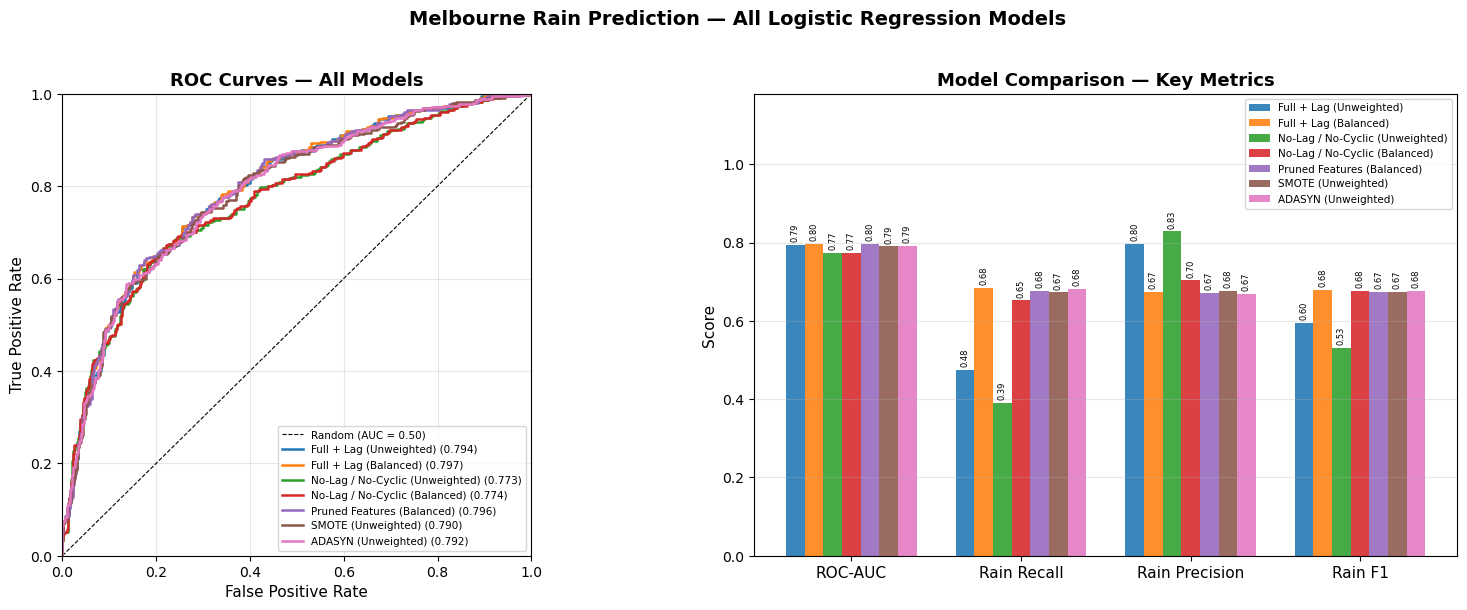

ALL MODEL SUMMARY
                          Model  ROC-AUC  Rain Recall  Rain Precision  Rain F1
        Full + Lag (Unweighted)   0.7945       0.4754          0.7961   0.5953
          Full + Lag (Balanced)   0.7967       0.6841          0.6743   0.6791
No-Lag / No-Cyclic (Unweighted)   0.7731       0.3913          0.8282   0.5315
  No-Lag / No-Cyclic (Balanced)   0.7737       0.6522          0.7031   0.6767
     Pruned Features (Balanced)   0.7958       0.6754          0.6715   0.6734
             SMOTE (Unweighted)   0.7900       0.6725          0.6764   0.6744
            ADASYN (Unweighted)   0.7920       0.6812          0.6695   0.6753


In [83]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, roc_auc_score, recall_score, precision_score

# ── Model registry ──────────────────────────────────────────────────────────────
models = [
    {"label": "Full + Lag (Unweighted)",       "y_true": y_test,  "y_proba": y_proba,     "y_pred": y_pred},
    {"label": "Full + Lag (Balanced)",          "y_true": y_test,  "y_proba": y_proba_bal,  "y_pred": y_pred_bal},
    {"label": "No-Lag / No-Cyclic (Unweighted)","y_true": y_test2, "y_proba": y_proba2,    "y_pred": y_pred2},
    {"label": "No-Lag / No-Cyclic (Balanced)",  "y_true": y_test2, "y_proba": y_proba2_bal,"y_pred": y_pred2_bal},
    {"label": "Pruned Features (Balanced)",     "y_true": y_test,  "y_proba": y_proba_pr,   "y_pred": y_pred_pr},
    {"label": "SMOTE (Unweighted)",             "y_true": y_test,  "y_proba": y_proba_sm,   "y_pred": y_pred_sm},
    {"label": "ADASYN (Unweighted)",            "y_true": y_test,  "y_proba": y_proba_ad,   "y_pred": y_pred_ad},
]

palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2"]

# ── Compute metrics ─────────────────────────────────────────────────────────────
metrics = []
for m in models:
    auc = roc_auc_score(m["y_true"], m["y_proba"])
    rec = recall_score(m["y_true"], m["y_pred"])
    pre = precision_score(m["y_true"], m["y_pred"])
    f1  = 2 * pre * rec / (pre + rec) if (pre + rec) > 0 else 0
    metrics.append({"Model": m["label"], "ROC-AUC": auc,
                    "Rain Recall": rec, "Rain Precision": pre, "Rain F1": f1})
metrics_df = pd.DataFrame(metrics)

# ── Layout: ROC curves (left) + metric bars (right) ─────────────────────────────
fig = plt.figure(figsize=(18, 6))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 1.5], wspace=0.38)

# — ROC curves —
ax_roc = fig.add_subplot(gs[0])
ax_roc.plot([0, 1], [0, 1], "k--", lw=0.8, label="Random (AUC = 0.50)")
for i, m in enumerate(models):
    fpr, tpr, _ = roc_curve(m["y_true"], m["y_proba"])
    auc = metrics[i]["ROC-AUC"]
    ax_roc.plot(fpr, tpr, color=palette[i], lw=1.8,
                label=f"{m['label']} ({auc:.3f})")
ax_roc.set_xlabel("False Positive Rate", fontsize=11)
ax_roc.set_ylabel("True Positive Rate", fontsize=11)
ax_roc.set_title("ROC Curves — All Models", fontsize=13, fontweight="bold")
ax_roc.legend(fontsize=7.5, loc="lower right")
ax_roc.set_xlim(0, 1); ax_roc.set_ylim(0, 1)
ax_roc.grid(True, alpha=0.3)

# — Grouped bar chart —
ax_bar = fig.add_subplot(gs[1])
metric_cols = ["ROC-AUC", "Rain Recall", "Rain Precision", "Rain F1"]
x = np.arange(len(metric_cols))
n = len(models)
bar_w = 0.11
offsets = np.linspace(-(n-1)/2, (n-1)/2, n) * bar_w
for i, row in metrics_df.iterrows():
    vals = [row[c] for c in metric_cols]
    bars = ax_bar.bar(x + offsets[i], vals, bar_w,
                      label=row["Model"], color=palette[i], alpha=0.88)
    for bar, v in zip(bars, vals):
        ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                    f"{v:.2f}", ha="center", va="bottom", fontsize=6, rotation=90)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(metric_cols, fontsize=11)
ax_bar.set_ylabel("Score", fontsize=11)
ax_bar.set_title("Model Comparison — Key Metrics", fontsize=13, fontweight="bold")
ax_bar.set_ylim(0, 1.18)
ax_bar.legend(fontsize=7.5, loc="upper right", ncol=1)
ax_bar.grid(axis="y", alpha=0.3)

plt.suptitle("Melbourne Rain Prediction — All Logistic Regression Models",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/dc1_23_all_models_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# ── Summary table ───────────────────────────────────────────────────────────────
print("" + "="*80)
print("ALL MODEL SUMMARY")
print("="*80)
print(metrics_df.to_string(index=False, float_format="{:.4f}".format))


---
## New Feature Engineering + Model Re-run

Five meteorologically motivated features added to `daily_df`:

| Feature | Formula | Why it helps |
|---|---|---|
| `mslp_tendency` | today − yesterday MSLP | Falling pressure = incoming front / rain |
| `dewpt_depression` | temp_mean − dewpt_mean | Near 0 → near saturation → high rain chance |
| `rainfall_7d_roll` | 7-day rolling mean rainfall | Captures wet/dry spells |
| `rain_streak` | consecutive wet(+) / dry(−) days | Persistence of current weather state |
| `temp_anomaly` | temp_mean − 30-day rolling mean | Anomalous warmth/cold vs seasonal baseline |

All models below use the **full feature set** (existing + new features) and a fresh
train/test split. Variable names use `_nf` suffix to avoid overwriting previous results.


In [84]:
import numpy as np

# 1. Pressure tendency (today minus yesterday)
daily_df["mslp_tendency"] = daily_df["mslp_mean"] - daily_df["mslp_mean"].shift(1)

# 2. Dew point depression (how far air is from saturation)
daily_df["dewpt_depression"] = daily_df["temp_mean"] - daily_df["dewpt_mean"]

# 3. 7-day rolling mean rainfall (wet/dry spell magnitude)
daily_df["rainfall_7d_roll"] = daily_df["rainfall_total"].rolling(7, min_periods=4).mean()

# 4. Consecutive wet(+) / dry(-) day streak
rain_bin = (daily_df["rainfall_total"] > 0.2).astype(int)
groups   = (rain_bin != rain_bin.shift()).cumsum()
streak   = rain_bin.groupby(groups).cumcount() + 1
daily_df["rain_streak"] = np.where(rain_bin == 1, streak, -streak)

# 5. Temperature anomaly vs 30-day rolling mean
daily_df["temp_anomaly"] = (
    daily_df["temp_mean"] - daily_df["temp_mean"].rolling(30, min_periods=15).mean()
)

# Drop any NaNs introduced by rolling/shift on cleaned df
daily_df = daily_df.dropna()

new_feats = ["mslp_tendency", "dewpt_depression", "rainfall_7d_roll",
             "rain_streak", "temp_anomaly"]
print(f"Added {len(new_feats)} new features: {new_feats}")
print(f"daily_df shape after new features: {daily_df.shape}")
print(f"Rain rate: {daily_df['rain_tomorrow'].mean()*100:.1f}%")
daily_df[new_feats].describe().round(3)


Added 5 new features: ['mslp_tendency', 'dewpt_depression', 'rainfall_7d_roll', 'rain_streak', 'temp_anomaly']
daily_df shape after new features: (5161, 52)
Rain rate: 36.4%


,mslp_tendency,dewpt_depression,rainfall_7d_roll,rain_streak,temp_anomaly
count,5161.000,5161.000,5161.000,5161.000,5161.000
mean,0.002,6.699,2.014,-1.714,0.001
std,5.097,3.150,2.647,4.294,2.912
min,-17.434,-0.022,0.000,-28.000,-8.399
25%,-3.401,4.578,0.343,-4.000,-1.963
50%,-0.222,6.292,1.114,-1.000,-0.433
75%,3.305,8.215,2.629,1.000,1.552
max,20.492,24.054,21.943,14.000,14.597


In [85]:
split_date = "2023-01-01"
train_nf = daily_df[daily_df.index < split_date]
test_nf  = daily_df[daily_df.index >= split_date]

X_train_nf = train_nf.drop(columns=["rain_tomorrow"])
y_train_nf = train_nf["rain_tomorrow"]
X_test_nf  = test_nf.drop(columns=["rain_tomorrow"])
y_test_nf  = test_nf["rain_tomorrow"]

print(f"Train: {len(X_train_nf)} days | Test: {len(X_test_nf)} days")
print(f"Features: {X_train_nf.shape[1]}")
print(f"Train rain rate: {y_train_nf.mean()*100:.1f}%  | Test rain rate: {y_test_nf.mean()*100:.1f}%")


Train: 4359 days | Test: 802 days
Features: 51
Train rain rate: 35.2%  | Test rain rate: 43.0%


### PCA

In [86]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler_nf = StandardScaler()
X_train_nf_scaled = scaler_nf.fit_transform(X_train_nf)
X_test_nf_scaled  = scaler_nf.transform(X_test_nf)

pca_nf = PCA()
pca_nf.fit(X_train_nf_scaled)
cum_nf   = pca_nf.explained_variance_ratio_.cumsum()
n_95_nf  = int((cum_nf < 0.95).sum()) + 1
print(f"PCA components for 95% variance: {n_95_nf} (from {X_train_nf.shape[1]} features)")

pca_nf_final = PCA(n_components=n_95_nf)
X_train_nf_pca = pca_nf_final.fit_transform(X_train_nf_scaled)
X_test_nf_pca  = pca_nf_final.transform(X_test_nf_scaled)


PCA components for 95% variance: 29 (from 51 features)


### Unweighted LR

In [87]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Unweighted
lr_nf = LogisticRegression(max_iter=1000, random_state=42)
lr_nf.fit(X_train_nf_pca, y_train_nf)
y_pred_nf   = lr_nf.predict(X_test_nf_pca)
y_proba_nf  = lr_nf.predict_proba(X_test_nf_pca)[:, 1]
print("New Features — Unweighted LR")
print("=" * 48)
print(classification_report(y_test_nf, y_pred_nf, target_names=["No Rain", "Rain"]))
print(f"ROC-AUC: {roc_auc_score(y_test_nf, y_proba_nf):.4f}")

# Balanced
lr_nf_bal = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
lr_nf_bal.fit(X_train_nf_pca, y_train_nf)
y_pred_nf_bal  = lr_nf_bal.predict(X_test_nf_pca)
y_proba_nf_bal = lr_nf_bal.predict_proba(X_test_nf_pca)[:, 1]
print("\nNew Features — Balanced LR")
print("=" * 48)
print(classification_report(y_test_nf, y_pred_nf_bal, target_names=["No Rain", "Rain"]))
print(f"ROC-AUC: {roc_auc_score(y_test_nf, y_proba_nf_bal):.4f}")


New Features — Unweighted LR
              precision    recall  f1-score   support

     No Rain       0.70      0.92      0.79       457
        Rain       0.81      0.48      0.60       345

    accuracy                           0.73       802
   macro avg       0.76      0.70      0.70       802
weighted avg       0.75      0.73      0.71       802

ROC-AUC: 0.8067

New Features — Balanced LR
              precision    recall  f1-score   support

     No Rain       0.78      0.77      0.77       457
        Rain       0.70      0.71      0.70       345

    accuracy                           0.74       802
   macro avg       0.74      0.74      0.74       802
weighted avg       0.74      0.74      0.74       802

ROC-AUC: 0.8072


### SMOTE

In [88]:
from imblearn.over_sampling import SMOTE

sm_nf = SMOTE(random_state=42)
X_train_sm_nf_res, y_train_sm_nf_res = sm_nf.fit_resample(X_train_nf_scaled, y_train_nf)

pca_sm_nf = PCA()
pca_sm_nf.fit(X_train_sm_nf_res)
cum_sm_nf  = pca_sm_nf.explained_variance_ratio_.cumsum()
n_95_sm_nf = int((cum_sm_nf < 0.95).sum()) + 1

pca_sm_nf_final = PCA(n_components=n_95_sm_nf)
X_train_sm_nf_pca = pca_sm_nf_final.fit_transform(X_train_sm_nf_res)
X_test_sm_nf_pca  = pca_sm_nf_final.transform(X_test_nf_scaled)

lr_sm_nf = LogisticRegression(max_iter=1000, random_state=42)
lr_sm_nf.fit(X_train_sm_nf_pca, y_train_sm_nf_res)
y_pred_sm_nf  = lr_sm_nf.predict(X_test_sm_nf_pca)
y_proba_sm_nf = lr_sm_nf.predict_proba(X_test_sm_nf_pca)[:, 1]
print("New Features — SMOTE")
print("=" * 48)
print(classification_report(y_test_nf, y_pred_sm_nf, target_names=["No Rain", "Rain"]))
print(f"ROC-AUC: {roc_auc_score(y_test_nf, y_proba_sm_nf):.4f}")


New Features — SMOTE
              precision    recall  f1-score   support

     No Rain       0.77      0.77      0.77       457
        Rain       0.70      0.70      0.70       345

    accuracy                           0.74       802
   macro avg       0.74      0.74      0.74       802
weighted avg       0.74      0.74      0.74       802

ROC-AUC: 0.8083


### ADASYN

In [89]:
from imblearn.over_sampling import ADASYN

ad_nf = ADASYN(random_state=42)
X_train_ad_nf_res, y_train_ad_nf_res = ad_nf.fit_resample(X_train_nf_scaled, y_train_nf)

pca_ad_nf = PCA()
pca_ad_nf.fit(X_train_ad_nf_res)
cum_ad_nf  = pca_ad_nf.explained_variance_ratio_.cumsum()
n_95_ad_nf = int((cum_ad_nf < 0.95).sum()) + 1

pca_ad_nf_final = PCA(n_components=n_95_ad_nf)
X_train_ad_nf_pca = pca_ad_nf_final.fit_transform(X_train_ad_nf_res)
X_test_ad_nf_pca  = pca_ad_nf_final.transform(X_test_nf_scaled)

lr_ad_nf = LogisticRegression(max_iter=1000, random_state=42)
lr_ad_nf.fit(X_train_ad_nf_pca, y_train_ad_nf_res)
y_pred_ad_nf  = lr_ad_nf.predict(X_test_ad_nf_pca)
y_proba_ad_nf = lr_ad_nf.predict_proba(X_test_ad_nf_pca)[:, 1]
print("New Features — ADASYN")
print("=" * 48)
print(classification_report(y_test_nf, y_pred_ad_nf, target_names=["No Rain", "Rain"]))
print(f"ROC-AUC: {roc_auc_score(y_test_nf, y_proba_ad_nf):.4f}")


New Features — ADASYN
              precision    recall  f1-score   support

     No Rain       0.77      0.77      0.77       457
        Rain       0.69      0.69      0.69       345

    accuracy                           0.74       802
   macro avg       0.73      0.73      0.73       802
weighted avg       0.74      0.74      0.74       802

ROC-AUC: 0.8054


### Random Forest

In [92]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Unweighted
results = {}
# Find the most optimal n_estimator
for n in [50, 100, 150, 200, 250, 300]:
    rfc = RandomForestClassifier(n_estimators=n, random_state=42).fit(X_train_nf, y_train_nf)
    y_pred_nf = rfc.predict(X_test_nf)
    accuracy = np.round(accuracy_score(y_test_nf, y_pred_nf), 3)
    # Store the n and its corresponding accuracy
    results[n] = accuracy

optimal_estimator = max(results, key=results.get)
rfc_nf = RandomForestClassifier(n_estimators=optimal_estimator, random_state=42).fit(X_train_nf, y_train_nf)
y_pred_rfc_nf = rfc_nf.predict(X_test_nf)
y_proba_rfc_nf = rfc_nf.predict_proba(X_test_nf)[:, 1]
print("New Features — Unweighted RF")
print("=" * 48)
print(classification_report(y_test_nf, y_pred_rfc_nf, target_names=["No Rain", "Rain"]))
print(f"ROC-AUC: {roc_auc_score(y_test_nf, y_proba_rfc_nf):.4f}")

# Balanced Random Forest
results = {}
# Find the most optimal n_estimator
for n in [50, 100, 150, 200, 250, 300]:
    rfc_bal = RandomForestClassifier(n_estimators=n, random_state=42, class_weight='balanced').fit(X_train_nf, y_train_nf)
    y_pred_nf = rfc_bal.predict(X_test_nf)
    accuracy = np.round(accuracy_score(y_test_nf, y_pred_nf), 3)
    # Store the n and its corresponding accuracy
    results[n] = accuracy

optimal_estimator = max(results, key=results.get)
rfc_bal = RandomForestClassifier(n_estimators=optimal_estimator, 
                                 class_weight="balanced", random_state=42)
rfc_bal.fit(X_train_nf, y_train_nf)
y_pred_rfc_bal = rfc_bal.predict(X_test_nf)
y_proba_rfc_bal = rfc_bal.predict_proba(X_test_nf)[:, 1]

print("\nNew Features — Balanced Random Forest")
print("=" * 48)
print(classification_report(y_test_nf, y_pred_rfc_bal, target_names=["No Rain", "Rain"]))
print(f"ROC-AUC: {roc_auc_score(y_test_nf, y_proba_rfc_bal):.4f}")

New Features — Unweighted RF
              precision    recall  f1-score   support

     No Rain       0.72      0.91      0.81       457
        Rain       0.82      0.54      0.65       345

    accuracy                           0.75       802
   macro avg       0.77      0.72      0.73       802
weighted avg       0.76      0.75      0.74       802

ROC-AUC: 0.8315
New Features — Balanced Random Forest
              precision    recall  f1-score   support

     No Rain       0.70      0.94      0.81       457
        Rain       0.86      0.48      0.61       345

    accuracy                           0.74       802
   macro avg       0.78      0.71      0.71       802
weighted avg       0.77      0.74      0.72       802

ROC-AUC: 0.8255


### AdaBoosting

In [94]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# Unweighted
lrates = np.arange(0.2, 2.3, 0.3)
nests = np.arange(5, 105, 5)
results = np.zeros((len(nests), len(lrates)))
for i in range(len(lrates)):
    for j in range(len(nests)):
        ada_clf = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1),
                                     n_estimators=nests[j], learning_rate=lrates[i], 
                                     random_state=42)
        ada_clf.fit(X_train_nf, y_train_nf)
        y_pred_loop = ada_clf.predict(X_test_nf)
        results[j,i] = accuracy_score(y_test_nf, y_pred_loop)

idx = np.unravel_index(np.argmax(results, axis=None), results.shape)
optimal_estimator = nests[idx[0]]
optimal_lrates = lrates[idx[1]]
# The most optimal model for Unweighted AdaBoosting
ada_nf = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1), 
                            n_estimators=optimal_estimator, learning_rate=optimal_lrates,
                            random_state=42)
ada_nf.fit(X_train_nf, y_train_nf)
y_pred_ada_nf = ada_nf.predict(X_test_nf)
y_proba_ada_nf = ada_nf.predict_proba(X_test_nf)[:,1]
print("New Features — Unweighted Ada")
print("=" * 48)
print(classification_report(y_test_nf, y_pred_ada_nf, target_names=["No Rain", "Rain"]))
print(f"ROC-AUC: {roc_auc_score(y_test_nf, y_proba_ada_nf):.4f}")

# Balanced
lrates = np.arange(0.2, 2.3, 0.3)
nests = np.arange(5, 105, 5)
results = np.zeros((len(nests), len(lrates)))
for i in range(len(lrates)):
    for j in range(len(nests)):
        ada_nf_bal = AdaBoostClassifier(DecisionTreeClassifier(class_weight='balanced', max_depth=1),
                                     n_estimators=nests[j], learning_rate=lrates[i], 
                                     random_state=42)
        ada_nf_bal.fit(X_train_nf, y_train_nf)
        y_pred_bal_loop = ada_nf_bal.predict(X_test_nf)
        results[j,i] = accuracy_score(y_test_nf, y_pred_bal_loop)

idx = np.unravel_index(np.argmax(results, axis=None), results.shape)
optimal_estimator = nests[idx[0]]
optimal_lrates = lrates[idx[1]]
# The most optimal model for Balanced AdaBoosting
ada_bal_nf = AdaBoostClassifier(DecisionTreeClassifier(class_weight='balanced', max_depth=1), 
                            n_estimators=optimal_estimator, learning_rate=optimal_lrates,
                            random_state=42)
ada_bal_nf.fit(X_train_nf, y_train_nf)
y_pred_ada_bal_nf = ada_bal_nf.predict(X_test_nf)
y_proba_ada_bal_nf = ada_bal_nf.predict_proba(X_test_nf)[:,1]
print("\nNew Features — Balanced Ada")
print("=" * 48)
print(classification_report(y_test_nf, y_pred_ada_bal_nf, target_names=["No Rain", "Rain"]))
print(f"ROC-AUC: {roc_auc_score(y_test_nf, y_proba_ada_bal_nf):.4f}")

New Features — Unweighted Ada
              precision    recall  f1-score   support

     No Rain       0.72      0.91      0.80       457
        Rain       0.81      0.52      0.64       345

    accuracy                           0.74       802
   macro avg       0.77      0.72      0.72       802
weighted avg       0.76      0.74      0.73       802

ROC-AUC: 0.8025
New Features — Balanced Ada
              precision    recall  f1-score   support

     No Rain       0.73      0.87      0.79       457
        Rain       0.76      0.57      0.65       345

    accuracy                           0.74       802
   macro avg       0.75      0.72      0.72       802
weighted avg       0.74      0.74      0.73       802

ROC-AUC: 0.8081


---
## Model Comparison

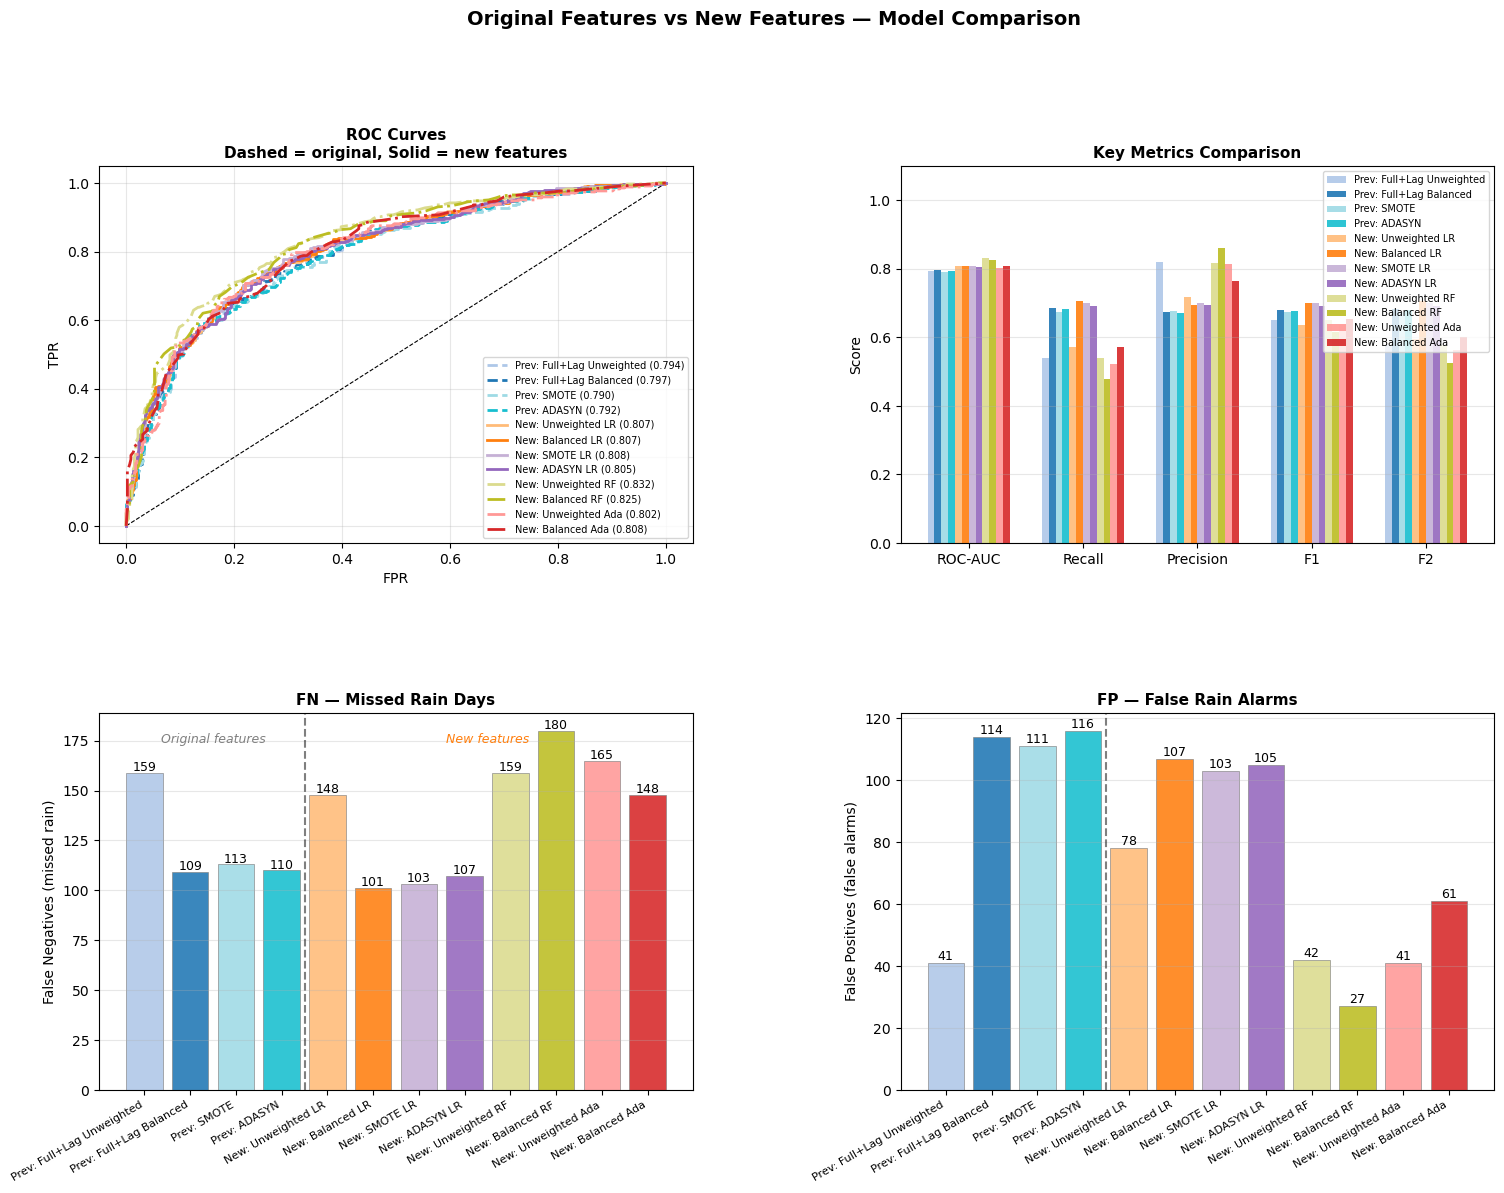


ORIGINAL vs NEW FEATURES — FULL COMPARISON
                    Model  ROC-AUC  Recall  Precision     F1     F2  FN  FP
Prev: Full+Lag Unweighted   0.7945  0.5391     0.8194 0.6503 0.5787 159  41
  Prev: Full+Lag Balanced   0.7967  0.6841     0.6743 0.6791 0.6821 109 114
              Prev: SMOTE   0.7900  0.6725     0.6764 0.6744 0.6732 113 111
             Prev: ADASYN   0.7920  0.6812     0.6695 0.6753 0.6788 110 116
       New: Unweighted LR   0.8067  0.5710     0.7164 0.6355 0.5952 148  78
         New: Balanced LR   0.8072  0.7072     0.6952 0.7011 0.7048 101 107
            New: SMOTE LR   0.8083  0.7014     0.7014 0.7014 0.7014 103 103
           New: ADASYN LR   0.8054  0.6899     0.6939 0.6919 0.6907 107 105
       New: Unweighted RF   0.8315  0.5391     0.8158 0.6492 0.5784 159  42
         New: Balanced RF   0.8255  0.4783     0.8594 0.6145 0.5248 180  27
      New: Unweighted Ada   0.8025  0.5217     0.8145 0.6360 0.5621 165  41
        New: Balanced Ada   0.8081  0.5710  

In [96]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from sklearn.metrics import (
    roc_curve, roc_auc_score, confusion_matrix,
    recall_score, precision_score, f1_score, fbeta_score
)

compare_models = [
    # ── Previous best models (original features) ──
    ("Prev: Full+Lag Unweighted",  y_test,    y_proba,       y_pred),
    ("Prev: Full+Lag Balanced",    y_test,    y_proba_bal,   y_pred_bal),
    ("Prev: SMOTE",                y_test,    y_proba_sm,    y_pred_sm),
    ("Prev: ADASYN",               y_test,    y_proba_ad,    y_pred_ad),
    # ── New feature models ──
    ("New: Unweighted LR",            y_test_nf, y_proba_nf,     y_pred_nf),
    ("New: Balanced LR",              y_test_nf, y_proba_nf_bal, y_pred_nf_bal),
    ("New: SMOTE LR",                 y_test_nf, y_proba_sm_nf,  y_pred_sm_nf),
    ("New: ADASYN LR",                y_test_nf, y_proba_ad_nf,  y_pred_ad_nf),
    ("New: Unweighted RF",            y_test_nf, y_proba_rfc_nf,  y_pred_rfc_nf),
    ("New: Balanced RF",              y_test_nf, y_proba_rfc_bal,  y_pred_rfc_bal),
    ("New: Unweighted Ada",           y_test_nf, y_proba_ada_nf,  y_pred_ada_nf),
    ("New: Balanced Ada",             y_test_nf, y_proba_ada_bal_nf,  y_pred_ada_bal_nf),
]
colors = ["#aec7e8","#1f77b4","#9edae5","#17becf", # Original models (Blues/Cyans)
          "#ffbb78","#ff7f0e","#c5b0d5","#9467bd", # LR New features (Oranges/Purples)
          "#dbdb8d","#bcbd22","#ff9896","#d62728"  # RF/Ada New features (Yellows/Reds)
]
styles = ["--"]*4 + ["-"]*4 + ["-."]*4

rows = []
for label, y_true, y_prob, y_p in compare_models:
    tn, fp, fn, tp = confusion_matrix(y_true, y_p).ravel()
    rows.append({
        "Model":     label,
        "ROC-AUC":   roc_auc_score(y_true, y_prob),
        "Recall":    recall_score(y_true, y_p, zero_division=0),
        "Precision": precision_score(y_true, y_p, zero_division=0),
        "F1":        f1_score(y_true, y_p, zero_division=0),
        "F2":        fbeta_score(y_true, y_p, beta=2, zero_division=0),
        "FN": fn, "FP": fp, "TP": tp, "TN": tn,
    })
res_df = pd.DataFrame(rows)

# ── Layout ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.35)

# Panel 1: ROC curves
ax_roc = fig.add_subplot(gs[0, 0])
ax_roc.plot([0,1],[0,1],"k--",lw=0.8)
for (label, y_true, y_prob, _), c, ls in zip(compare_models, colors, styles):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    ax_roc.plot(fpr, tpr, color=c, lw=2, ls=ls, label=f"{label} ({auc:.3f})")
ax_roc.set_xlabel("FPR"); ax_roc.set_ylabel("TPR")
ax_roc.set_title("ROC Curves\nDashed = original, Solid = new features",
                  fontweight="bold", fontsize=11)
ax_roc.legend(fontsize=7, loc="lower right"); ax_roc.grid(alpha=0.3)

# Panel 2: Key metrics grouped bar
ax_bar = fig.add_subplot(gs[0, 1])
metric_cols = ["ROC-AUC", "Recall", "Precision", "F1", "F2"]
x = np.arange(len(metric_cols))
n = len(res_df)
bar_w = 0.06
offsets = np.linspace(-(n-1)/2, (n-1)/2, n) * bar_w
for i, (row, c) in enumerate(zip(rows, colors)):
    vals = [row[m] for m in metric_cols]
    ax_bar.bar(x + offsets[i], vals, bar_w, label=row["Model"], color=c, alpha=0.9)
ax_bar.set_xticks(x); ax_bar.set_xticklabels(metric_cols, fontsize=10)
ax_bar.set_ylim(0, 1.1); ax_bar.set_ylabel("Score")
ax_bar.set_title("Key Metrics Comparison", fontweight="bold", fontsize=11)
ax_bar.legend(fontsize=7, loc="upper right"); ax_bar.grid(axis="y", alpha=0.3)

# Panel 3: FN comparison
ax_fn = fig.add_subplot(gs[1, 0])
ax_fn.bar(range(n), res_df["FN"], color=colors, alpha=0.88, edgecolor="grey", lw=0.5)
for i, v in enumerate(res_df["FN"]):
    ax_fn.text(i, v + 1, str(int(v)), ha="center", fontsize=9)
ax_fn.set_xticks(range(n))
ax_fn.set_xticklabels(res_df["Model"], rotation=30, ha="right", fontsize=8)
ax_fn.set_ylabel("False Negatives (missed rain)")
ax_fn.set_title("FN — Missed Rain Days", fontweight="bold", fontsize=11)
ax_fn.axvline(3.5, color="black", lw=1.5, ls="--", alpha=0.5)
ax_fn.text(1.5, ax_fn.get_ylim()[1]*0.92, "Original features",
           ha="center", fontsize=9, style="italic", color="grey")
ax_fn.text(7.5, ax_fn.get_ylim()[1]*0.92, "New features",
           ha="center", fontsize=9, style="italic", color="#ff7f0e")
ax_fn.grid(axis="y", alpha=0.3)

# Panel 4: FP comparison
ax_fp = fig.add_subplot(gs[1, 1])
ax_fp.bar(range(n), res_df["FP"], color=colors, alpha=0.88, edgecolor="grey", lw=0.5)
for i, v in enumerate(res_df["FP"]):
    ax_fp.text(i, v + 1, str(int(v)), ha="center", fontsize=9)
ax_fp.set_xticks(range(n))
ax_fp.set_xticklabels(res_df["Model"], rotation=30, ha="right", fontsize=8)
ax_fp.set_ylabel("False Positives (false alarms)")
ax_fp.set_title("FP — False Rain Alarms", fontweight="bold", fontsize=11)
ax_fp.axvline(3.5, color="black", lw=1.5, ls="--", alpha=0.5)
ax_fp.grid(axis="y", alpha=0.3)

plt.suptitle("Original Features vs New Features — Model Comparison",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig(f"{PLOTS_DIR}/dc1_30_new_features_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "="*85)
print("ORIGINAL vs NEW FEATURES — FULL COMPARISON")
print("="*85)
print(res_df[["Model","ROC-AUC","Recall","Precision","F1","F2","FN","FP"]]
      .to_string(index=False, float_format="{:.4f}".format))


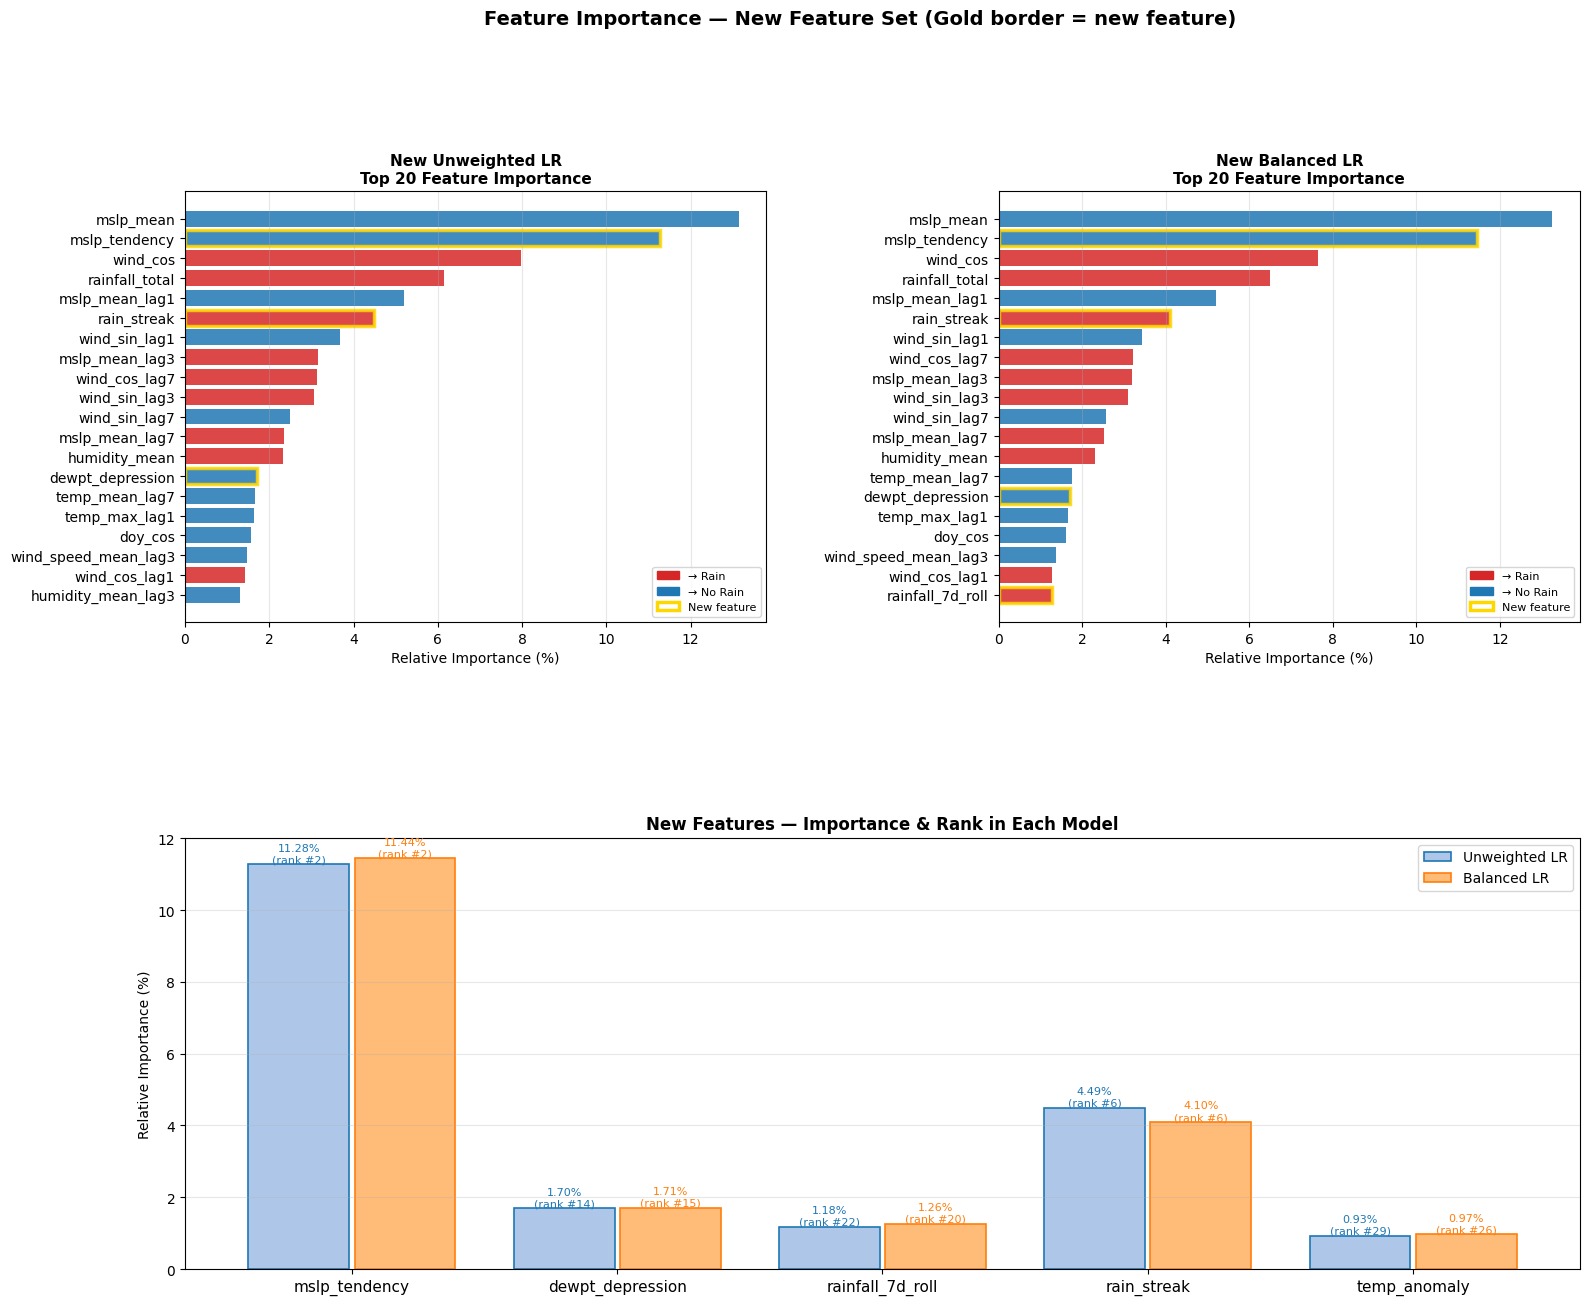

TOP 15 — New Unweighted LR
             Feature  Relative (%) Direction
0          mslp_mean        13.139   No Rain
1      mslp_tendency        11.284   No Rain
2           wind_cos         7.970      Rain
3     rainfall_total         6.149      Rain
4     mslp_mean_lag1         5.194   No Rain
5        rain_streak         4.494      Rain
6      wind_sin_lag1         3.691   No Rain
7     mslp_mean_lag3         3.151      Rain
8      wind_cos_lag7         3.132      Rain
9      wind_sin_lag3         3.068      Rain
10     wind_sin_lag7         2.495   No Rain
11    mslp_mean_lag7         2.348      Rain
12     humidity_mean         2.318      Rain
13  dewpt_depression         1.701   No Rain
14    temp_mean_lag7         1.668   No Rain

TOP 15 — New Balanced LR
             Feature  Relative (%) Direction
0          mslp_mean        13.254   No Rain
1      mslp_tendency        11.439   No Rain
2           wind_cos         7.639      Rain
3     rainfall_total         6.492      Rain
4 

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def feature_importance_df(lr_model, pca_model, feature_names):
    loadings   = pca_model.components_.T          # (n_features, n_components)
    importance = loadings @ lr_model.coef_[0]     # (n_features,)
    abs_imp    = np.abs(importance)
    rel_pct    = 100 * abs_imp / abs_imp.sum()
    return pd.DataFrame({
        "Feature":      feature_names,
        "Importance":   importance,
        "Abs":          abs_imp,
        "Relative (%)": rel_pct,
        "Direction":    ["Rain" if v > 0 else "No Rain" for v in importance],
    }).sort_values("Abs", ascending=False).reset_index(drop=True)

feature_names = X_train_nf.columns.tolist()
new_feats     = ["mslp_tendency", "dewpt_depression",
                  "rainfall_7d_roll", "rain_streak", "temp_anomaly"]

imp_unwt = feature_importance_df(lr_nf,     pca_nf_final, feature_names)
imp_bal  = feature_importance_df(lr_nf_bal, pca_nf_final, feature_names)

# ── Layout: 3 panels ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 2, hspace=0.5, wspace=0.4)

# Panel 1 — Unweighted top 20
ax1 = fig.add_subplot(gs[0, 0])
top_unwt = imp_unwt.head(20)
colors_unwt = ["#d62728" if d == "Rain" else "#1f77b4"
               for d in top_unwt["Direction"]]
bars = ax1.barh(top_unwt["Feature"][::-1], top_unwt["Relative (%)"][::-1],
                color=colors_unwt[::-1], alpha=0.85)
# Highlight new features
for bar, feat in zip(bars, top_unwt["Feature"][::-1]):
    if feat in new_feats:
        bar.set_edgecolor("gold"); bar.set_linewidth(2.5)
ax1.set_xlabel("Relative Importance (%)")
ax1.set_title("New Unweighted LR\nTop 20 Feature Importance",
              fontweight="bold", fontsize=11)
ax1.grid(axis="x", alpha=0.3)
from matplotlib.patches import Patch
ax1.legend(handles=[
    Patch(color="#d62728", label="→ Rain"),
    Patch(color="#1f77b4", label="→ No Rain"),
    Patch(facecolor="white", edgecolor="gold", lw=2.5, label="New feature"),
], fontsize=8, loc="lower right")

# Panel 2 — Balanced top 20
ax2 = fig.add_subplot(gs[0, 1])
top_bal = imp_bal.head(20)
colors_bal = ["#d62728" if d == "Rain" else "#1f77b4"
              for d in top_bal["Direction"]]
bars2 = ax2.barh(top_bal["Feature"][::-1], top_bal["Relative (%)"][::-1],
                 color=colors_bal[::-1], alpha=0.85)
for bar, feat in zip(bars2, top_bal["Feature"][::-1]):
    if feat in new_feats:
        bar.set_edgecolor("gold"); bar.set_linewidth(2.5)
ax2.set_xlabel("Relative Importance (%)")
ax2.set_title("New Balanced LR\nTop 20 Feature Importance",
              fontweight="bold", fontsize=11)
ax2.grid(axis="x", alpha=0.3)
ax2.legend(handles=[
    Patch(color="#d62728", label="→ Rain"),
    Patch(color="#1f77b4", label="→ No Rain"),
    Patch(facecolor="white", edgecolor="gold", lw=2.5, label="New feature"),
], fontsize=8, loc="lower right")

# Panel 3 — New features rank & importance in both models
ax3 = fig.add_subplot(gs[1, :])
nf_unwt = imp_unwt[imp_unwt["Feature"].isin(new_feats)].set_index("Feature")
nf_bal  = imp_bal[imp_bal["Feature"].isin(new_feats)].set_index("Feature")
nf_df   = pd.DataFrame({
    "Unweighted (%)": nf_unwt["Relative (%)"],
    "Balanced (%)":   nf_bal["Relative (%)"],
}).loc[new_feats]
x3 = np.arange(len(new_feats))
ax3.bar(x3 - 0.2, nf_df["Unweighted (%)"], 0.38,
        label="Unweighted LR", color="#aec7e8", edgecolor="#1f77b4", lw=1.2)
ax3.bar(x3 + 0.2, nf_df["Balanced (%)"],   0.38,
        label="Balanced LR",   color="#ffbb78", edgecolor="#ff7f0e", lw=1.2)
for i, feat in enumerate(new_feats):
    u = nf_df.loc[feat, "Unweighted (%)"]
    b = nf_df.loc[feat, "Balanced (%)"]
    rank_u = imp_unwt[imp_unwt["Feature"] == feat].index[0] + 1
    rank_b = imp_bal[imp_bal["Feature"]   == feat].index[0] + 1
    ax3.text(i - 0.2, u + 0.05, f"{u:.2f}%\n(rank #{rank_u})",
             ha="center", fontsize=8, color="#1f77b4")
    ax3.text(i + 0.2, b + 0.05, f"{b:.2f}%\n(rank #{rank_b})",
             ha="center", fontsize=8, color="#ff7f0e")
ax3.set_xticks(x3)
ax3.set_xticklabels(new_feats, fontsize=11)
ax3.set_ylabel("Relative Importance (%)")
ax3.set_title("New Features — Importance & Rank in Each Model",
              fontweight="bold", fontsize=12)
ax3.legend(fontsize=10)
ax3.grid(axis="y", alpha=0.3)

plt.suptitle("Feature Importance — New Feature Set (Gold border = new feature)",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig(f"{PLOTS_DIR}/dc1_31_new_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

# ── Printed tables ────────────────────────────────────────────────────────────
print("TOP 15 — New Unweighted LR")
print(imp_unwt[["Feature","Relative (%)","Direction"]].head(15).to_string(index=True, float_format="{:.3f}".format))
print()
print("TOP 15 — New Balanced LR")
print(imp_bal[["Feature","Relative (%)","Direction"]].head(15).to_string(index=True, float_format="{:.3f}".format))
print()
print("NEW FEATURES SUMMARY")
print(nf_df.round(3).to_string())


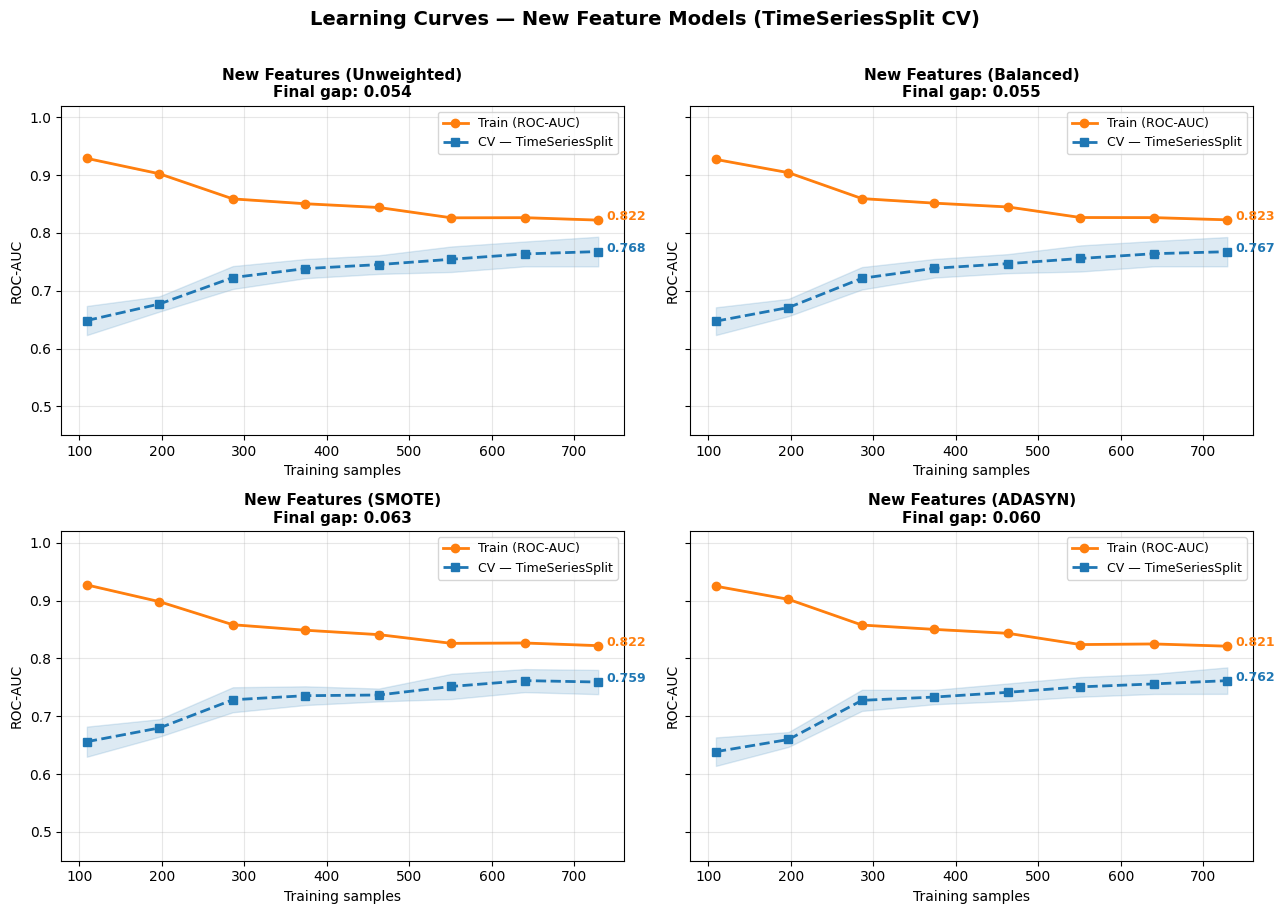

Train/CV gap summary (smaller = less overfitting):
  New Features (Unweighted)            train=0.8221  cv=0.7677  gap=0.0544
  New Features (Balanced)              train=0.8226  cv=0.7675  gap=0.0551
  New Features (SMOTE)                 train=0.8221  cv=0.7591  gap=0.0629
  New Features (ADASYN)                train=0.8211  cv=0.7616  gap=0.0596


In [92]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import learning_curve, TimeSeriesSplit
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN

tscv       = TimeSeriesSplit(n_splits=5)
train_sizes = np.linspace(0.15, 1.0, 8)

pipe_configs = [
    ("New Features\n(Unweighted)",
     Pipeline([("sc",  StandardScaler()),
               ("pca", PCA(n_components=0.95)),
               ("lr",  LogisticRegression(max_iter=1000, random_state=42))]),
     X_train_nf, y_train_nf),
    ("New Features\n(Balanced)",
     Pipeline([("sc",  StandardScaler()),
               ("pca", PCA(n_components=0.95)),
               ("lr",  LogisticRegression(max_iter=1000, random_state=42,
                                          class_weight="balanced"))]),
     X_train_nf, y_train_nf),
    ("New Features\n(SMOTE)",
     ImbPipeline([("sc",  StandardScaler()),
                  ("sm",  SMOTE(random_state=42)),
                  ("pca", PCA(n_components=0.95)),
                  ("lr",  LogisticRegression(max_iter=1000, random_state=42))]),
     X_train_nf, y_train_nf),
    ("New Features\n(ADASYN)",
     ImbPipeline([("sc",  StandardScaler()),
                  ("ad",  ADASYN(random_state=42)),
                  ("pca", PCA(n_components=0.95)),
                  ("lr",  LogisticRegression(max_iter=1000, random_state=42))]),
     X_train_nf, y_train_nf),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=True)
c_train, c_cv = "#ff7f0e", "#1f77b4"

for ax, (label, pipe, X, y) in zip(axes.flat, pipe_configs):
    sizes, tr_scores, cv_scores = learning_curve(
        pipe, X, y,
        train_sizes=train_sizes,
        cv=tscv,
        scoring="roc_auc",
        n_jobs=-1,
    )
    tr_mean = tr_scores.mean(axis=1); tr_std = tr_scores.std(axis=1)
    cv_mean = cv_scores.mean(axis=1); cv_std = cv_scores.std(axis=1)

    ax.plot(sizes, tr_mean, "o-",  color=c_train, lw=2, label="Train (ROC-AUC)")
    ax.fill_between(sizes, tr_mean - tr_std, tr_mean + tr_std,
                    alpha=0.15, color=c_train)
    ax.plot(sizes, cv_mean, "s--", color=c_cv,    lw=2, label="CV — TimeSeriesSplit")
    ax.fill_between(sizes, cv_mean - cv_std, cv_mean + cv_std,
                    alpha=0.15, color=c_cv)

    # Annotate final values
    ax.annotate(f"{tr_mean[-1]:.3f}", (sizes[-1], tr_mean[-1]),
                textcoords="offset points", xytext=(6, 0),
                fontsize=9, color=c_train, fontweight="bold")
    ax.annotate(f"{cv_mean[-1]:.3f}", (sizes[-1], cv_mean[-1]),
                textcoords="offset points", xytext=(6, 0),
                fontsize=9, color=c_cv, fontweight="bold")

    gap = tr_mean[-1] - cv_mean[-1]
    ax.set_title(f"{label.replace(chr(10), " ")}\nFinal gap: {gap:.3f}",
                 fontweight="bold", fontsize=11)
    ax.set_xlabel("Training samples")
    ax.set_ylabel("ROC-AUC")
    ax.set_ylim(0.45, 1.02)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("Learning Curves — New Feature Models (TimeSeriesSplit CV)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/dc1_32_new_feat_learning_curves.png",
            dpi=300, bbox_inches="tight")
plt.show()

print("Train/CV gap summary (smaller = less overfitting):")
for label, pipe, X, y in pipe_configs:
    sizes, tr_s, cv_s = learning_curve(
        pipe, X, y, train_sizes=np.array([1.0]),
        cv=tscv, scoring="roc_auc", n_jobs=-1)
    print(f"  {label.replace(chr(10), " "):35s}  train={tr_s.mean():.4f}  cv={cv_s.mean():.4f}  gap={tr_s.mean()-cv_s.mean():.4f}")
